# Comparaison des agents RL
**Win rate** et **Time/move** par environnement — tous les agents superposés.

In [37]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from deeprl_5iabd.config import settings

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 8,
    'lines.linewidth': 2,
})

In [38]:
# ─────────────────────────────────────────────
# CONFIG — adapte si besoin
# ─────────────────────────────────────────────

SEED        = 42
CHECKPOINTS = [1_000, 10_000, 100_000]
WINDOW      = 100   # fenêtre glissante sur les épisodes d'éval

ENVS = ["LineWorldEnv", "GridWorldEnv", "TicTacToeEnv", "QuartoEnv"]

# (algo_folder, agent_name_in_json, label_affichage, couleur)
AGENTS = [
    ("reinforce",    "reinforce_no_baseline",     "REINFORCE (no baseline)",     "#1f77b4"),
    ("reinforce",    "reinforce_mean_baseline",   "REINFORCE (mean baseline)",   "#ff7f0e"),
    ("reinforce",    "reinforce_critic_baseline", "REINFORCE (critic baseline)", "#2ca02c"),
    # ("ppo",          "ppo",                       "PPO",                         "#ff7f0e"),
    # ("q_learning",   "q_learning",                "Q-Learning",                  "#2ca02c"),
    # ("dqn",          "dqn_no_replay",             "DQN",                         "#d62728"),
    # ("ddqn",         "ddqn",                      "DDQN",                        "#9467bd"),
    # ("ddqn_replay",  "ddqn_replay",               "DDQN + Replay",               "#8c564b"),
    # ("ddqn_per",     "ddqn_per",                  "DDQN + PER",                  "#e377c2"),
]

In [39]:
# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

def build_path(algo_folder, agent_name, env_name, checkpoint):
    return os.path.join(
        settings.training_logs_dir,
        algo_folder, env_name,
        f"seed_{SEED}", "eval",
        f"{agent_name}_{checkpoint}.json",
    )


def load_json(path):
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)


def rolling(arr, metric, window):
    """Fenêtre glissante. metric='winrate' ou 'time'."""
    out = np.zeros(len(arr))
    for i in range(len(arr)):
        chunk = arr[max(0, i - window + 1):i + 1]
        if metric == 'winrate':
            out[i] = np.mean(chunk == 1) * 100
        else:
            out[i] = np.mean(chunk) * 1000   # ms
    return out


def load_series(env_name, checkpoint):
    """Charge rewards et time/move pour tous les agents."""
    series = []
    for algo_folder, agent_name, label, color in AGENTS:
        path = build_path(algo_folder, agent_name, env_name, checkpoint)
        data = load_json(path)
        if data is None:
            series.append((label, color, None, None))
            continue
        episodes = data.get("episodes", [])
        rewards  = np.array([ep["reward"]           for ep in episodes])
        times    = np.array([ep["time_per_move_ms"]  for ep in episodes])
        series.append((label, color, rewards, times))
    return series

In [40]:
# ─────────────────────────────────────────────
# PLOT FUNCTION
# ─────────────────────────────────────────────

def plot_env_checkpoint(env_name, checkpoint):
    series = load_series(env_name, checkpoint)

    fig, (ax_wr, ax_tm) = plt.subplots(
        1, 2, figsize=(14, 4),
        gridspec_kw={'wspace': 0.3}
    )
    fig.suptitle(
        f"{env_name}  —  checkpoint {checkpoint:,} épisodes",
        fontweight="bold", fontsize=13
    )

    any_wr = any_tm = False

    for label, color, rewards, times in series:
        if rewards is None:
            continue
        wr_curve = rolling(rewards, 'winrate', WINDOW)
        tm_curve = rolling(times,   'time',    WINDOW)

        ax_wr.plot(wr_curve, label=label, color=color)
        ax_tm.plot(tm_curve, label=label, color=color)
        any_wr = any_tm = True

    # ── Win rate ──
    ax_wr.axhline(50, color='gray', linestyle='--', linewidth=0.8)
    ax_wr.set_ylim(0, 105)
    ax_wr.set_xlabel(f"Épisode d'éval (fenêtre {WINDOW})")
    ax_wr.set_ylabel("Win rate (%)")
    ax_wr.set_title("Win rate")
    ax_wr.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))
    if any_wr:
        ax_wr.legend(loc='lower right')

    # ── Time/move ──
    ax_tm.set_xlabel(f"Épisode d'éval (fenêtre {WINDOW})")
    ax_tm.set_ylabel("Time / move (ms)")
    ax_tm.set_title("Temps par coup")
    if any_tm:
        ax_tm.legend(loc='upper right')

    missing = [label for label, _, r, _ in series if r is None]
    if missing:
        fig.text(0.01, 0.01,
                 f"Données manquantes : {', '.join(missing)}",
                 fontsize=7, color='gray')

    plt.show()

---
## LineWorldEnv

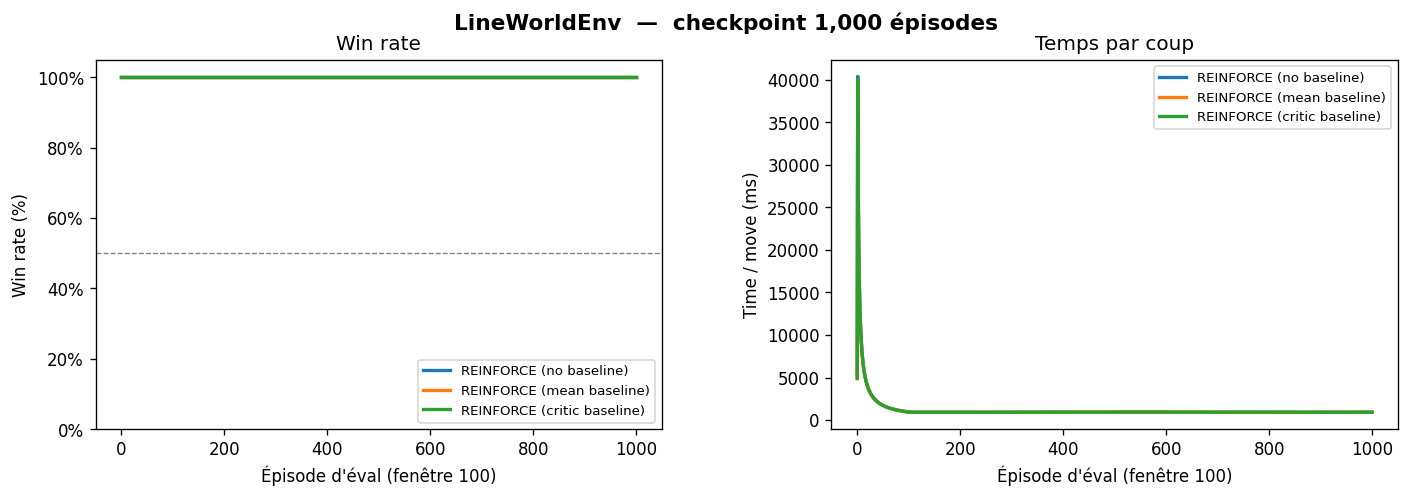

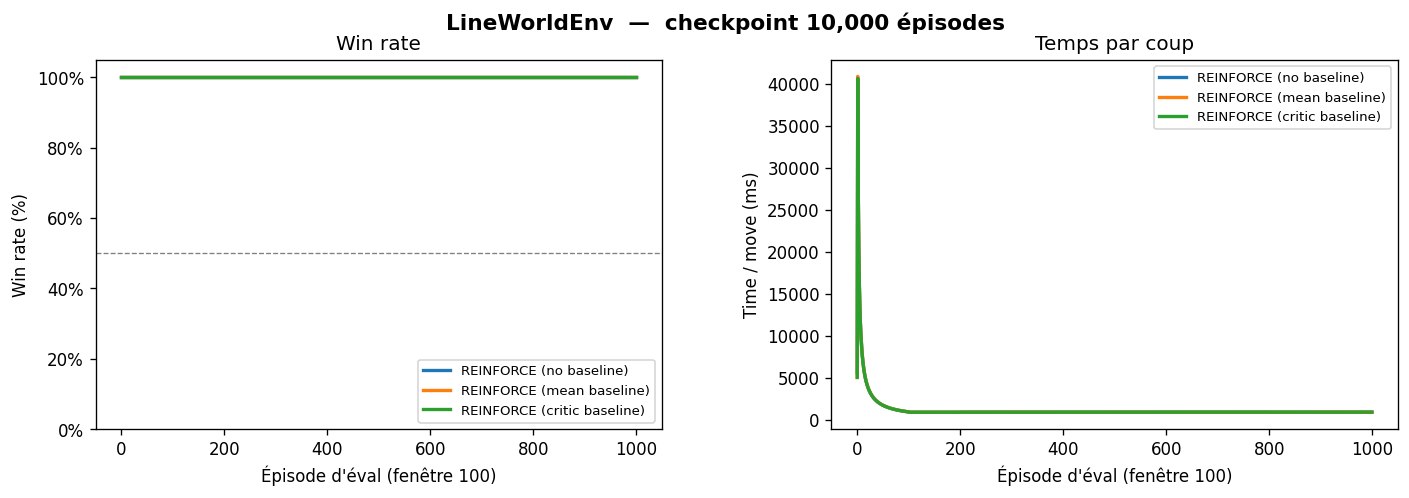

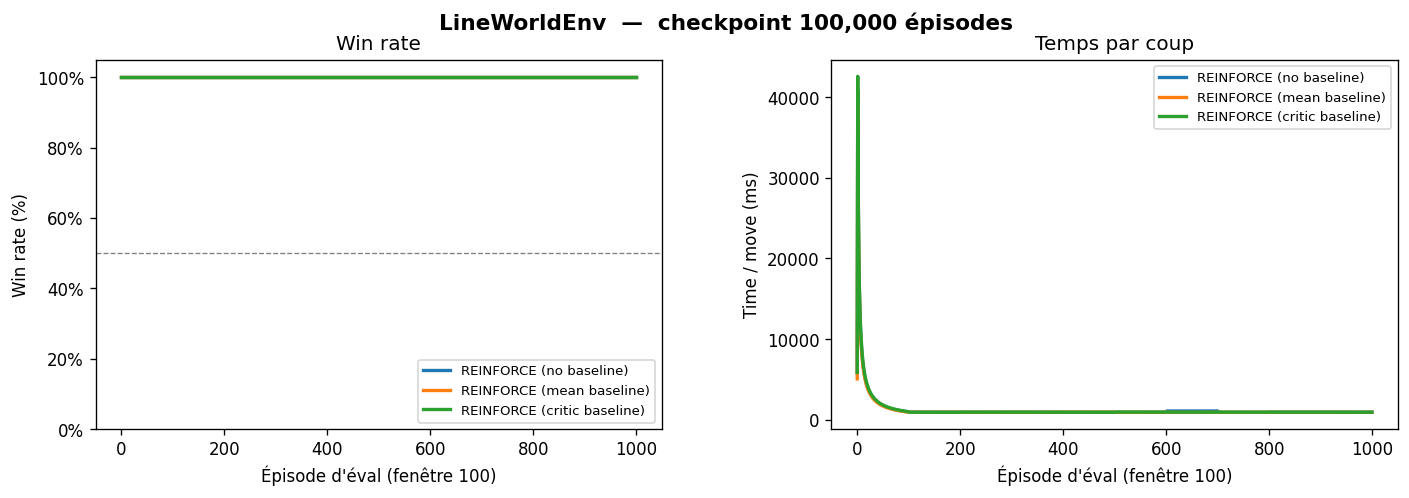

In [41]:
for ckpt in CHECKPOINTS:
    plot_env_checkpoint("LineWorldEnv", ckpt)

---
## GridWorldEnv

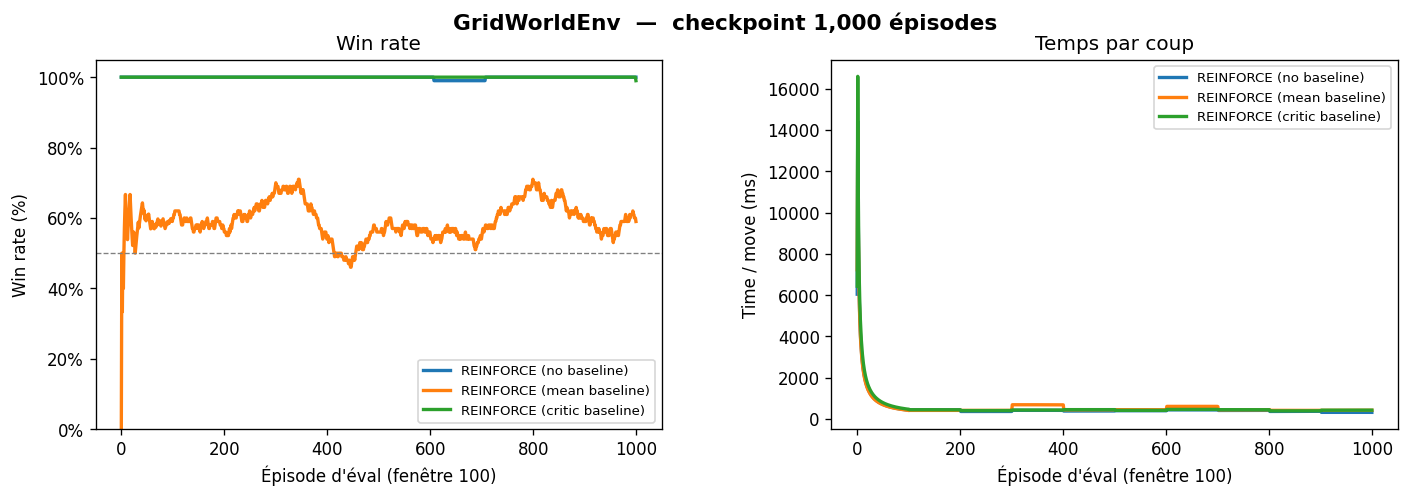

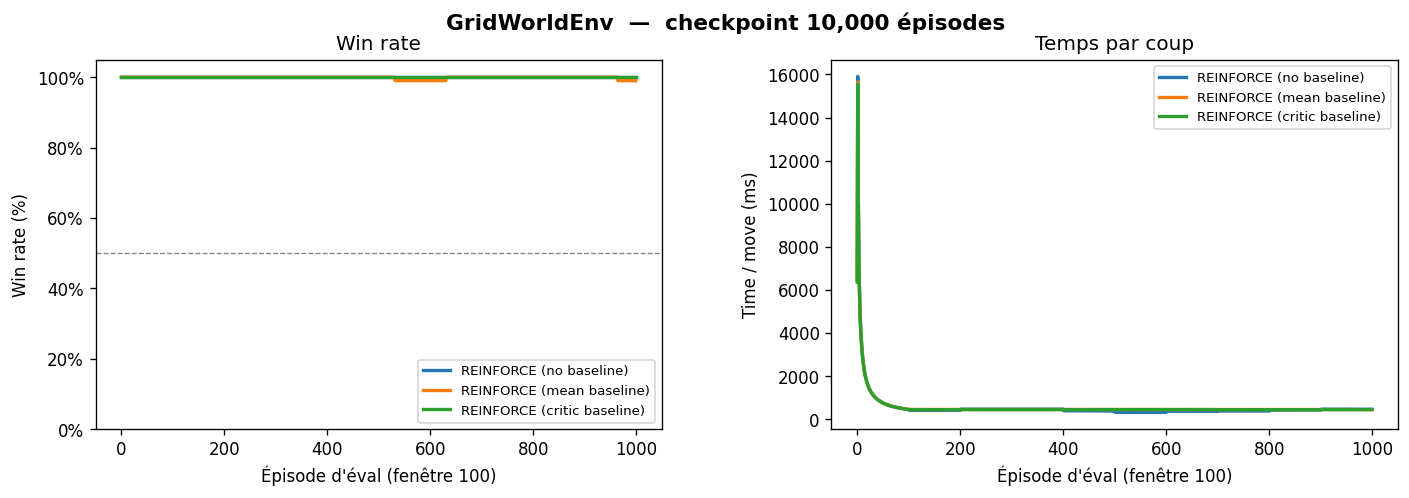

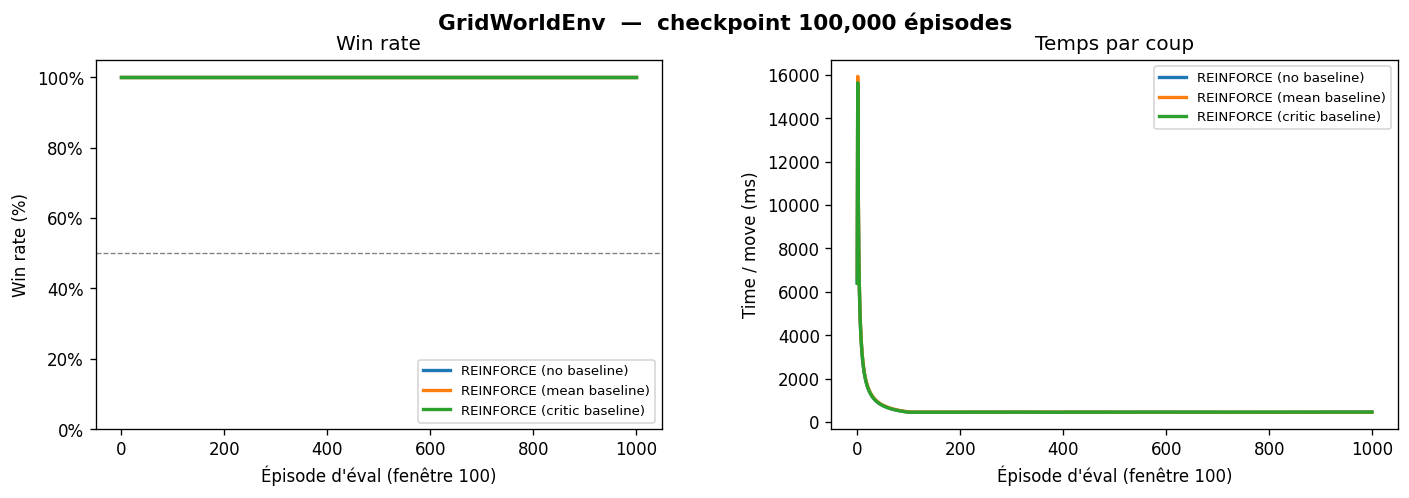

In [42]:
for ckpt in CHECKPOINTS:
    plot_env_checkpoint("GridWorldEnv", ckpt)

---
## TicTacToeEnv

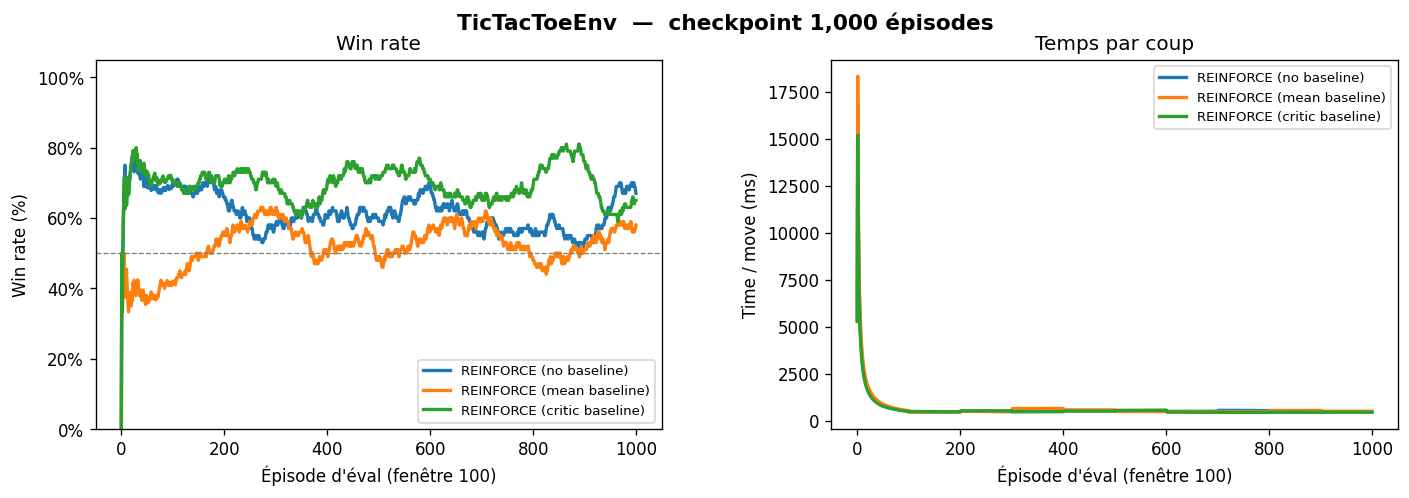

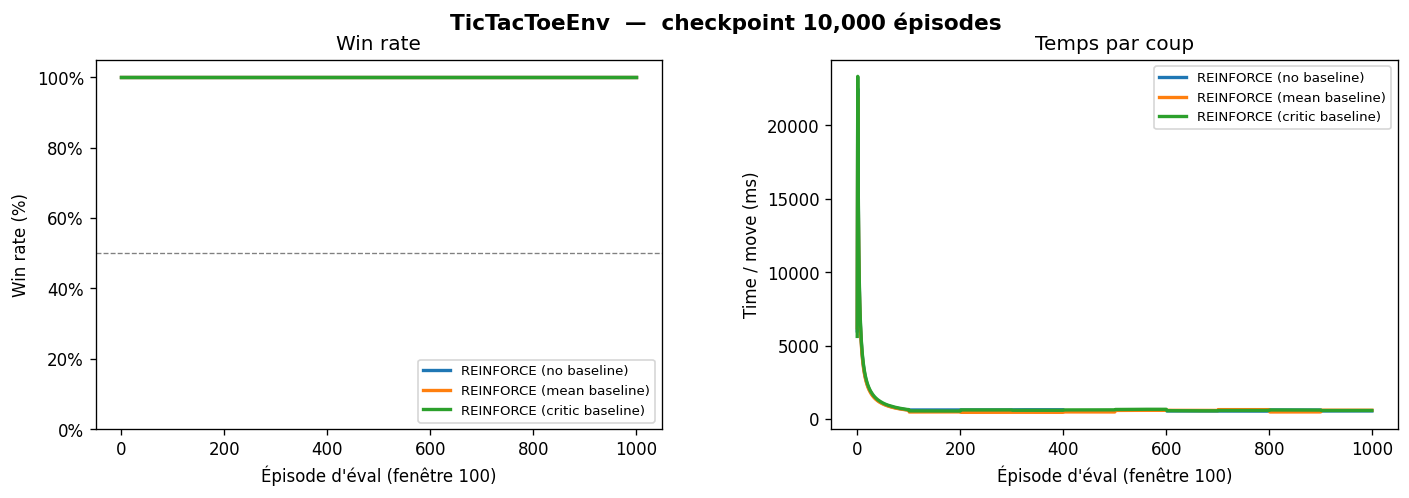

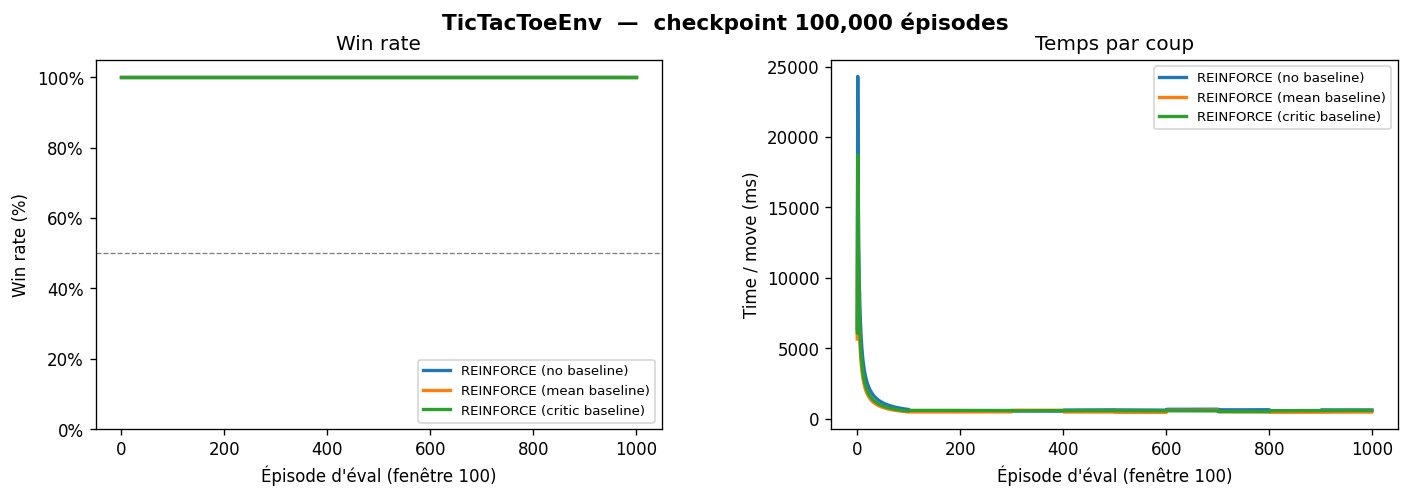

In [43]:
for ckpt in CHECKPOINTS:
    plot_env_checkpoint("TicTacToeEnv", ckpt)

---
## QuartoEnv

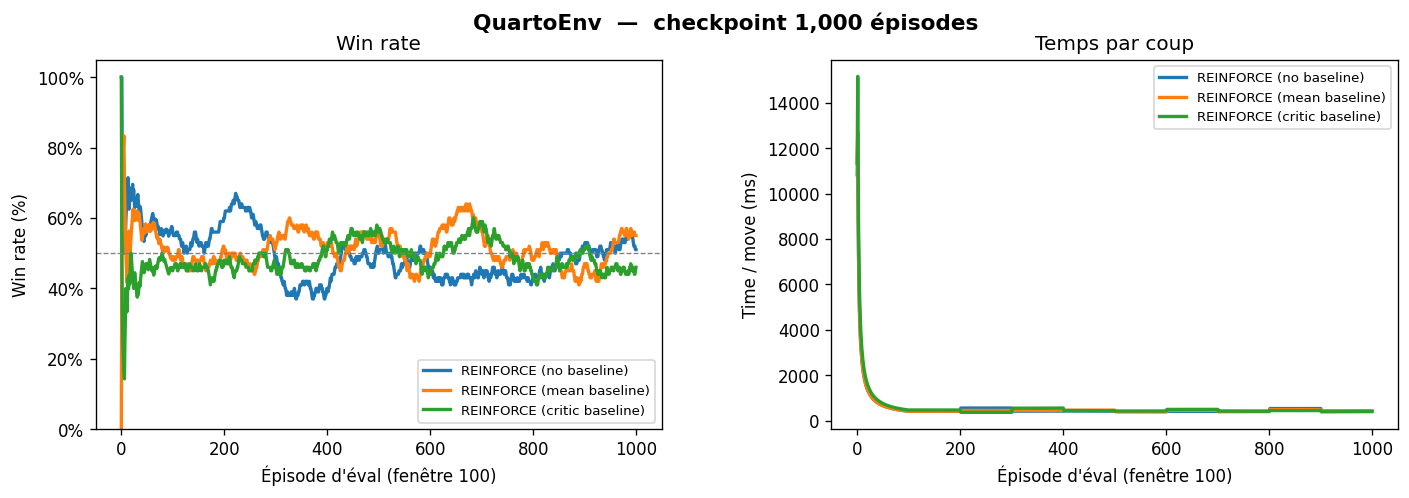

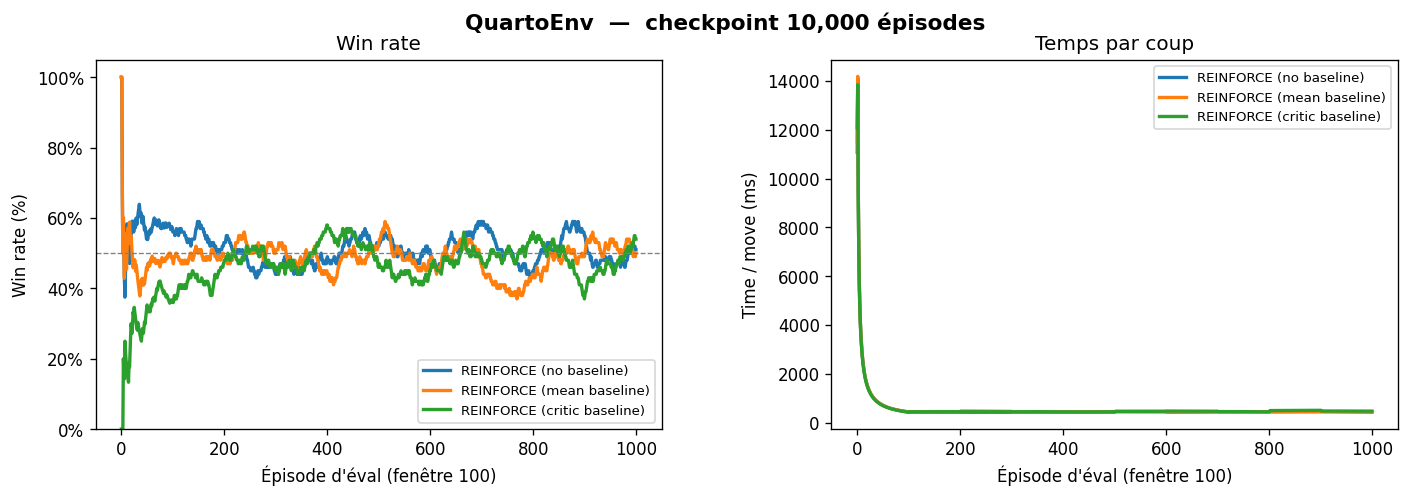

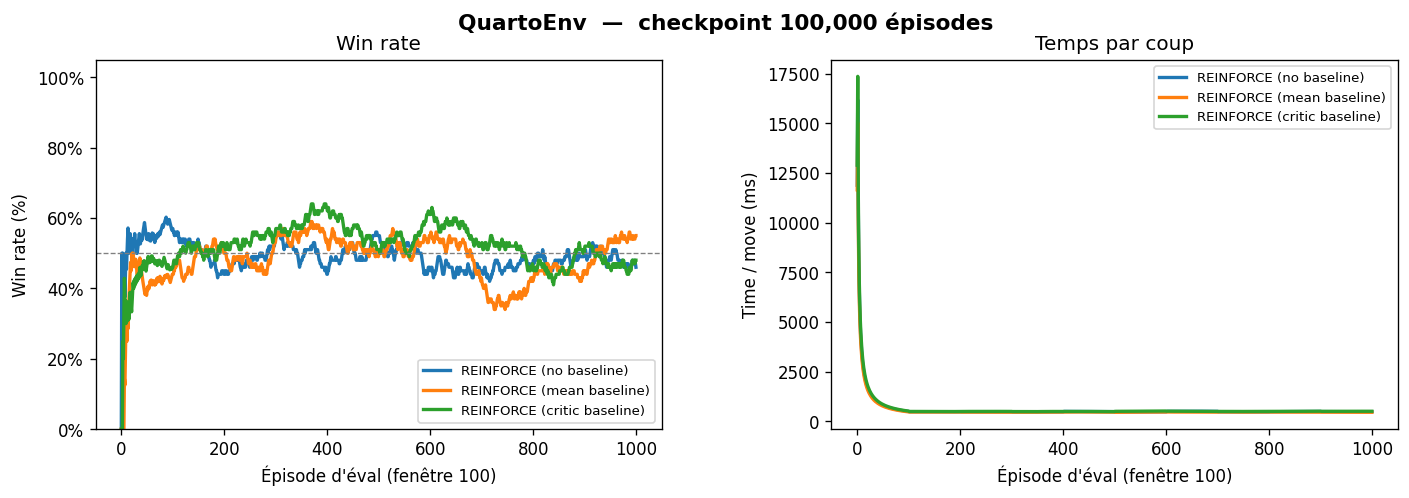

In [44]:
for ckpt in CHECKPOINTS:
    plot_env_checkpoint("QuartoEnv", ckpt)

---
## Tableau récap — Win rate final (checkpoint 100k)

In [45]:
import pandas as pd

rows = []
for algo_folder, agent_name, label, _ in AGENTS:
    row = {"Agent": label}
    for env_name in ENVS:
        path = build_path(algo_folder, agent_name, env_name, 100_000)
        data = load_json(path)
        wr = data["summary"]["win_rate"] * 100 if data else float('nan')
        row[env_name] = f"{wr:.1f}%" if not np.isnan(wr) else "—"
    rows.append(row)

df = pd.DataFrame(rows).set_index("Agent")
df.style.set_caption("Win rate @ 100k épisodes")

,LineWorldEnv,GridWorldEnv,TicTacToeEnv,QuartoEnv
Agent,,,,
REINFORCE (no baseline),100.0%,100.0%,100.0%,48.8%
REINFORCE (mean baseline),100.0%,100.0%,100.0%,49.0%
REINFORCE (critic baseline),100.0%,100.0%,100.0%,52.6%


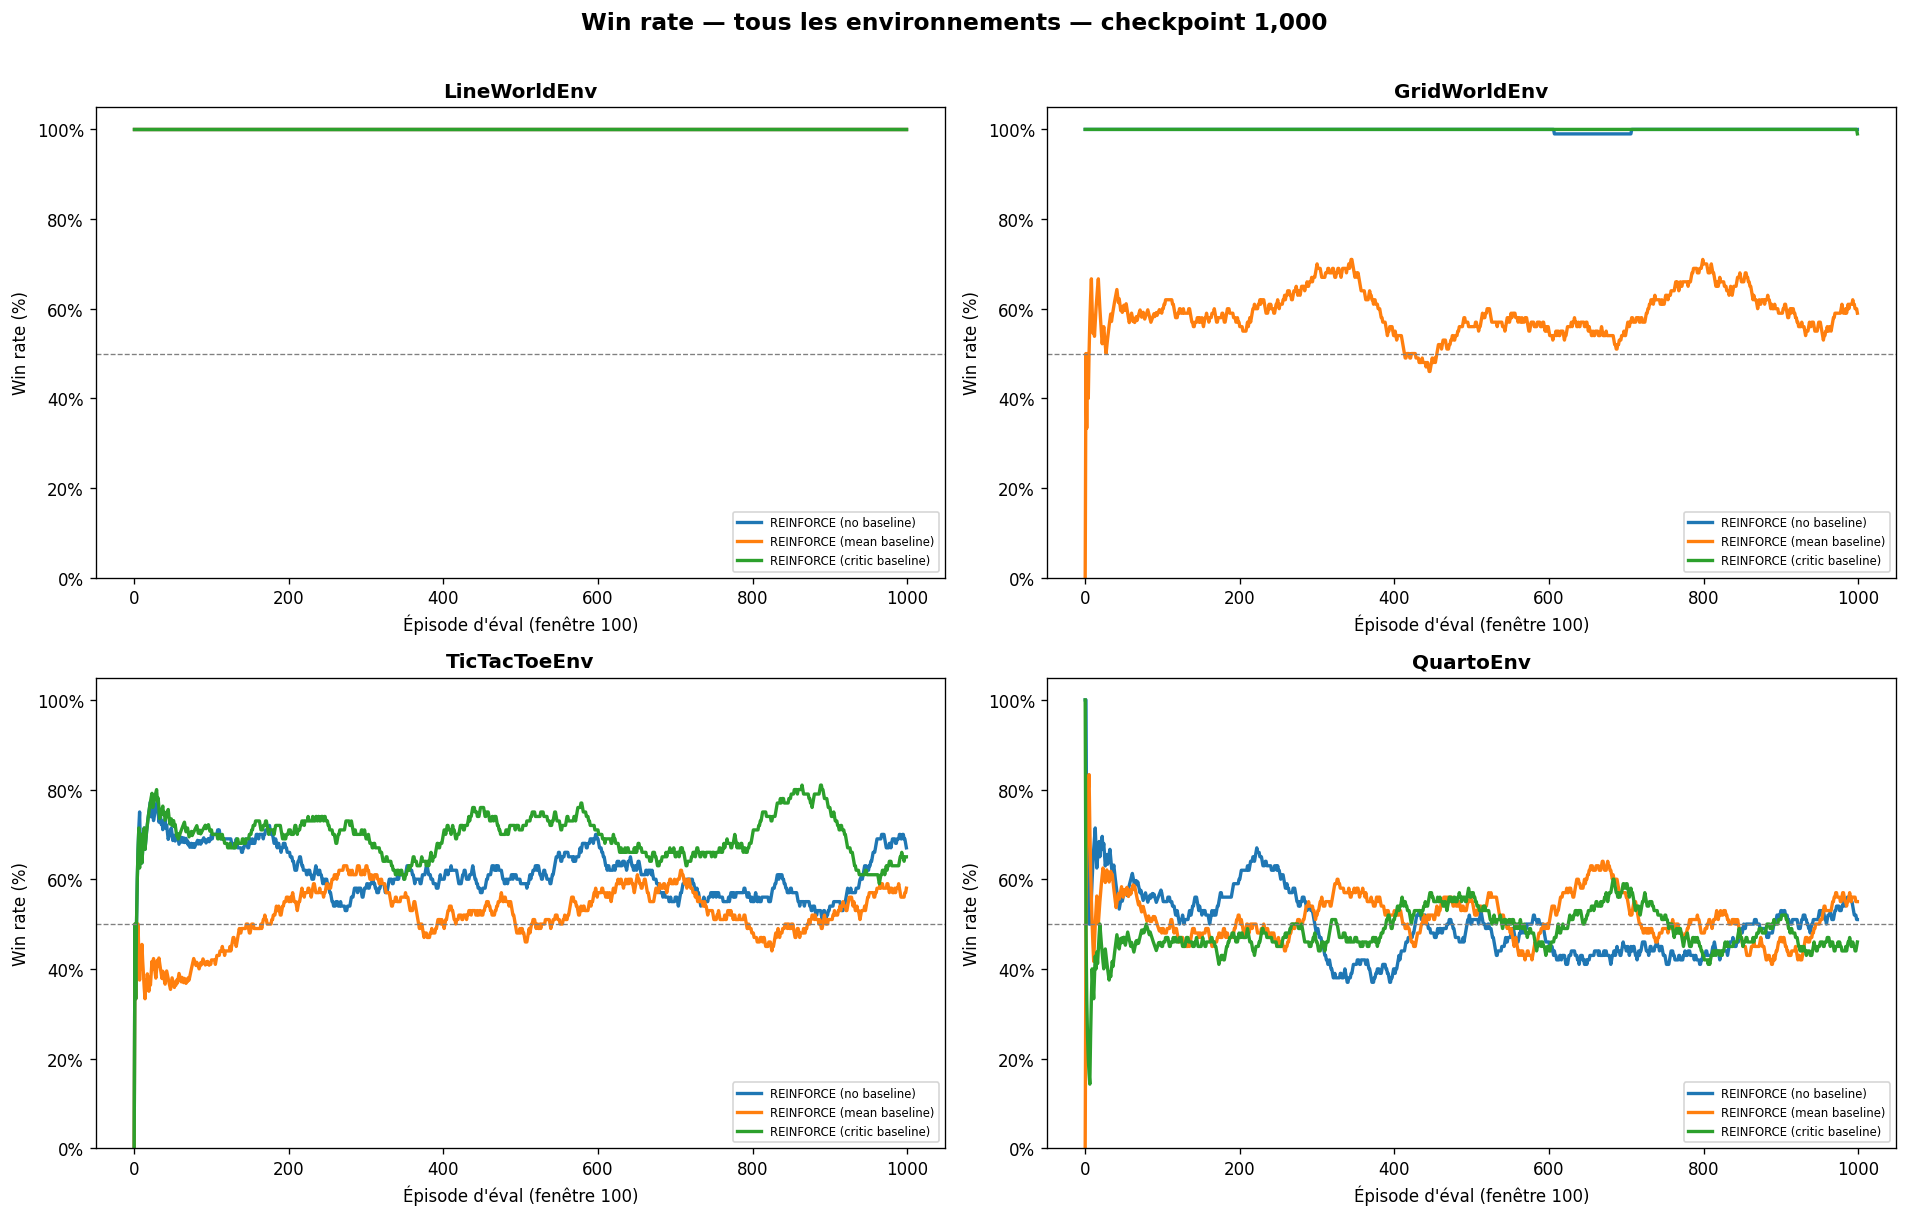

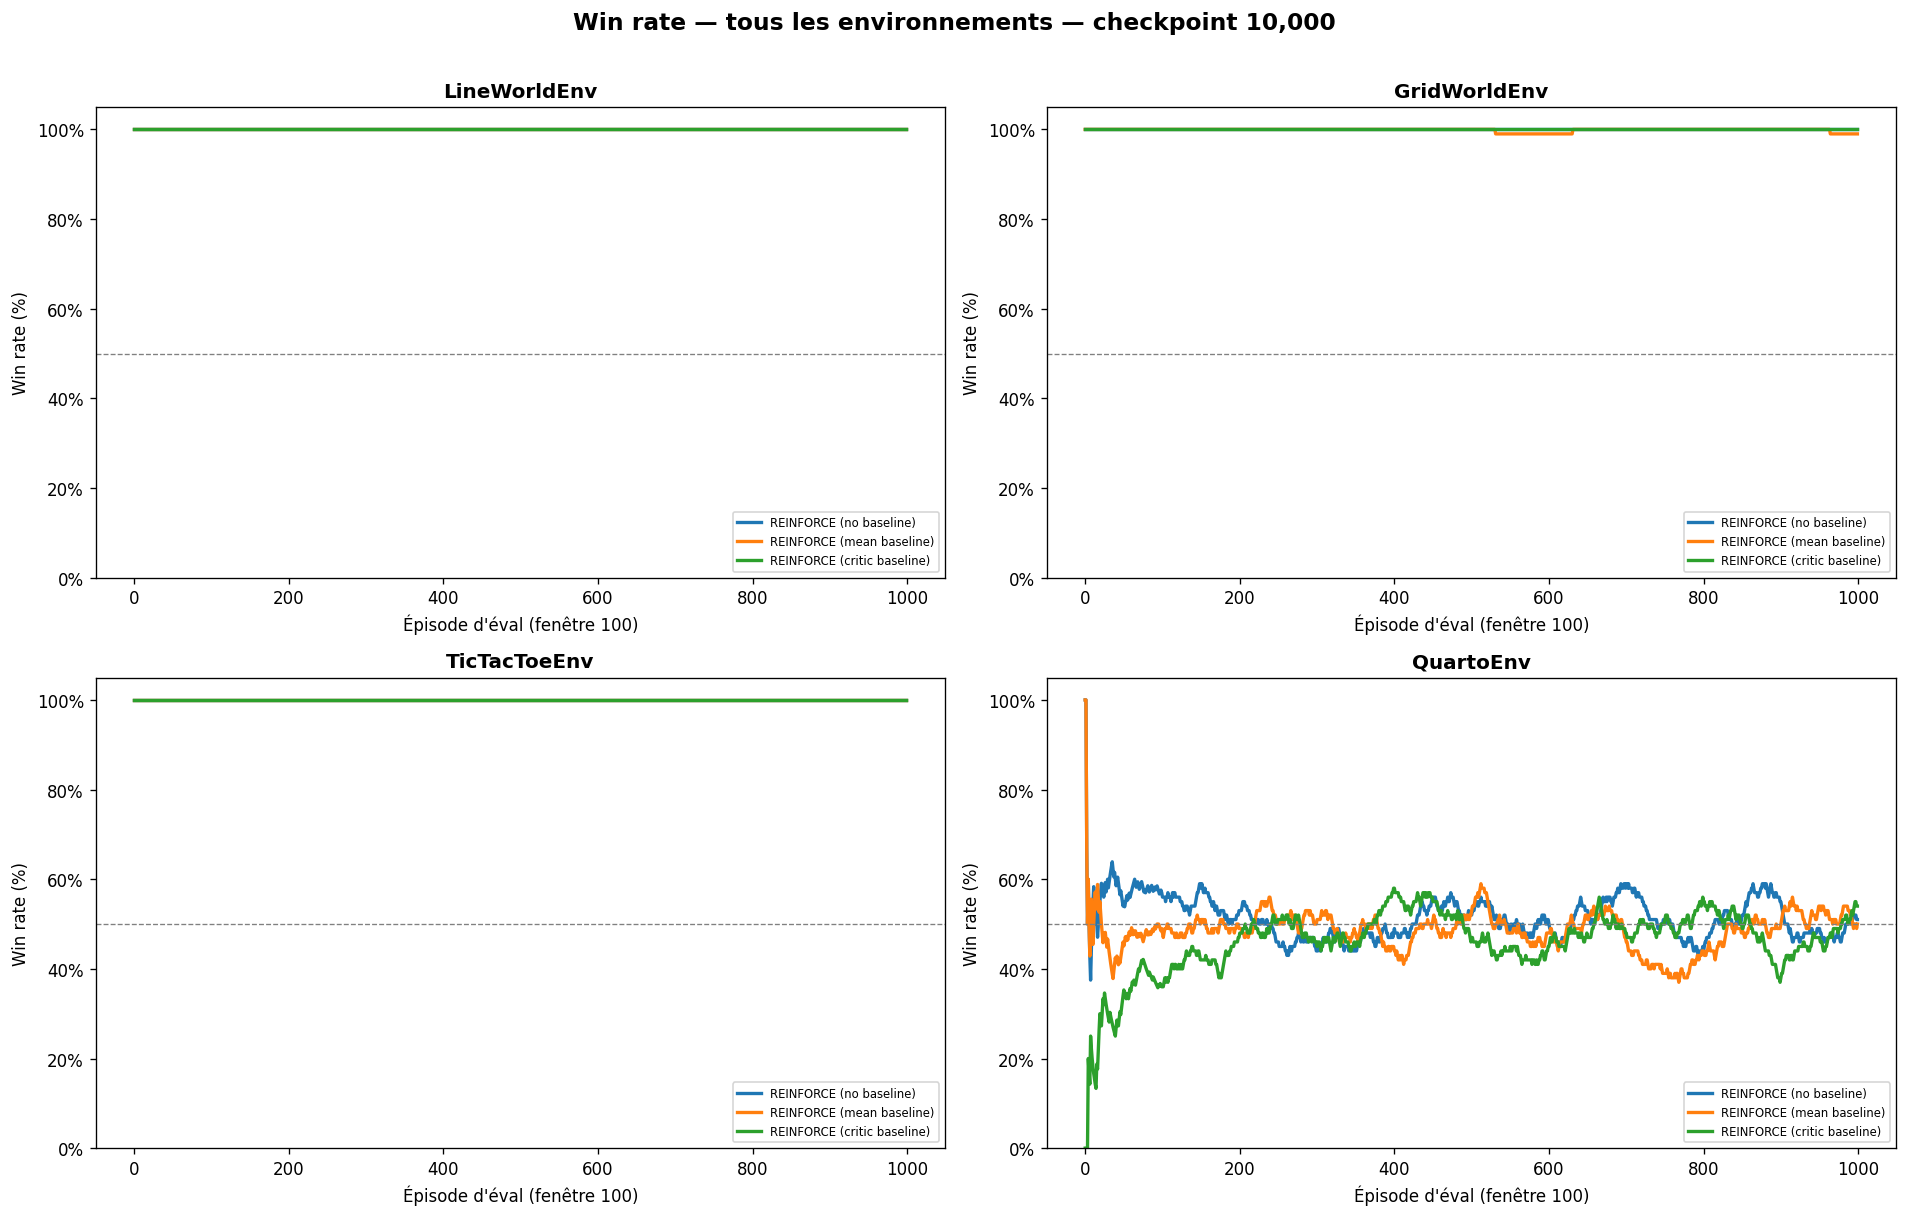

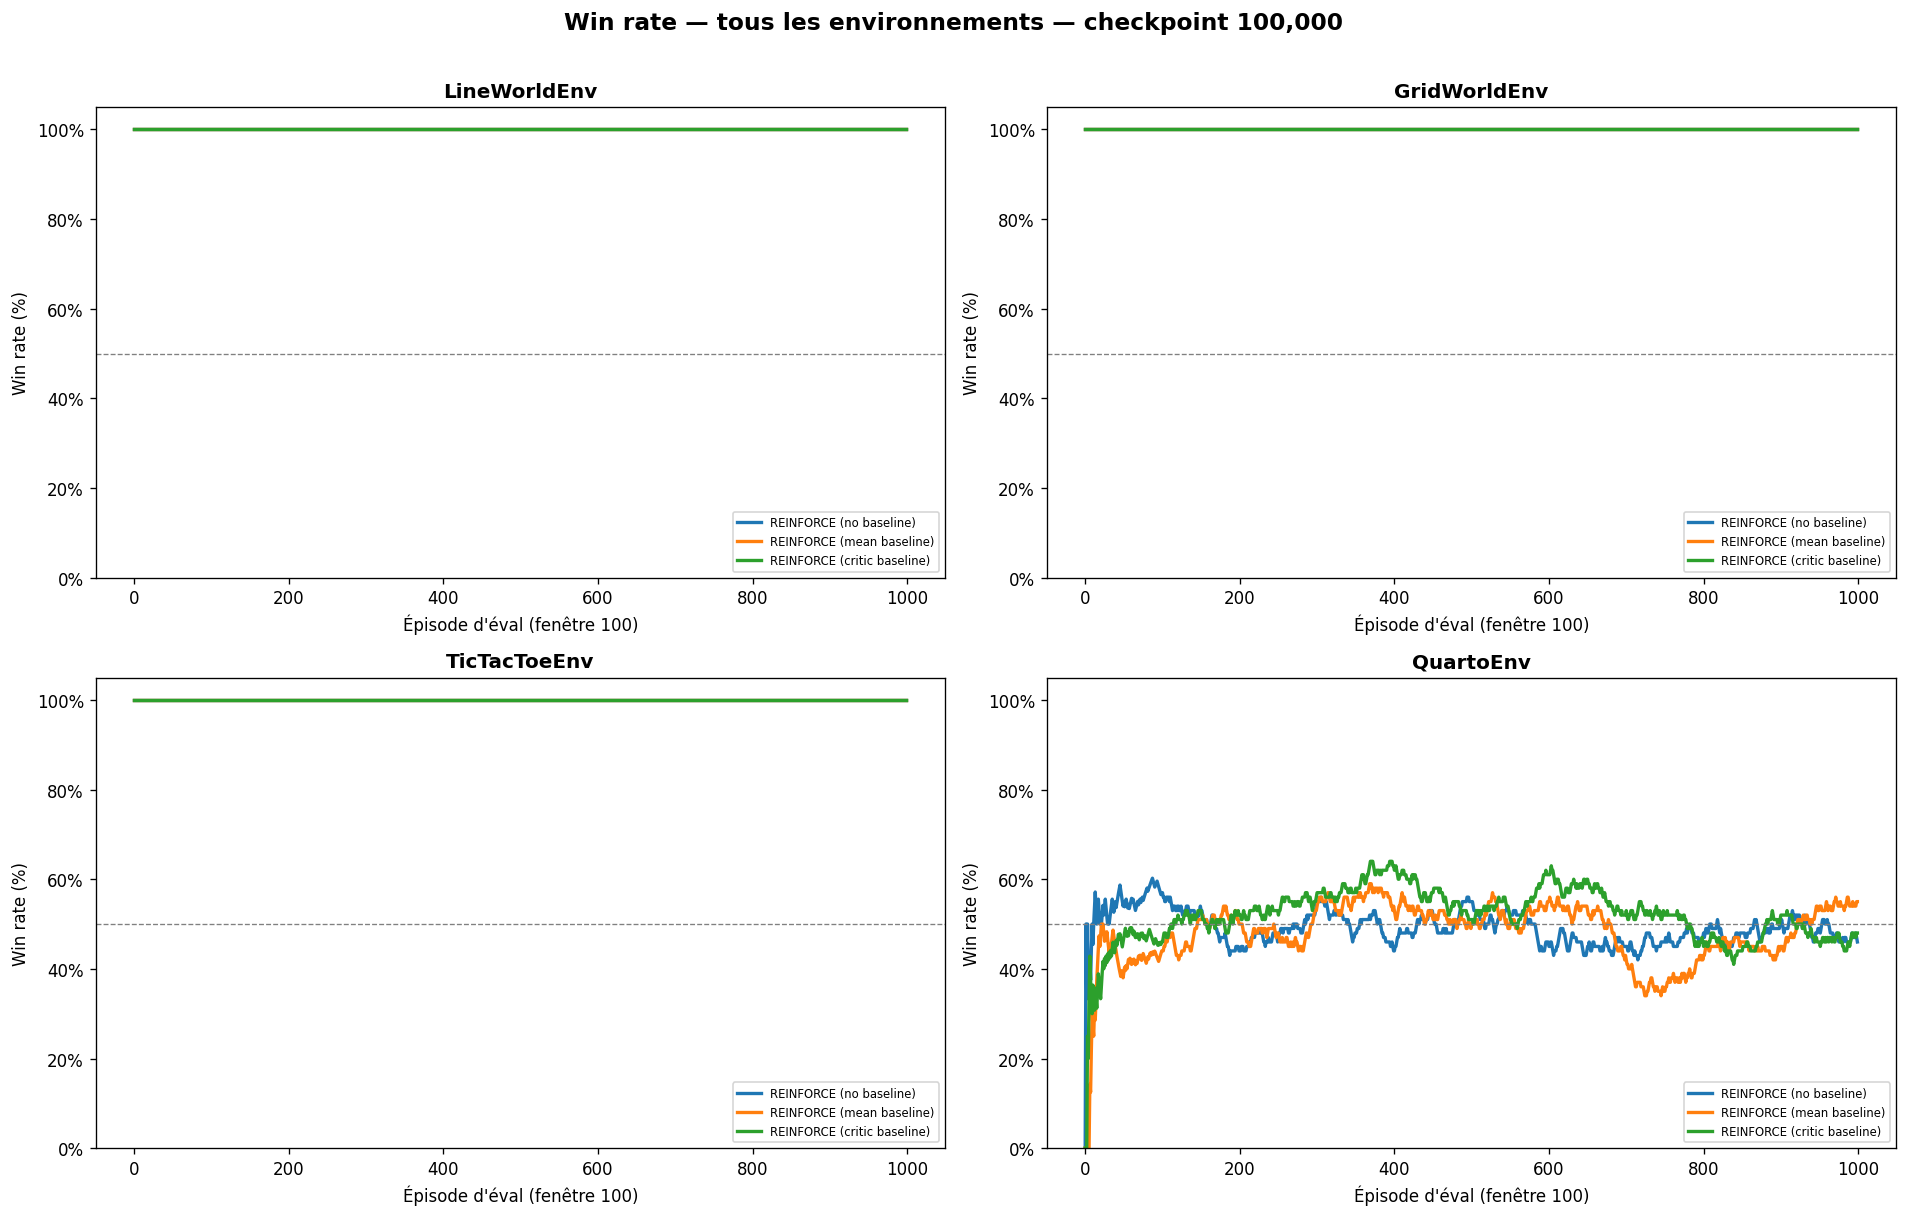

In [46]:
def plot_all_envs_grid(checkpoint):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(
        f"Win rate — tous les environnements — checkpoint {checkpoint:,}",
        fontweight="bold", fontsize=14, y=1.01
    )

    for ax, env_name in zip(axes.flatten(), ENVS):
        series = load_series(env_name, checkpoint)
        any_plotted = False

        for label, color, rewards, _ in series:
            if rewards is None:
                continue
            curve = rolling(rewards, 'winrate', WINDOW)
            ax.plot(curve, label=label, color=color)
            any_plotted = True

        ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
        ax.set_ylim(0, 105)
        ax.set_title(env_name, fontweight='bold')
        ax.set_xlabel(f"Épisode d'éval (fenêtre {WINDOW})")
        ax.set_ylabel("Win rate (%)")
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))
        if any_plotted:
            ax.legend(loc='lower right', fontsize=7)

    plt.tight_layout()
    plt.show()


for ckpt in CHECKPOINTS:
    plot_all_envs_grid(ckpt)

,LineWorld @1k,LineWorld @10k,LineWorld @100k,GridWorld @1k,GridWorld @10k,GridWorld @100k,TicTacToe @1k,TicTacToe @10k,TicTacToe @100k,Quarto @1k,Quarto @10k,Quarto @100k
Agent,,,,,,,,,,,,
REINFORCE (no baseline),100.0%,100.0%,100.0%,99.9%,100.0%,100.0%,61.3%,100.0%,100.0%,49.2%,51.4%,48.8%
REINFORCE (mean baseline),100.0%,100.0%,100.0%,59.4%,99.8%,100.0%,53.1%,100.0%,100.0%,51.6%,48.3%,49.0%
REINFORCE (critic baseline),100.0%,100.0%,100.0%,99.9%,100.0%,100.0%,69.8%,100.0%,100.0%,48.9%,47.3%,52.6%


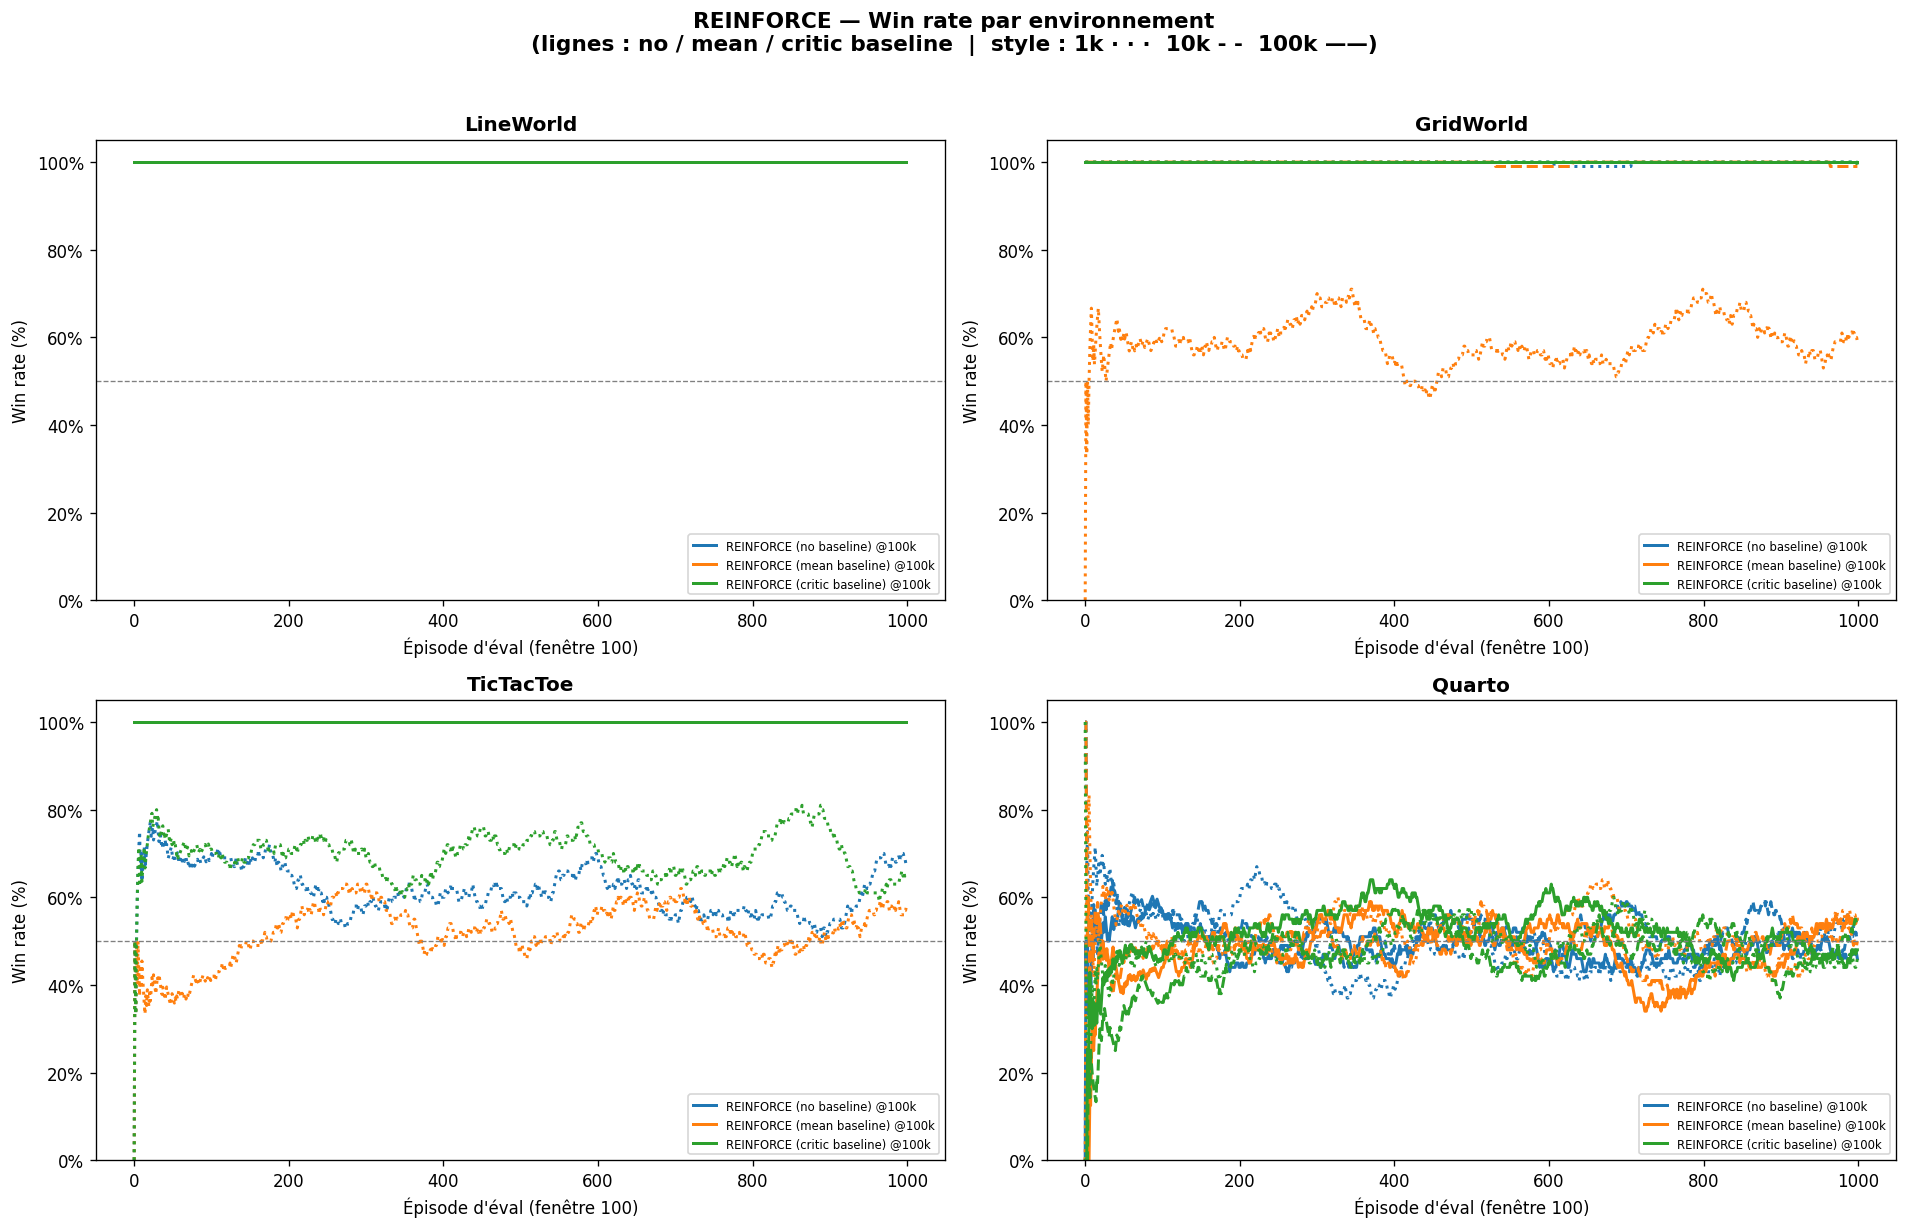

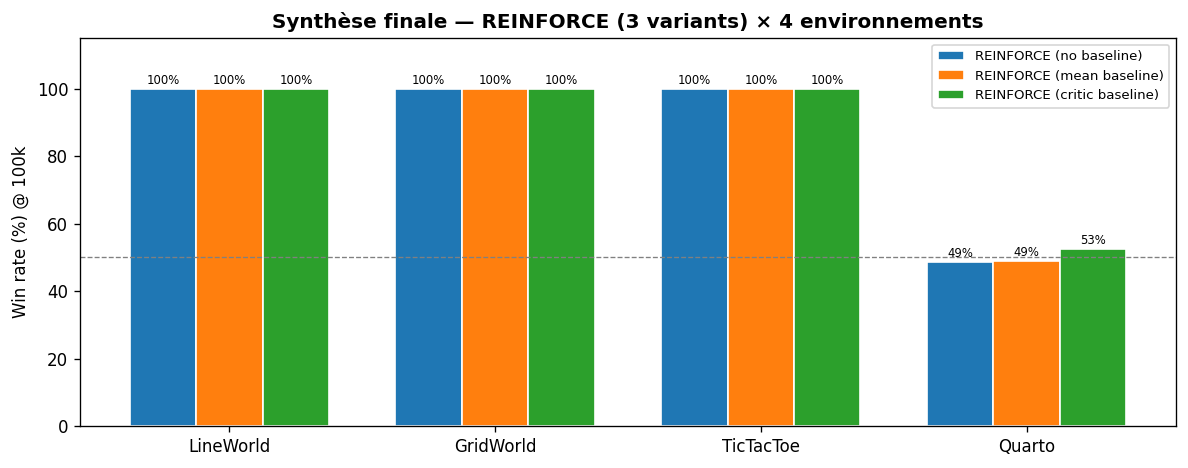

In [47]:
import pandas as pd

CHECKPOINTS_LABEL = {1_000: "1k", 10_000: "10k", 100_000: "100k"}

REINFORCE_AGENTS = [
    ("reinforce", "reinforce_no_baseline",     "REINFORCE (no baseline)"),
    ("reinforce", "reinforce_mean_baseline",   "REINFORCE (mean baseline)"),
    ("reinforce", "reinforce_critic_baseline", "REINFORCE (critic baseline)"),
]

ENVS_LABEL = {
    "LineWorldEnv":  "LineWorld",
    "GridWorldEnv":  "GridWorld",
    "TicTacToeEnv":  "TicTacToe",
    "QuartoEnv":     "Quarto",
}

# ── 1. Tableau win rate : agents × (env @ checkpoint) ──────────────────────
rows = []
for algo_folder, agent_name, label in REINFORCE_AGENTS:
    row = {"Agent": label}
    for env_name, env_label in ENVS_LABEL.items():
        for ckpt, ckpt_label in CHECKPOINTS_LABEL.items():
            path = build_path(algo_folder, agent_name, env_name, ckpt)
            data = load_json(path)
            wr = data["summary"]["win_rate"] * 100 if data else float("nan")
            row[f"{env_label}\n@{ckpt_label}"] = f"{wr:.1f}%" if not np.isnan(wr) else "—"
    rows.append(row)

df = pd.DataFrame(rows).set_index("Agent")
display(df.style
    .set_caption("Win rate (%) — REINFORCE × Environnements × Checkpoints")
    .set_table_styles([{"selector": "th", "props": [("font-size", "9px")]}])
)

# ── 2. Courbes win rate : 1 subplot par env, 3 agents, 3 checkpoints ───────
COLORS_REINFORCE = {
    "reinforce_no_baseline":     "#1f77b4",
    "reinforce_mean_baseline":   "#ff7f0e",
    "reinforce_critic_baseline": "#2ca02c",
}
LINESTYLES = {1_000: ":", 10_000: "--", 100_000: "-"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "REINFORCE — Win rate par environnement\n"
    "(lignes : no / mean / critic baseline  |  style : 1k · · ·  10k - -  100k ——)",
    fontweight="bold", fontsize=13, y=1.02
)

for ax, (env_name, env_label) in zip(axes.flatten(), ENVS_LABEL.items()):
    for algo_folder, agent_name, label in REINFORCE_AGENTS:
        color = COLORS_REINFORCE[agent_name]
        for ckpt, ls in LINESTYLES.items():
            path = build_path(algo_folder, agent_name, env_name, ckpt)
            data = load_json(path)
            if data is None:
                continue
            rewards = np.array([ep["reward"] for ep in data["episodes"]])
            curve   = rolling(rewards, "winrate", WINDOW)
            ax.plot(
                curve, color=color, linestyle=ls, linewidth=1.8,
                label=f"{label} @{CHECKPOINTS_LABEL[ckpt]}" if ckpt == 100_000 else "_nolegend_"
            )

    ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
    ax.set_ylim(0, 105)
    ax.set_title(env_label, fontweight="bold")
    ax.set_xlabel(f"Épisode d'éval (fenêtre {WINDOW})")
    ax.set_ylabel("Win rate (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
    ax.legend(loc="lower right", fontsize=7)

plt.tight_layout()
plt.show()

# ── 3. Bar chart synthèse : meilleur agent par env au checkpoint 100k ──────
fig, ax = plt.subplots(figsize=(10, 4))

x       = np.arange(len(ENVS_LABEL))
width   = 0.25
offsets = [-width, 0, width]

for offset, (algo_folder, agent_name, label) in zip(offsets, REINFORCE_AGENTS):
    win_rates = []
    for env_name in ENVS_LABEL:
        path = build_path(algo_folder, agent_name, env_name, 100_000)
        data = load_json(path)
        wr = data["summary"]["win_rate"] * 100 if data else 0
        win_rates.append(wr)
    bars = ax.bar(x + offset, win_rates, width, label=label,
                  color=COLORS_REINFORCE[agent_name], edgecolor="white")
    for bar, val in zip(bars, win_rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=7)

ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(list(ENVS_LABEL.values()))
ax.set_ylim(0, 115)
ax.set_ylabel("Win rate (%) @ 100k")
ax.set_title("Synthèse finale — REINFORCE (3 variants) × 4 environnements", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Synthèse MCTS & MCRR (Planning)

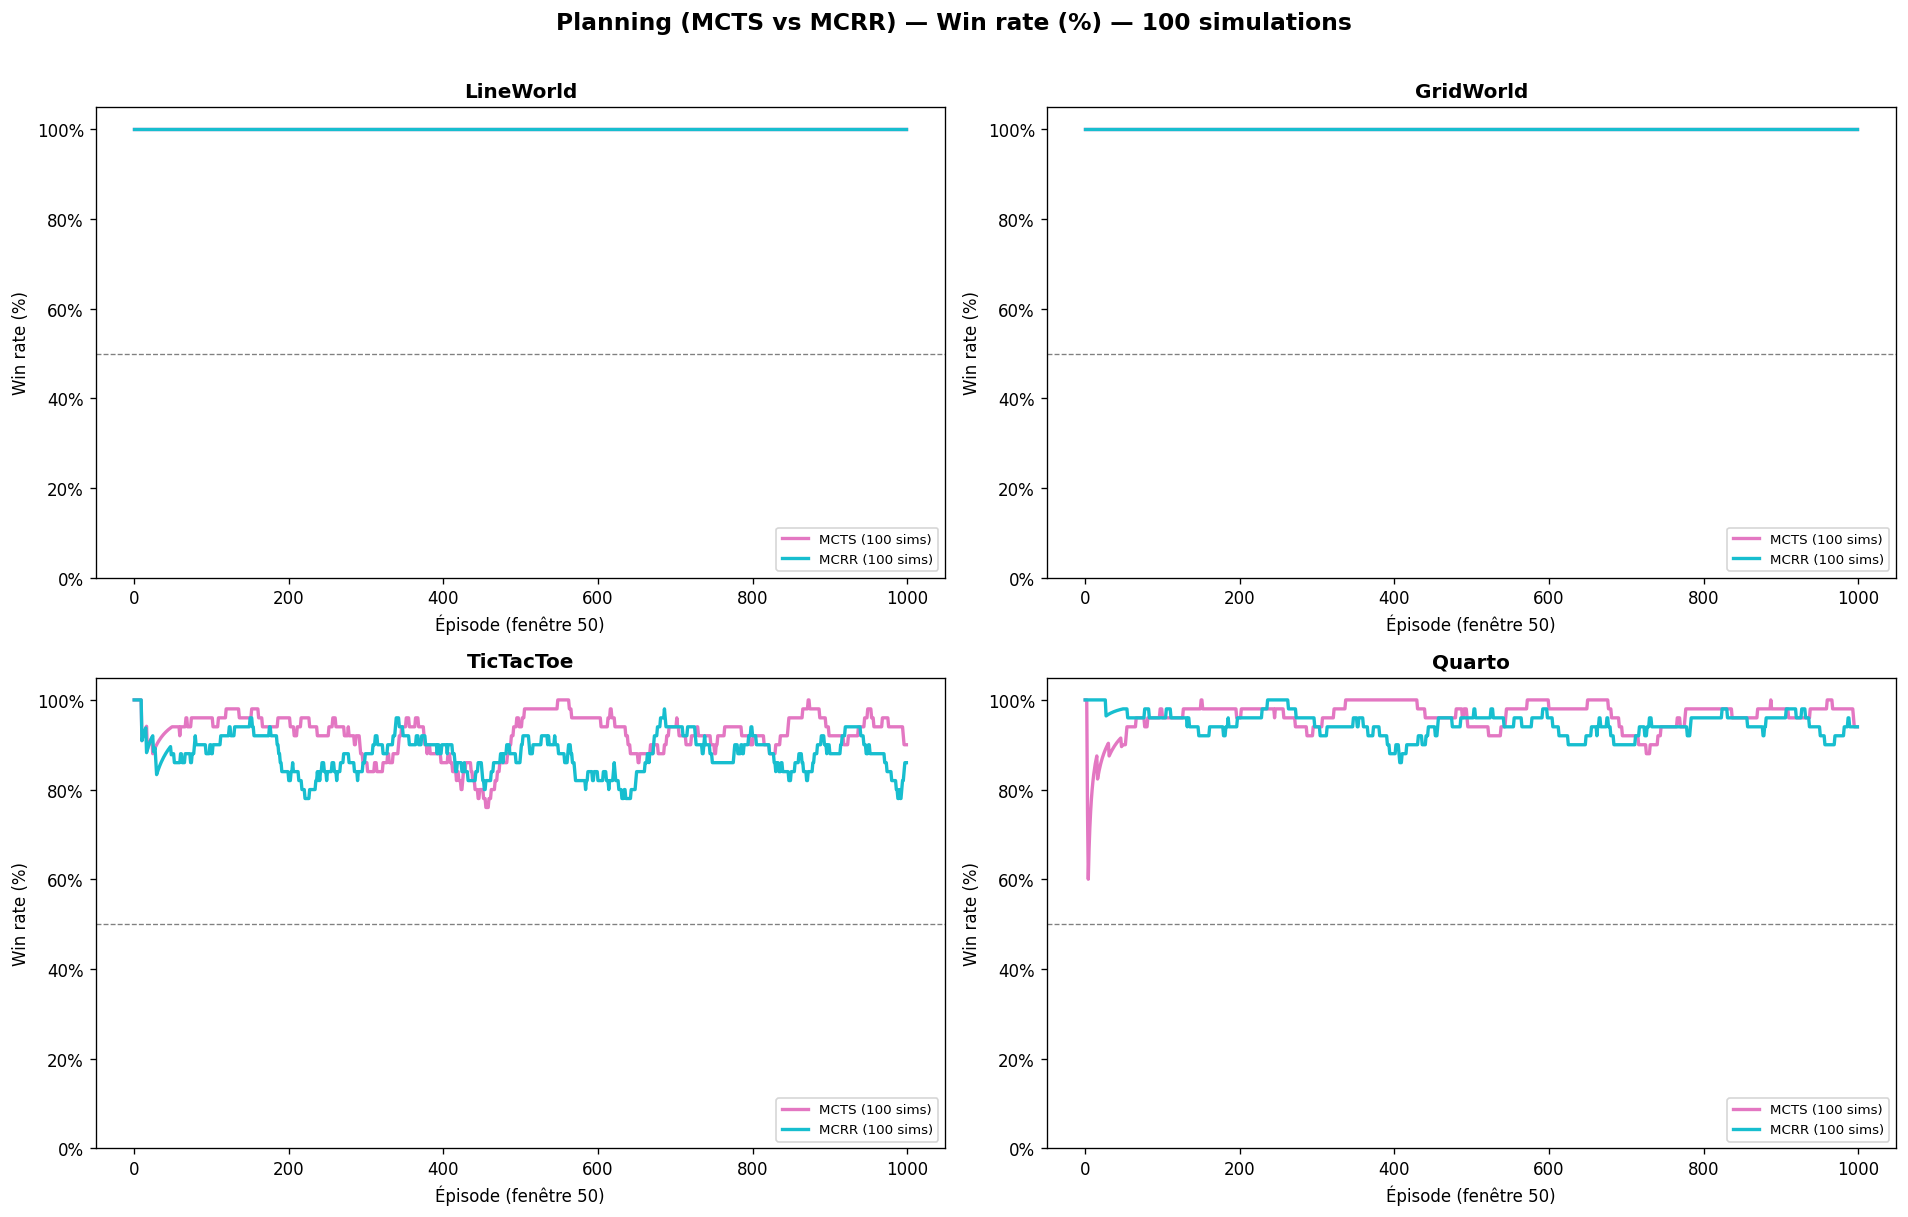

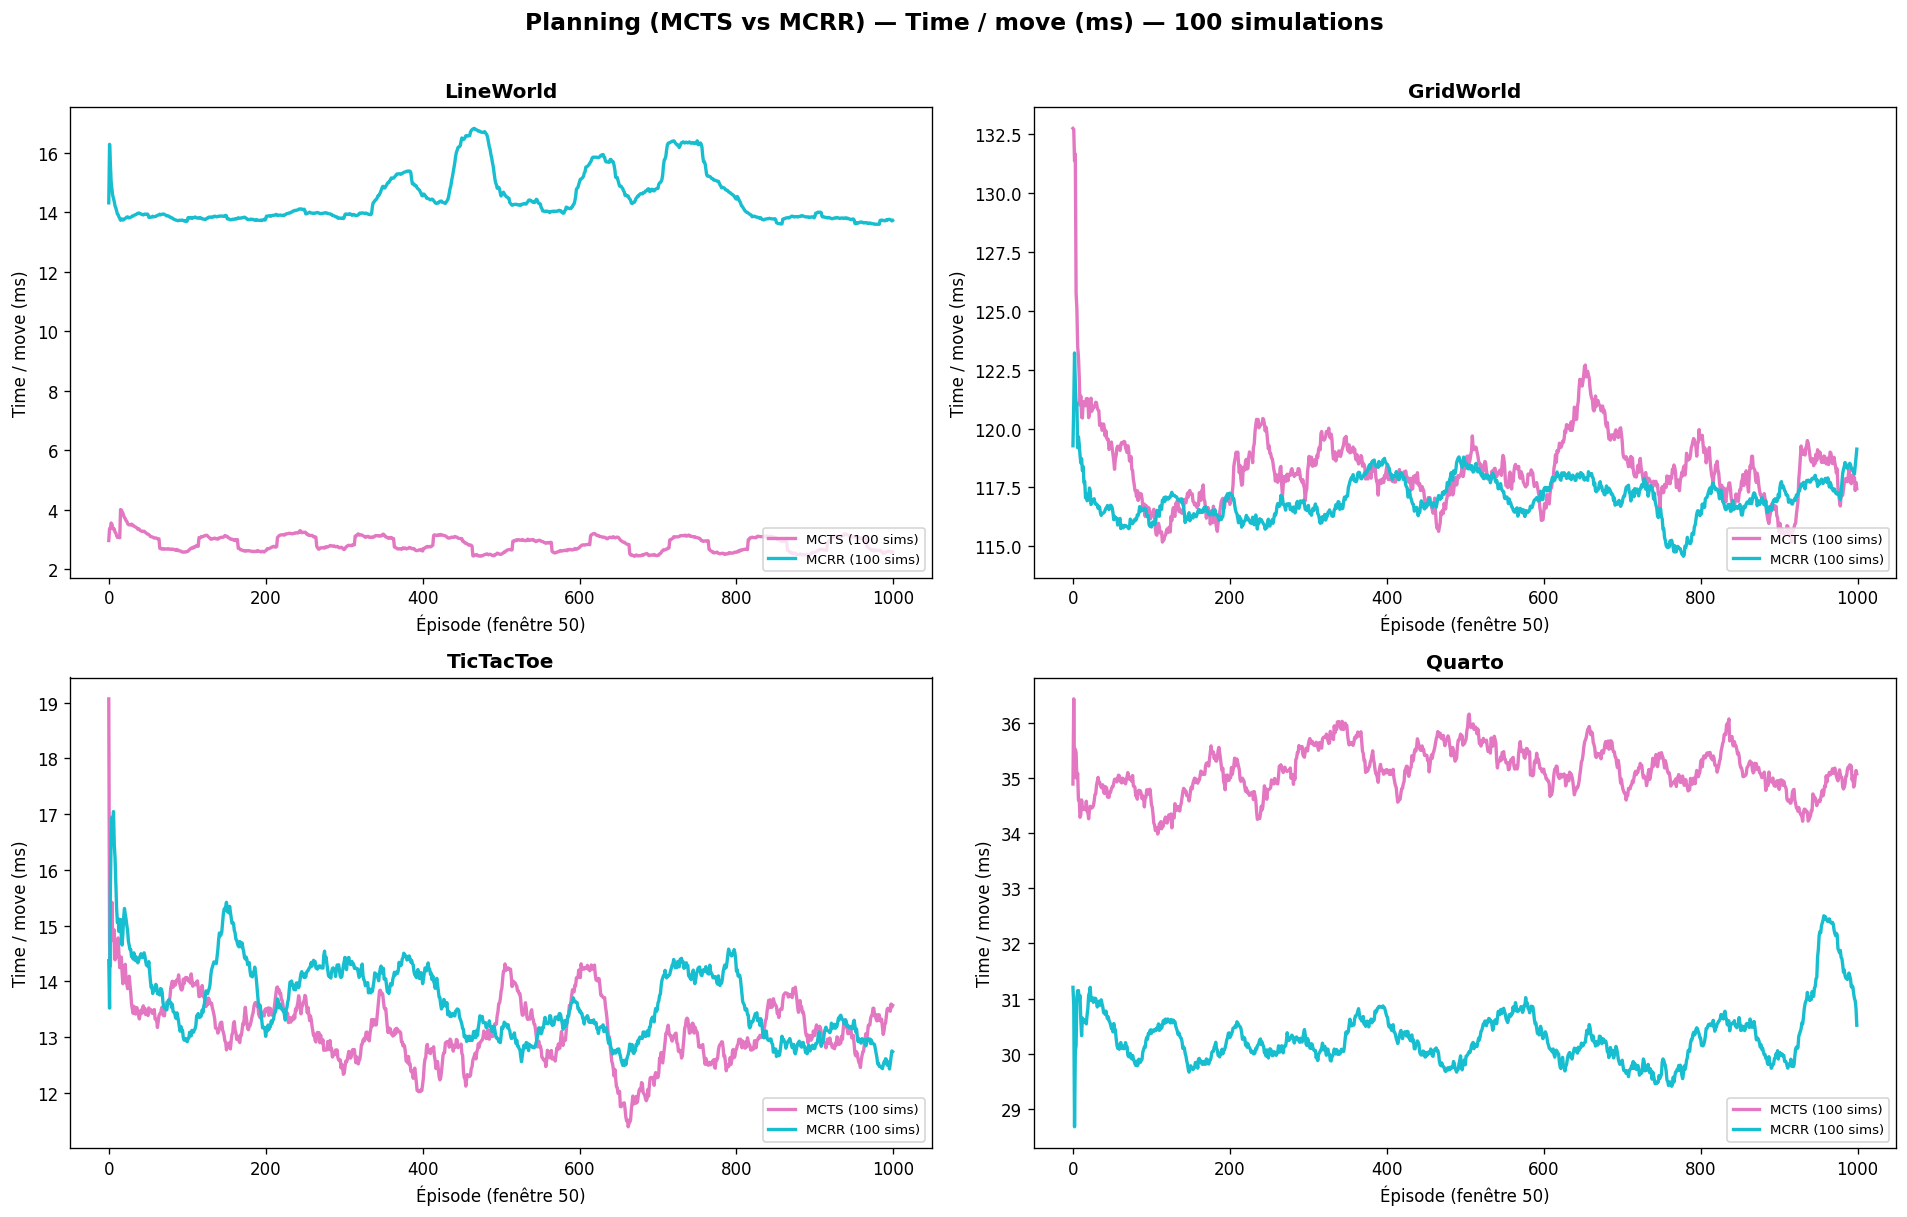

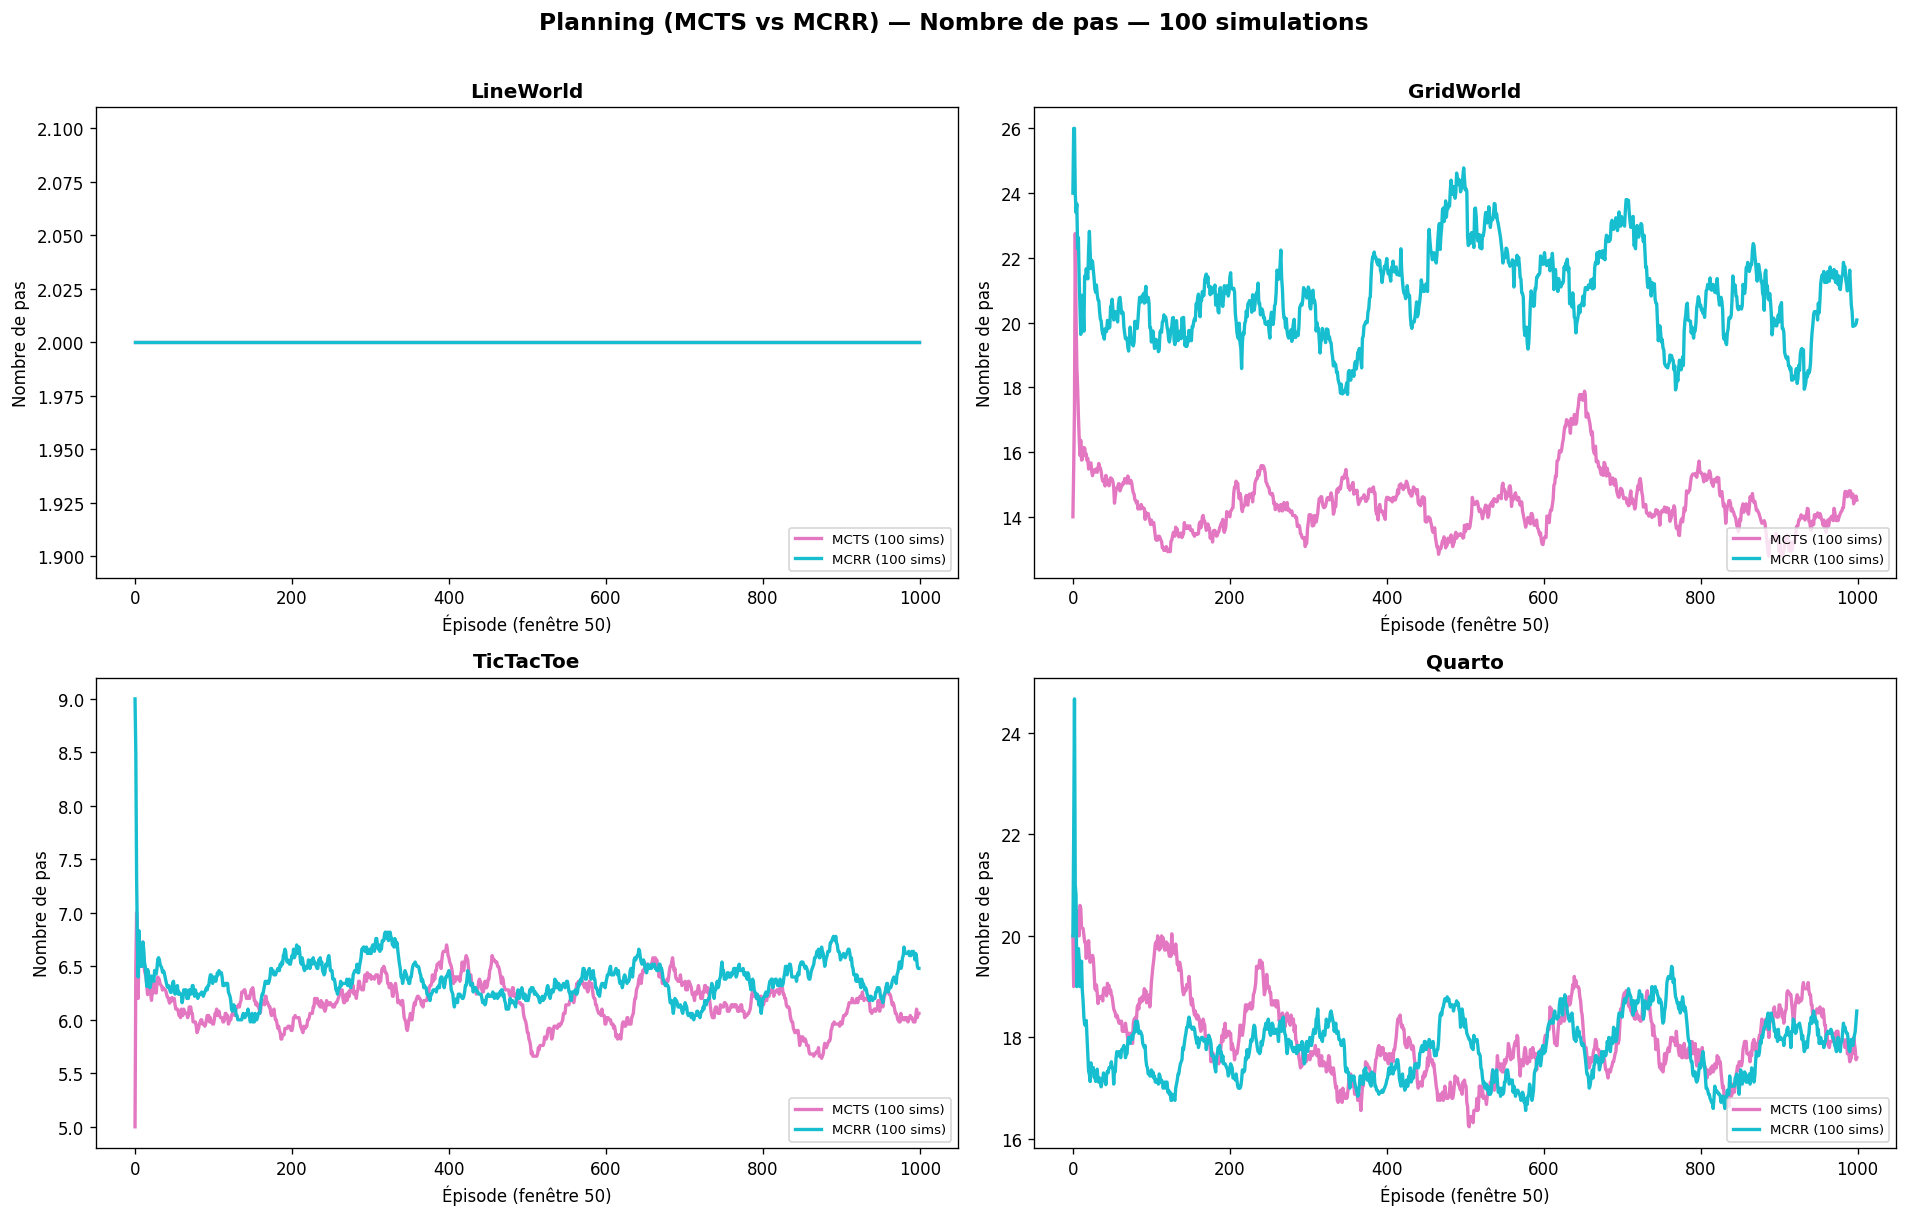

,LineWorld WR,LineWorld ms,LineWorld steps,GridWorld WR,GridWorld ms,GridWorld steps,TicTacToe WR,TicTacToe ms,TicTacToe steps,Quarto WR,Quarto ms,Quarto steps
Agent,,,,,,,,,,,,
MCTS (100 sims),100.0%,2.9,2.0,100.0%,118.1,14.4,92.4%,13.1,6.1,96.5%,35.1,18.0
MCRR (100 sims),100.0%,14.4,2.0,100.0%,117.1,20.8,87.7%,13.6,6.4,94.6%,30.3,17.8


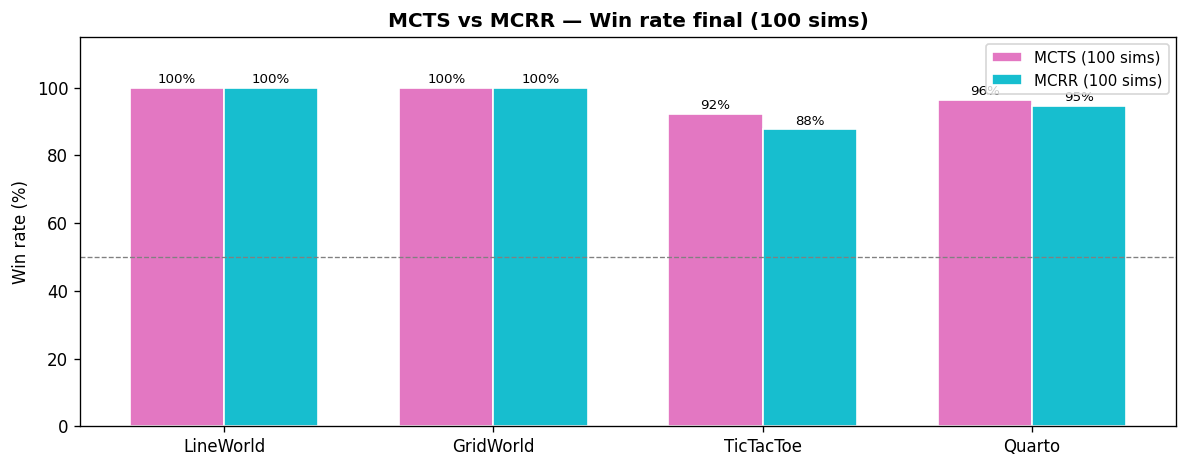

In [48]:
# ── CONFIG planning ─────────────────────────────────────────────────────────

PLANNING_AGENTS = [
    ("mcts",  "mcts_sim100",  "MCTS (100 sims)",  "#e377c2"),
    ("mcrr",  "mcrr_sim100",  "MCRR (100 sims)",  "#17becf"),
]

METRICS_PLANNING = {
    "winrate":       ("Win rate (%)",       "reward",           "winrate"),
    "time_per_move": ("Time / move (ms)",   "time_per_move_ms", "time"),
    "n_steps":       ("Nombre de pas",      "n_steps",          "steps"),
}

ENVS_LABEL = {
    "LineWorldEnv": "LineWorld",
    "GridWorldEnv": "GridWorld",
    "TicTacToeEnv": "TicTacToe",
    "QuartoEnv":    "Quarto",
}

WINDOW = 50


def build_path_planning(algo_folder, agent_name, env_name, seed=42):
    return os.path.join(
        settings.training_logs_dir,
        algo_folder, env_name,
        f"seed_{seed}", "eval",
        f"{agent_name}.json",
    )


def load_planning_series(env_name):
    series = []
    for algo_folder, agent_name, label, color in PLANNING_AGENTS:
        path = build_path_planning(algo_folder, agent_name, env_name)
        data = load_json(path)
        if data is None:
            series.append((label, color, None))
            continue
        episodes = data.get("episodes", [])
        series.append((label, color, episodes))
    return series


def rolling_planning(episodes, field, metric_type, window):
    arr = np.array([ep[field] for ep in episodes])
    out = np.zeros(len(arr))
    for i in range(len(arr)):
        chunk = arr[max(0, i - window + 1):i + 1]
        if metric_type == "winrate":
            out[i] = np.mean(chunk == 1) * 100
        else:
            out[i] = np.mean(chunk)
    return out


# ── 1. Une image par métrique : grille 2×2 des 4 envs ──────────────────────

for metric_key, (ylabel, field, metric_type) in METRICS_PLANNING.items():

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(
        f"Planning (MCTS vs MCRR) — {ylabel} — 100 simulations",
        fontweight="bold", fontsize=14, y=1.01
    )

    for ax, (env_name, env_label) in zip(axes.flatten(), ENVS_LABEL.items()):
        series = load_planning_series(env_name)

        for label, color, episodes in series:
            if episodes is None:
                continue
            curve = rolling_planning(episodes, field, metric_type, WINDOW)
            ax.plot(curve, label=label, color=color, linewidth=2)

        if metric_type == "winrate":
            ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
            ax.set_ylim(0, 105)
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))

        ax.set_title(env_label, fontweight="bold")
        ax.set_xlabel(f"Épisode (fenêtre {WINDOW})")
        ax.set_ylabel(ylabel)
        ax.legend(loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.show()


# ── 2. Tableau synthèse ─────────────────────────────────────────────────────

rows = []
for algo_folder, agent_name, label, _ in PLANNING_AGENTS:
    row = {"Agent": label}
    for env_name, env_label in ENVS_LABEL.items():
        path = build_path_planning(algo_folder, agent_name, env_name)
        data = load_json(path)
        if data:
            s = data["summary"]
            row[f"{env_label} WR"]   = f"{s['win_rate']*100:.1f}%"
            row[f"{env_label} ms"]   = f"{s['mean_time_per_move_ms']:.1f}"
            row[f"{env_label} steps"]= f"{s['mean_steps']:.1f}"
        else:
            row[f"{env_label} WR"]   = "—"
            row[f"{env_label} ms"]   = "—"
            row[f"{env_label} steps"]= "—"
    rows.append(row)

df_planning = pd.DataFrame(rows).set_index("Agent")
display(df_planning.style.set_caption(
    "Synthèse MCTS vs MCRR — Win rate / Time per move (ms) / Steps"
))


# ── 3. Bar chart comparatif win rate ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))
x      = np.arange(len(ENVS_LABEL))
width  = 0.35

for i, (algo_folder, agent_name, label, color) in enumerate(PLANNING_AGENTS):
    offset = (i - 0.5) * width
    win_rates = []
    for env_name in ENVS_LABEL:
        path = build_path_planning(algo_folder, agent_name, env_name)
        data = load_json(path)
        wr = data["summary"]["win_rate"] * 100 if data else 0
        win_rates.append(wr)
    bars = ax.bar(x + offset, win_rates, width, label=label,
                  color=color, edgecolor="white")
    for bar, val in zip(bars, win_rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=8)

ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(list(ENVS_LABEL.values()))
ax.set_ylim(0, 115)
ax.set_ylabel("Win rate (%)")
ax.set_title("MCTS vs MCRR — Win rate final (100 sims)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Synthèse Expert Apprenti

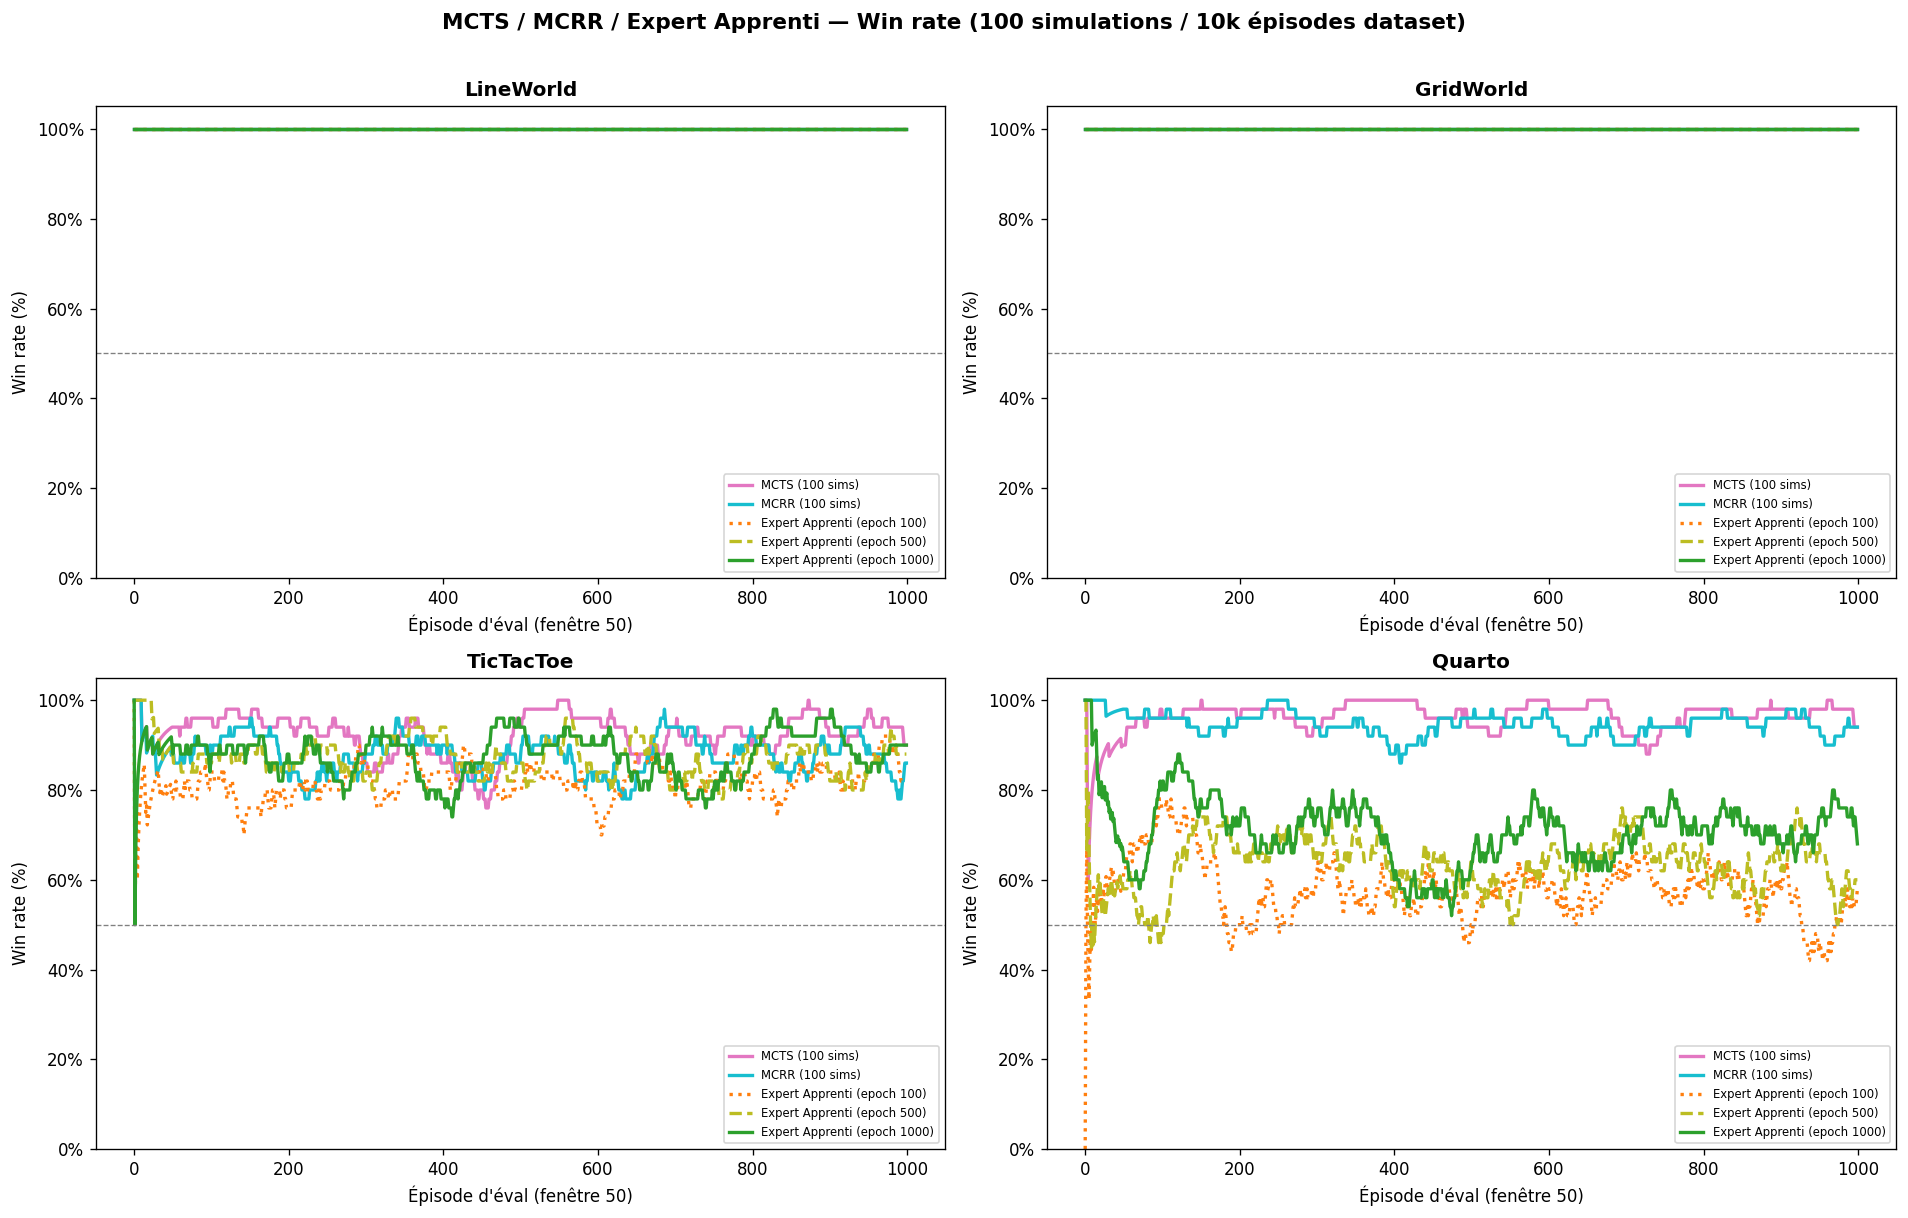

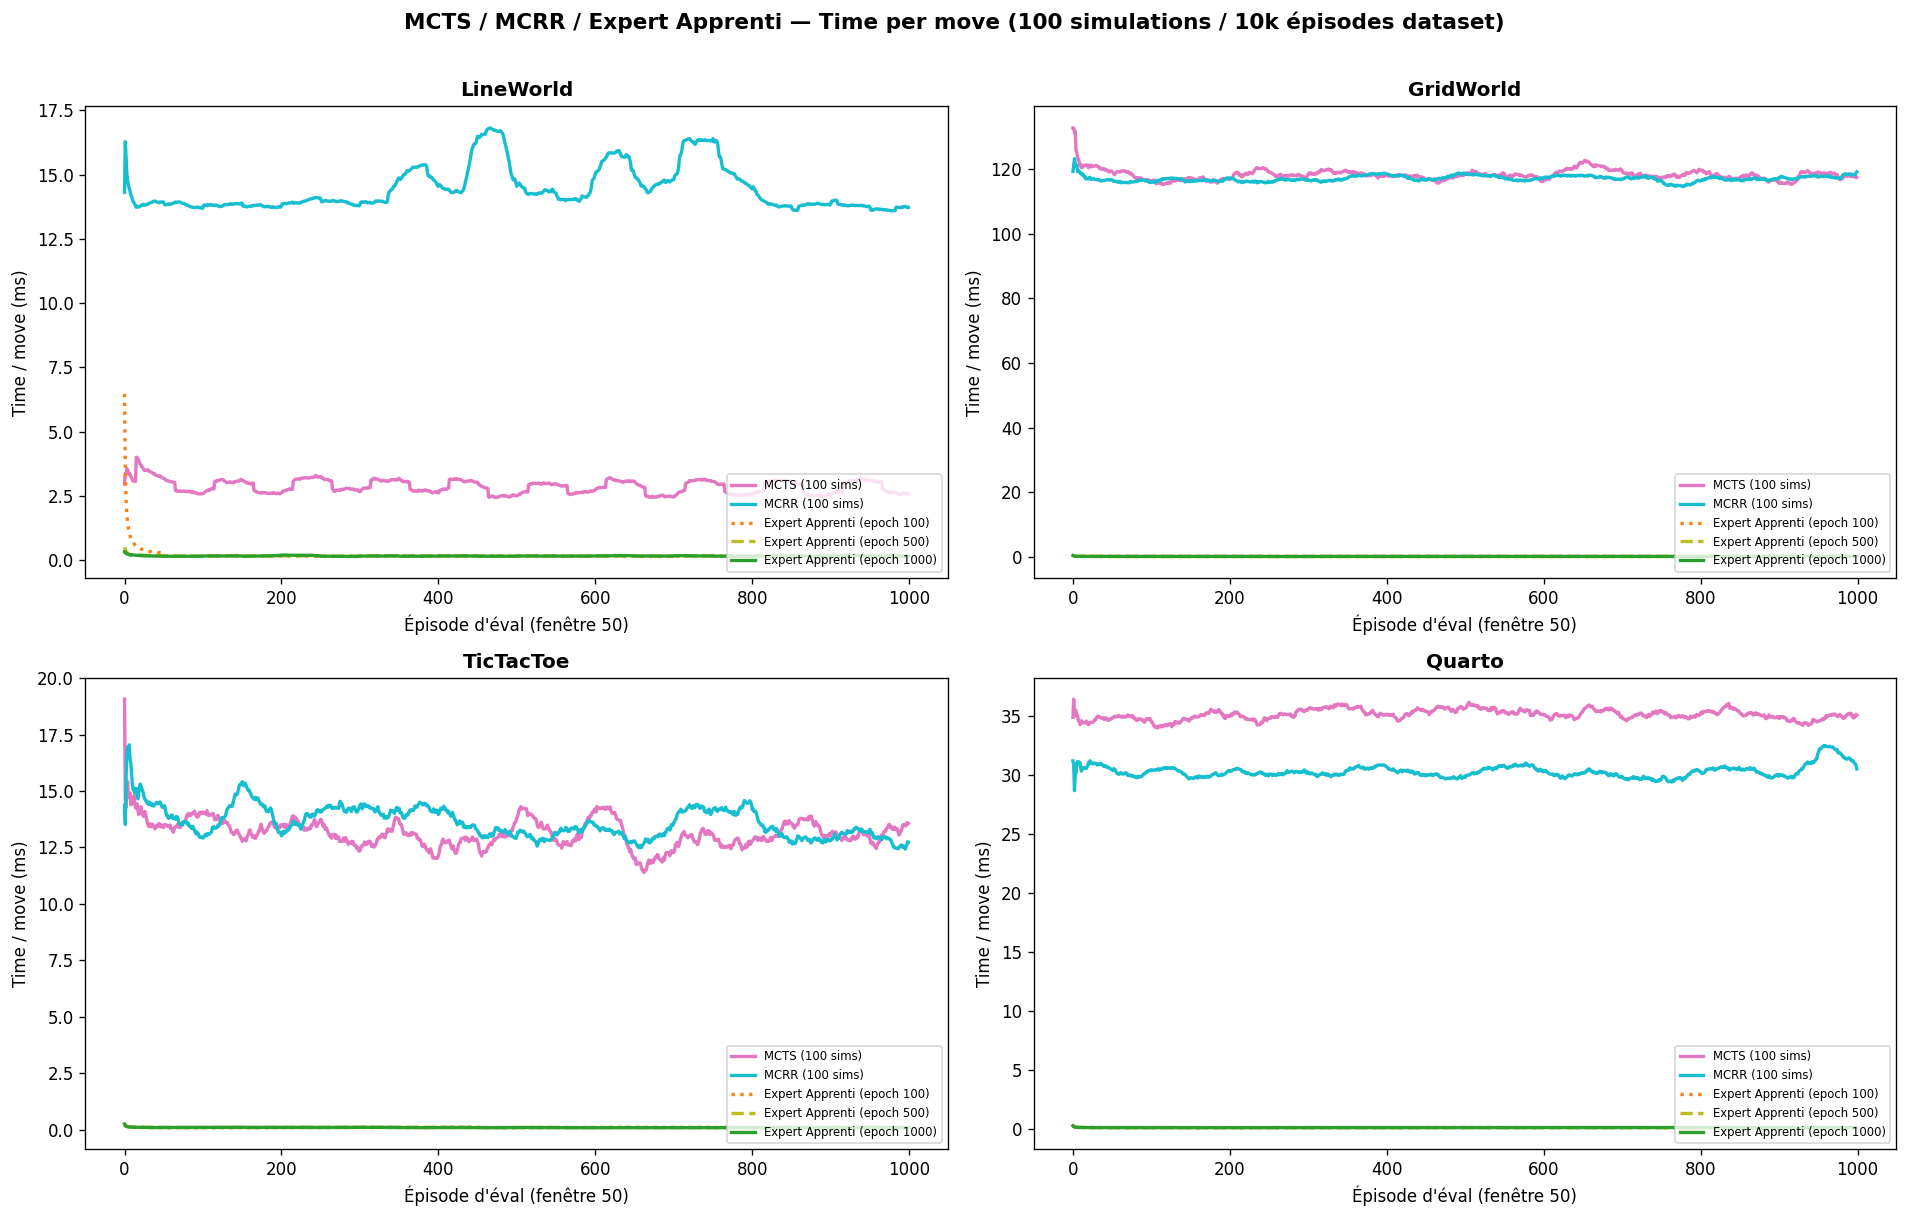

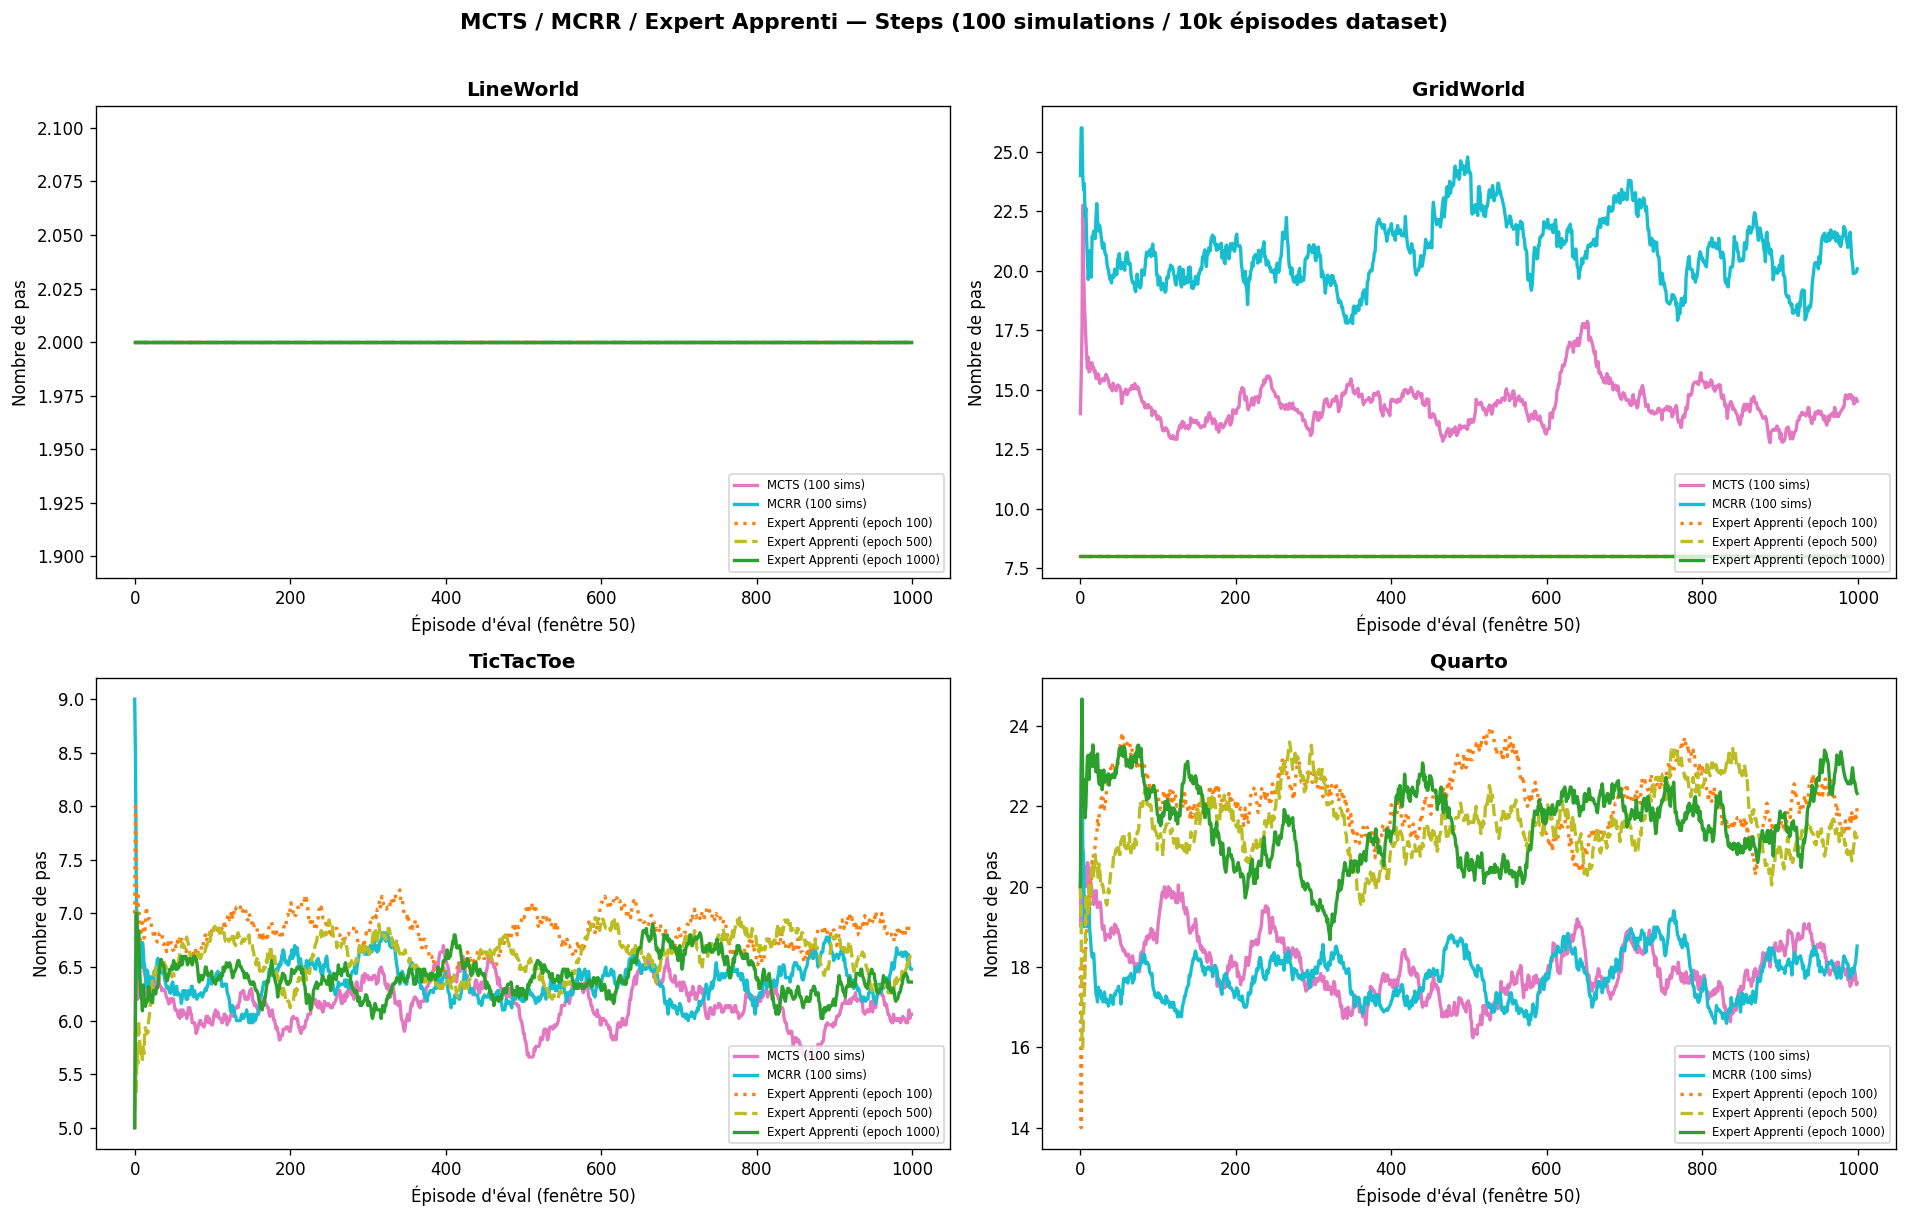

,LineWorld WR,LineWorld ms,LineWorld steps,GridWorld WR,GridWorld ms,GridWorld steps,TicTacToe WR,TicTacToe ms,TicTacToe steps,Quarto WR,Quarto ms,Quarto steps
Algo,,,,,,,,,,,,
MCTS (100 sims),100.0%,2.85,2.0,100.0%,118.14,14.4,92.4%,13.13,6.1,96.5%,35.14,18.0
MCRR (100 sims),100.0%,14.43,2.0,100.0%,117.11,20.8,87.7%,13.58,6.4,94.6%,30.30,17.8
Expert Apprenti (epoch 100),100.0%,0.17,2.0,100.0%,0.16,8.0,81.7%,0.10,6.8,58.1%,0.09,22.2
Expert Apprenti (epoch 500),100.0%,0.17,2.0,100.0%,0.17,8.0,86.8%,0.10,6.6,63.5%,0.09,21.6
Expert Apprenti (epoch 1000),100.0%,0.17,2.0,100.0%,0.16,8.0,87.8%,0.10,6.4,70.1%,0.09,21.6


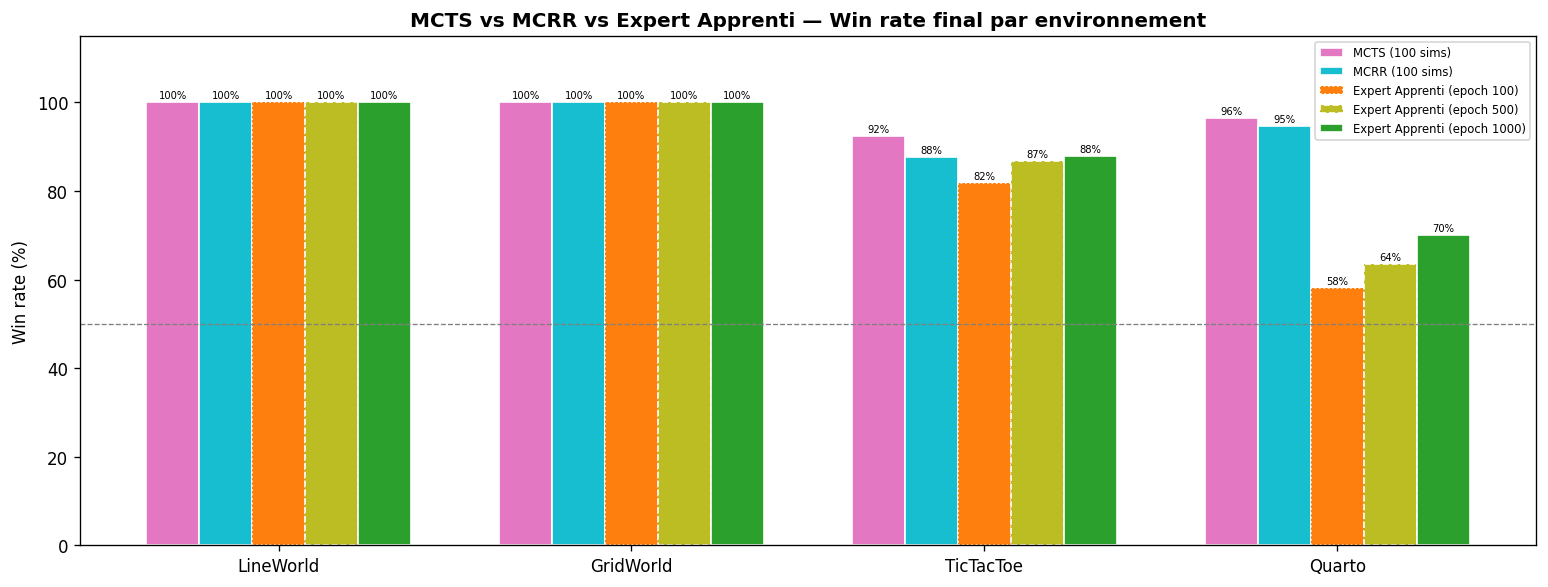

In [49]:
# ── CONFIG ───────────────────────────────────────────────────────────────────

EP_DATASET = 10_000
SIM        = 100
AGENT_TAG  = f"expert_apprenti_ep{EP_DATASET}_sim{SIM}"
WINDOW     = 50

ENVS_LABEL = {
    "LineWorldEnv": "LineWorld",
    "GridWorldEnv": "GridWorld",
    "TicTacToeEnv": "TicTacToe",
    "QuartoEnv":    "Quarto",
}

# Les 3 algos à comparer + leurs epochs/checkpoints
# MCTS et MCRR : 1 seul fichier par env (100 sims)
# Expert Apprenti : 3 checkpoints (100, 500, 1000 epochs)
ALGO_COLORS = {
    "mcts":                        "#e377c2",
    "mcrr":                        "#17becf",
    "expert_apprenti_epoch100":    "#ff7f0e",
    "expert_apprenti_epoch500":    "#bcbd22",
    "expert_apprenti_epoch1000":   "#2ca02c",
}
ALGO_LABELS = {
    "mcts":                        "MCTS (100 sims)",
    "mcrr":                        "MCRR (100 sims)",
    "expert_apprenti_epoch100":    "Expert Apprenti (epoch 100)",
    "expert_apprenti_epoch500":    "Expert Apprenti (epoch 500)",
    "expert_apprenti_epoch1000":   "Expert Apprenti (epoch 1000)",
}
ALGO_LINESTYLES = {
    "mcts":                        "-",
    "mcrr":                        "-",
    "expert_apprenti_epoch100":    ":",
    "expert_apprenti_epoch500":    "--",
    "expert_apprenti_epoch1000":   "-",
}


# ── PATH BUILDERS ────────────────────────────────────────────────────────────

def path_mcts(env_name, seed=42):
    return os.path.join(
        settings.training_logs_dir,
        "mcts", env_name, f"seed_{seed}", "eval",
        "mcts_sim100.json",
    )

def path_mcrr(env_name, seed=42):
    return os.path.join(
        settings.training_logs_dir,
        "mcrr", env_name, f"seed_{seed}", "eval",
        "mcrr_sim100.json",
    )

def path_ea(env_name, epoch_ckpt, seed=42):
    return os.path.join(
        settings.training_logs_dir,
        "expert_apprenti", env_name, f"seed_{seed}", "eval",
        f"{AGENT_TAG}_epoch{epoch_ckpt}.json",
    )


# ── LOADER UNIFIÉ ────────────────────────────────────────────────────────────

def load_all_series(env_name, seed=42):
    """
    Retourne un dict algo_key -> (rewards, times, steps) ou None.
    Les champs episodes sont identiques pour les 3 algos.
    """
    paths = {
        "mcts":                      path_mcts(env_name, seed),
        "mcrr":                      path_mcrr(env_name, seed),
        "expert_apprenti_epoch100":  path_ea(env_name, 100,   seed),
        "expert_apprenti_epoch500":  path_ea(env_name, 500,   seed),
        "expert_apprenti_epoch1000": path_ea(env_name, 1_000, seed),
    }
    out = {}
    for key, path in paths.items():
        data = load_json(path)
        if data is None:
            out[key] = None
            continue
        eps     = data["episodes"]
        rewards = np.array([ep["reward"]           for ep in eps])
        times   = np.array([ep["time_per_move_ms"]  for ep in eps])
        steps   = np.array([ep["n_steps"]           for ep in eps])
        summary = data["summary"]
        out[key] = (rewards, times, steps, summary)
    return out


def roll(arr, metric_type, window):
    out = np.zeros(len(arr))
    for i in range(len(arr)):
        chunk = arr[max(0, i - window + 1):i + 1]
        out[i] = np.mean(chunk == 1) * 100 if metric_type == "winrate" else np.mean(chunk)
    return out


# ── PLOT HELPER ───────────────────────────────────────────────────────────────

def plot_metric_grid(metric_type, ylabel, title_suffix, field_idx):
    """
    Grille 2×2, une courbe par algo sur chaque env.
    field_idx : 0=rewards, 1=times, 2=steps
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(
        f"MCTS / MCRR / Expert Apprenti — {title_suffix} (100 simulations / 10k épisodes dataset)",
        fontweight="bold", fontsize=13, y=1.01
    )

    for ax, (env_name, env_label) in zip(axes.flatten(), ENVS_LABEL.items()):
        series = load_all_series(env_name)
        any_plotted = False

        for key, data in series.items():
            if data is None:
                continue
            arr   = data[field_idx]
            curve = roll(arr, metric_type, WINDOW)
            ax.plot(
                curve,
                label=ALGO_LABELS[key],
                color=ALGO_COLORS[key],
                linestyle=ALGO_LINESTYLES[key],
                linewidth=2,
            )
            any_plotted = True

        if metric_type == "winrate":
            ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
            ax.set_ylim(0, 105)
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))

        ax.set_title(env_label, fontweight="bold")
        ax.set_xlabel(f"Épisode d'éval (fenêtre {WINDOW})")
        ax.set_ylabel(ylabel)
        if any_plotted:
            ax.legend(loc="lower right", fontsize=7)

    plt.tight_layout()
    plt.show()


# ── 1. Win rate ───────────────────────────────────────────────────────────────
plot_metric_grid("winrate", "Win rate (%)",      "Win rate",      field_idx=0)

# ── 2. Time / move ────────────────────────────────────────────────────────────
plot_metric_grid("time",    "Time / move (ms)",  "Time per move", field_idx=1)

# ── 3. Steps ──────────────────────────────────────────────────────────────────
plot_metric_grid("steps",   "Nombre de pas",     "Steps",         field_idx=2)


# ── 4. Tableau synthèse ───────────────────────────────────────────────────────

rows = []
for key in ALGO_LABELS:
    row = {"Algo": ALGO_LABELS[key]}
    for env_name, env_label in ENVS_LABEL.items():
        data = load_all_series(env_name).get(key)
        if data:
            s = data[3]  # summary
            row[f"{env_label} WR"]    = f"{s['win_rate']*100:.1f}%"
            row[f"{env_label} ms"]    = f"{s['mean_time_per_move_ms']:.2f}"
            row[f"{env_label} steps"] = f"{s['mean_steps']:.1f}"
        else:
            row[f"{env_label} WR"]    = "—"
            row[f"{env_label} ms"]    = "—"
            row[f"{env_label} steps"] = "—"
    rows.append(row)

df_all = pd.DataFrame(rows).set_index("Algo")
display(df_all.style.set_caption(
    "Synthèse MCTS / MCRR / Expert Apprenti — Win rate / Time (ms) / Steps"
))


# ── 5. Bar chart win rate comparatif ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5))
n_algos = len(ALGO_LABELS)
x       = np.arange(len(ENVS_LABEL))
width   = 0.15
offsets = np.linspace(-(n_algos - 1) / 2 * width, (n_algos - 1) / 2 * width, n_algos)

for offset, (key, label) in zip(offsets, ALGO_LABELS.items()):
    win_rates = []
    for env_name in ENVS_LABEL:
        data = load_all_series(env_name).get(key)
        wr = data[3]["win_rate"] * 100 if data else 0
        win_rates.append(wr)
    bars = ax.bar(x + offset, win_rates, width,
                  label=label,
                  color=ALGO_COLORS[key],
                  linestyle=ALGO_LINESTYLES[key],
                  edgecolor="white")
    for bar, val in zip(bars, win_rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=6)

ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(list(ENVS_LABEL.values()))
ax.set_ylim(0, 115)
ax.set_ylabel("Win rate (%)")
ax.set_title(
    "MCTS vs MCRR vs Expert Apprenti — Win rate final par environnement",
    fontweight="bold"
)
ax.legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

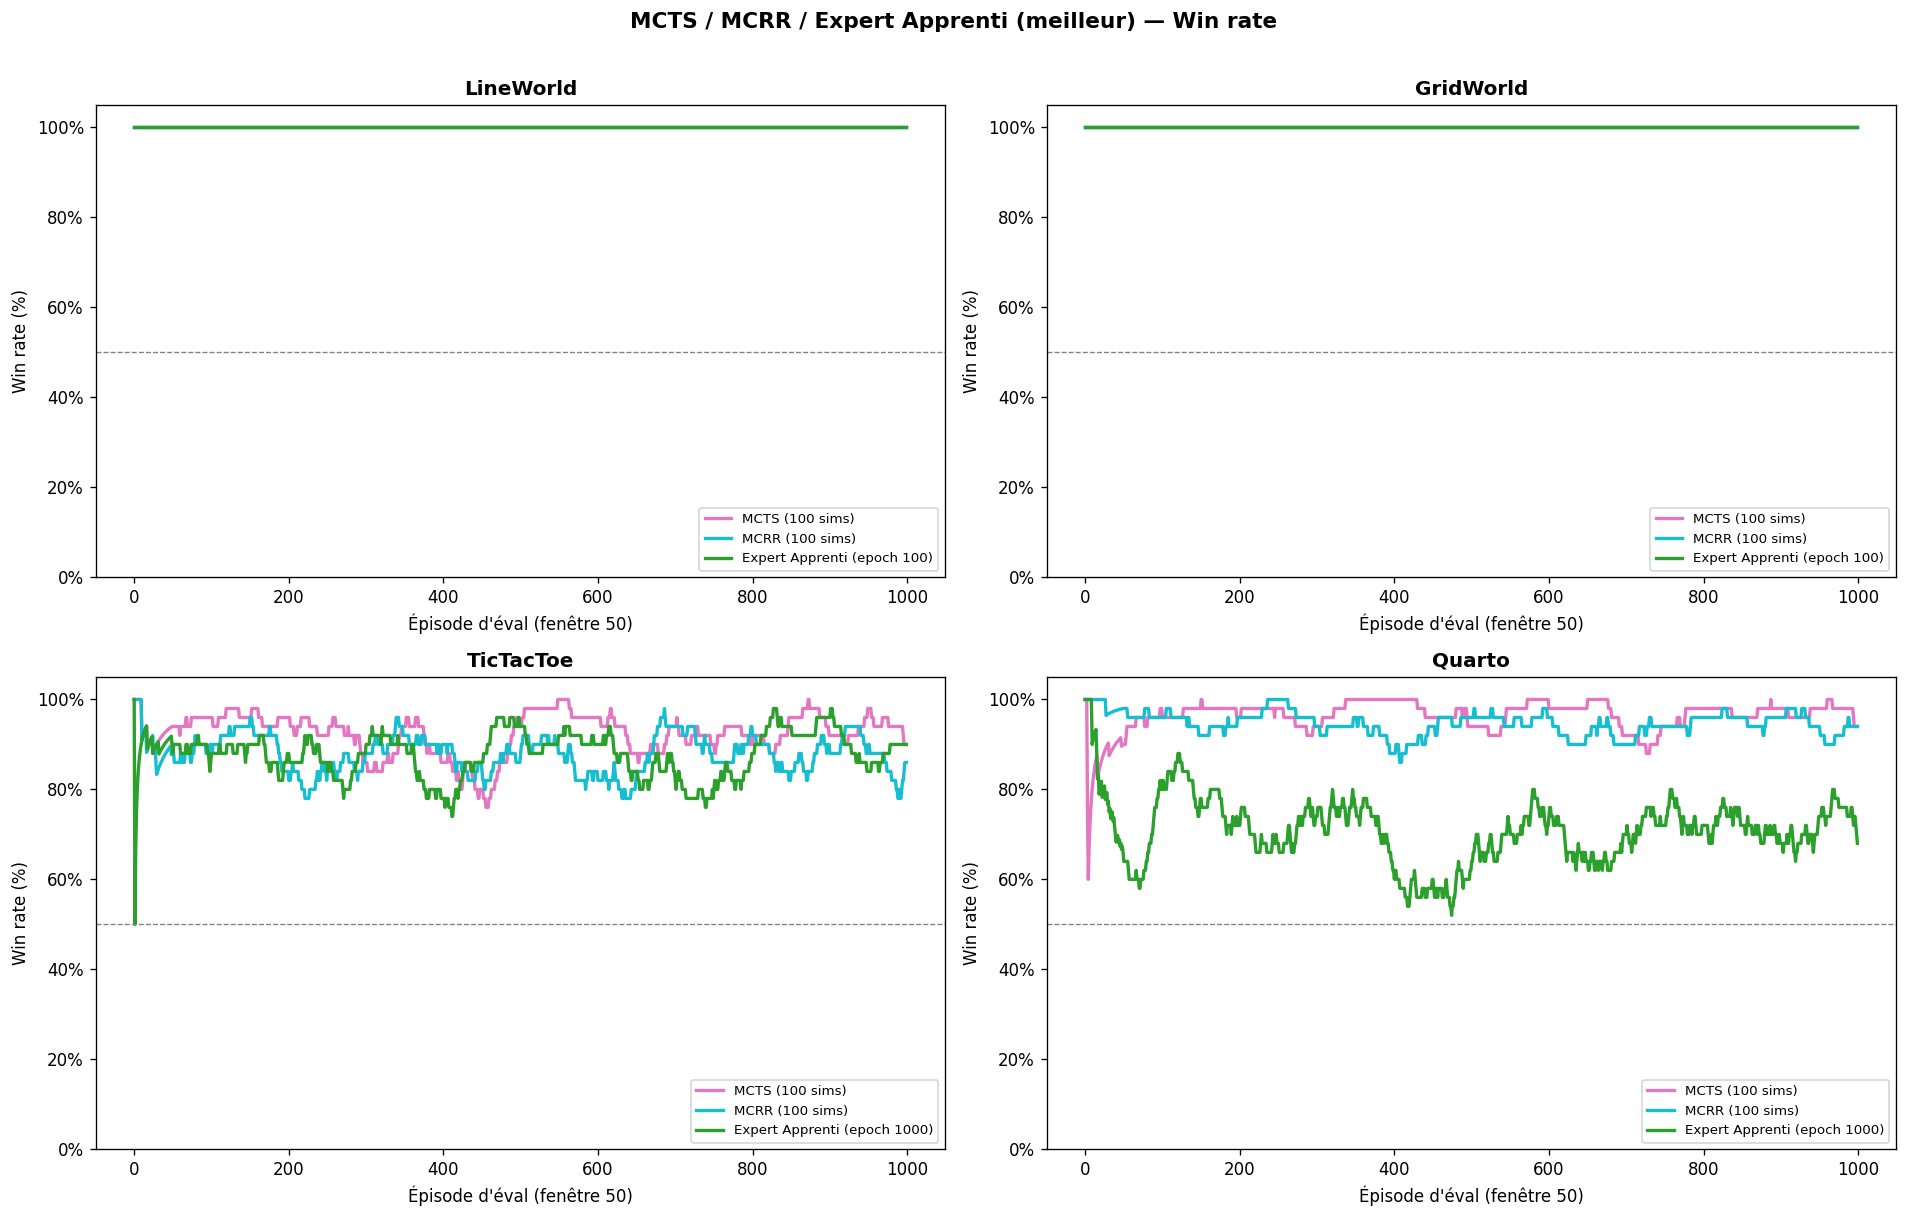

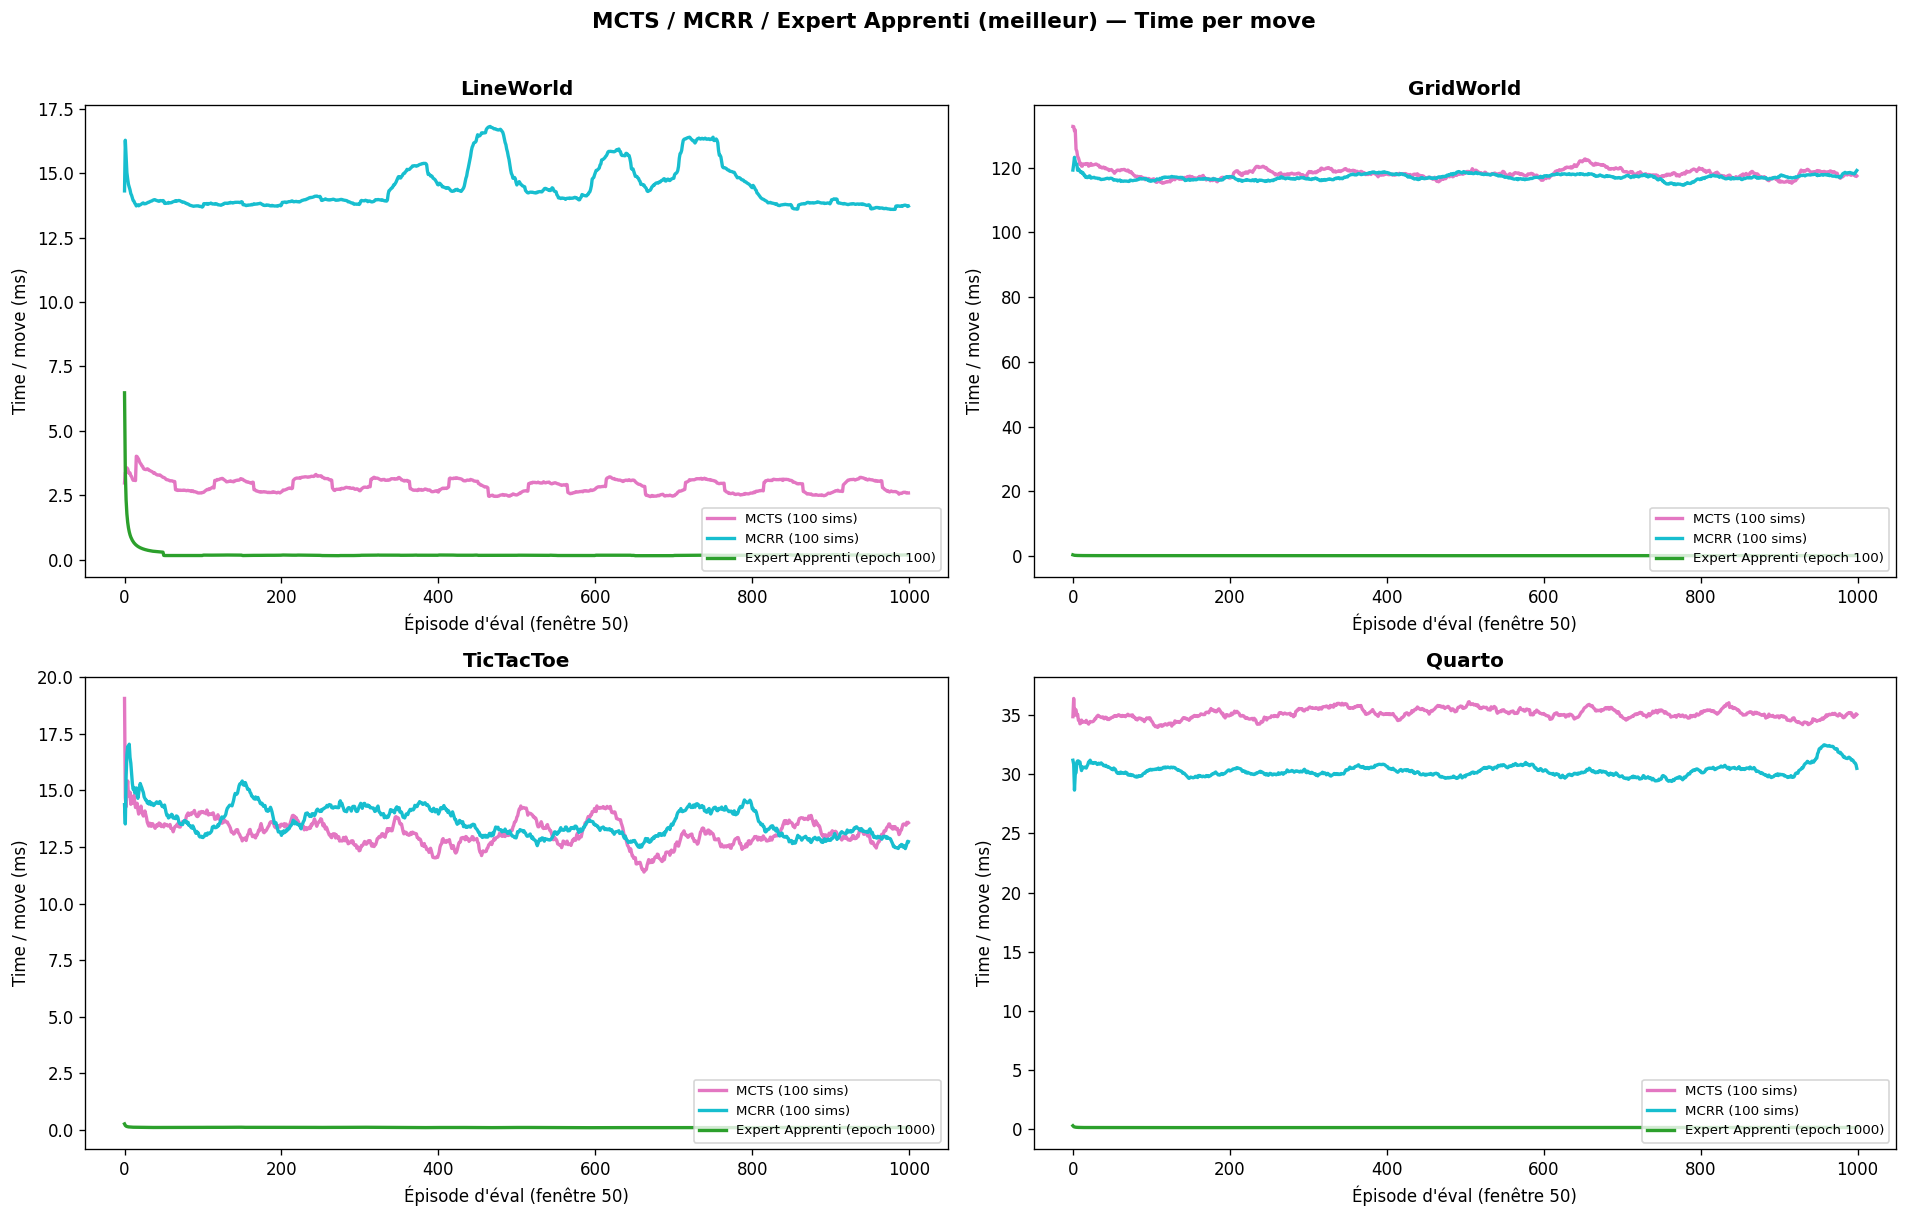

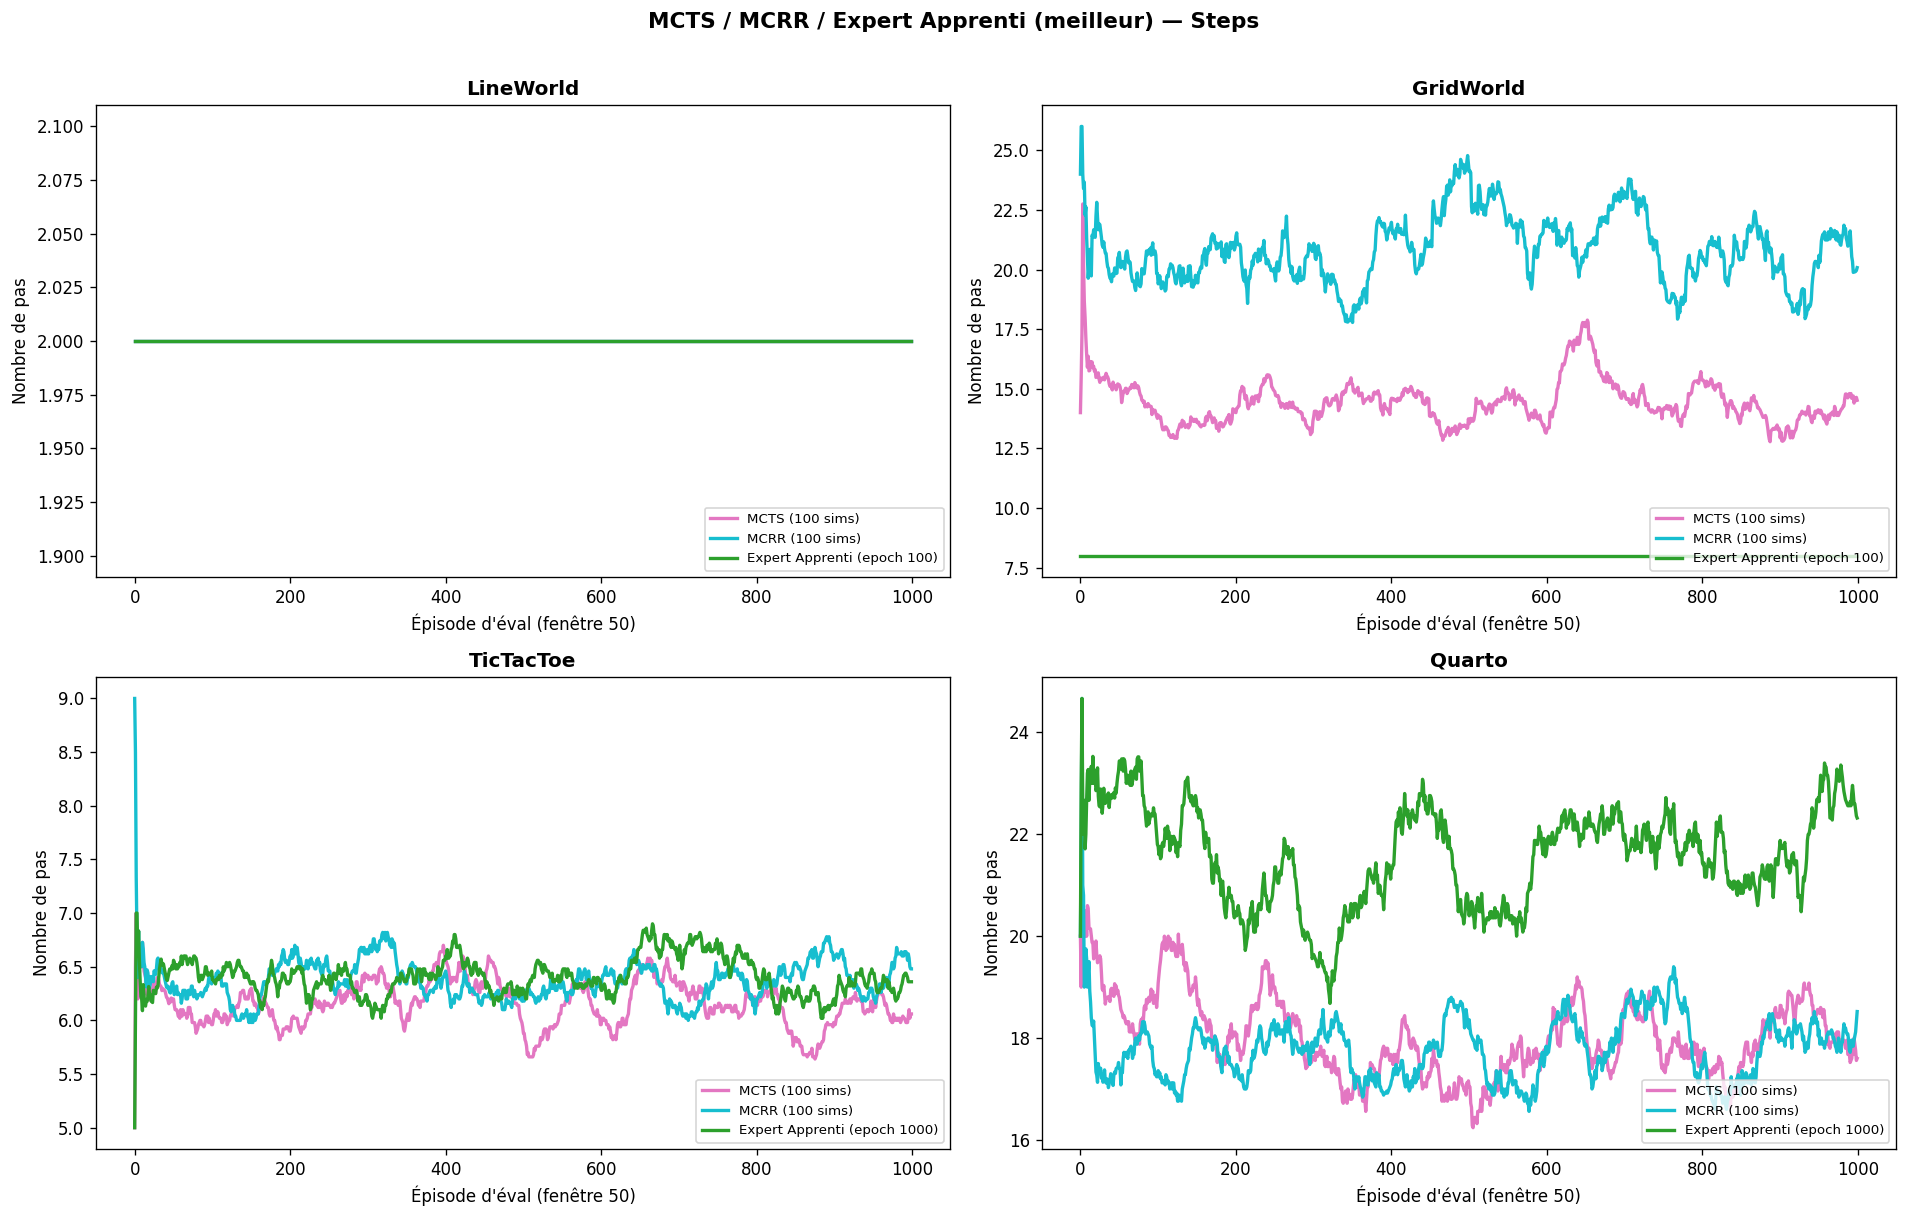

,MCTS (100 sims) WR,MCTS (100 sims) ms,MCTS (100 sims) steps,MCRR (100 sims) WR,MCRR (100 sims) ms,MCRR (100 sims) steps,Expert Apprenti (epoch 100) WR,Expert Apprenti (epoch 100) ms,Expert Apprenti (epoch 100) steps,Expert Apprenti (epoch 1000) WR,Expert Apprenti (epoch 1000) ms,Expert Apprenti (epoch 1000) steps
Env,,,,,,,,,,,,
LineWorld,100.0%,2.85,2.0,100.0%,14.43,2.0,100.0%,0.17,2.0,nan,nan,nan
GridWorld,100.0%,118.14,14.4,100.0%,117.11,20.8,100.0%,0.16,8.0,nan,nan,nan
TicTacToe,92.4%,13.13,6.1,87.7%,13.58,6.4,nan,nan,nan,87.8%,0.10,6.4
Quarto,96.5%,35.14,18.0,94.6%,30.30,17.8,nan,nan,nan,70.1%,0.09,21.6


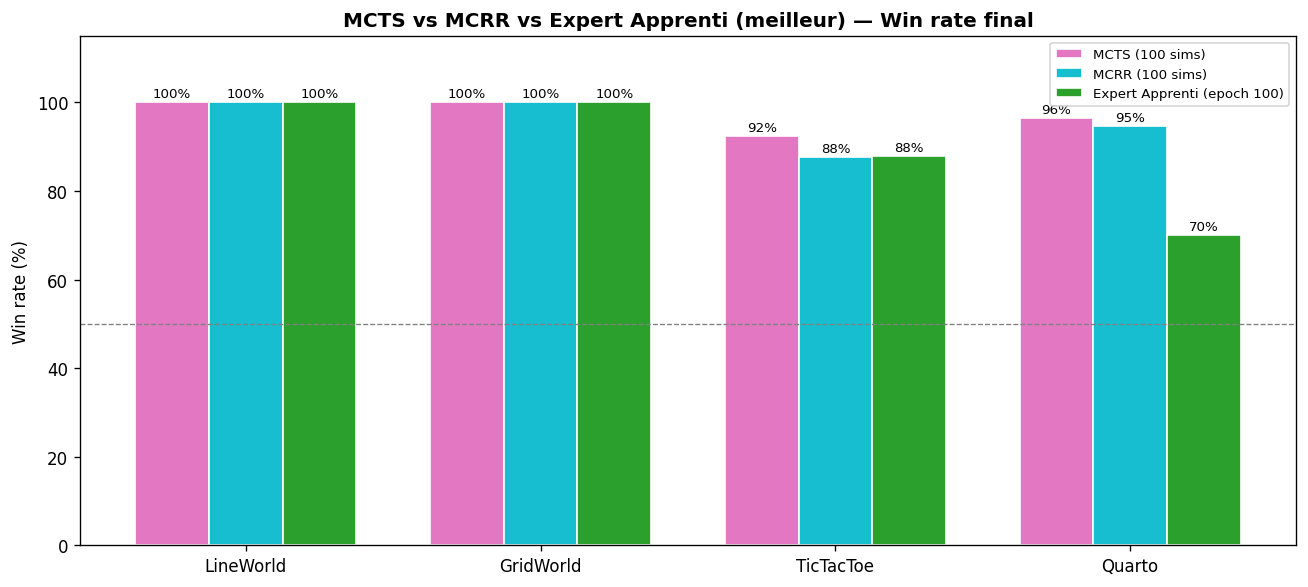

In [50]:
# ── CONFIG ───────────────────────────────────────────────────────────────────

EP_DATASET = 10_000
SIM        = 100
AGENT_TAG  = f"expert_apprenti_ep{EP_DATASET}_sim{SIM}"
WINDOW     = 50

ENVS_LABEL = {
    "LineWorldEnv": "LineWorld",
    "GridWorldEnv": "GridWorld",
    "TicTacToeEnv": "TicTacToe",
    "QuartoEnv":    "Quarto",
}

EA_EPOCHS = [100, 500, 1_000]

ALGO_COLORS = {
    "mcts": "#e377c2",
    "mcrr": "#17becf",
    "best_ea": "#2ca02c",
}
ALGO_LABELS = {
    "mcts":    "MCTS (100 sims)",
    "mcrr":    "MCRR (100 sims)",
    "best_ea": None,   # rempli dynamiquement par env
}


# ── PATH BUILDERS ────────────────────────────────────────────────────────────

def path_mcts(env_name, seed=42):
    return os.path.join(
        settings.training_logs_dir,
        "mcts", env_name, f"seed_{seed}", "eval",
        "mcts_sim100.json",
    )

def path_mcrr(env_name, seed=42):
    return os.path.join(
        settings.training_logs_dir,
        "mcrr", env_name, f"seed_{seed}", "eval",
        "mcrr_sim100.json",
    )

def path_ea(env_name, epoch_ckpt, seed=42):
    return os.path.join(
        settings.training_logs_dir,
        "expert_apprenti", env_name, f"seed_{seed}", "eval",
        f"{AGENT_TAG}_epoch{epoch_ckpt}.json",
    )


# ── SÉLECTION DU MEILLEUR EPOCH EA ───────────────────────────────────────────

def best_ea_epoch(env_name, seed=42):
    """Retourne l'epoch avec le meilleur win_rate pour cet env."""
    best_epoch, best_wr = None, -1
    for epoch in EA_EPOCHS:
        data = load_json(path_ea(env_name, epoch, seed))
        if data is None:
            continue
        wr = data["summary"]["win_rate"]
        if wr > best_wr:
            best_wr    = wr
            best_epoch = epoch
    return best_epoch, best_wr


# ── LOADER UNIFIÉ ─────────────────────────────────────────────────────────────

def load_all_series(env_name, seed=42):
    best_epoch, _ = best_ea_epoch(env_name, seed)

    paths = {
        "mcts":    path_mcts(env_name, seed),
        "mcrr":    path_mcrr(env_name, seed),
        "best_ea": path_ea(env_name, best_epoch, seed) if best_epoch else None,
    }
    labels = {
        "mcts":    "MCTS (100 sims)",
        "mcrr":    "MCRR (100 sims)",
        "best_ea": f"Expert Apprenti (epoch {best_epoch})" if best_epoch else "Expert Apprenti",
    }
    out = {}
    for key, path in paths.items():
        if path is None:
            out[key] = None
            continue
        data = load_json(path)
        if data is None:
            out[key] = None
            continue
        eps     = data["episodes"]
        rewards = np.array([ep["reward"]           for ep in eps])
        times   = np.array([ep["time_per_move_ms"]  for ep in eps])
        steps   = np.array([ep["n_steps"]           for ep in eps])
        out[key] = (rewards, times, steps, data["summary"], labels[key])
    return out


def roll(arr, metric_type, window):
    out = np.zeros(len(arr))
    for i in range(len(arr)):
        chunk = arr[max(0, i - window + 1):i + 1]
        out[i] = np.mean(chunk == 1) * 100 if metric_type == "winrate" else np.mean(chunk)
    return out


# ── PLOT HELPER ───────────────────────────────────────────────────────────────

def plot_metric_grid(metric_type, ylabel, title_suffix, field_idx):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(
        f"MCTS / MCRR / Expert Apprenti (meilleur) — {title_suffix}",
        fontweight="bold", fontsize=13, y=1.01
    )

    for ax, (env_name, env_label) in zip(axes.flatten(), ENVS_LABEL.items()):
        series = load_all_series(env_name)

        for key, data in series.items():
            if data is None:
                continue
            arr, label = data[field_idx], data[4]
            curve = roll(arr, metric_type, WINDOW)
            ax.plot(curve, label=label,
                    color=ALGO_COLORS[key], linewidth=2)

        if metric_type == "winrate":
            ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
            ax.set_ylim(0, 105)
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))

        ax.set_title(env_label, fontweight="bold")
        ax.set_xlabel(f"Épisode d'éval (fenêtre {WINDOW})")
        ax.set_ylabel(ylabel)
        ax.legend(loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.show()


# ── 1. Win rate ───────────────────────────────────────────────────────────────
plot_metric_grid("winrate", "Win rate (%)",     "Win rate",      field_idx=0)

# ── 2. Time / move ────────────────────────────────────────────────────────────
plot_metric_grid("time",    "Time / move (ms)", "Time per move", field_idx=1)

# ── 3. Steps ──────────────────────────────────────────────────────────────────
plot_metric_grid("steps",   "Nombre de pas",    "Steps",         field_idx=2)


# ── 4. Tableau synthèse ───────────────────────────────────────────────────────

rows = []
for env_name, env_label in ENVS_LABEL.items():
    series = load_all_series(env_name)
    row = {"Env": env_label}
    for key in ["mcts", "mcrr", "best_ea"]:
        data = series.get(key)
        if data:
            s, label = data[3], data[4]
            row[f"{label} WR"]    = f"{s['win_rate']*100:.1f}%"
            row[f"{label} ms"]    = f"{s['mean_time_per_move_ms']:.2f}"
            row[f"{label} steps"] = f"{s['mean_steps']:.1f}"
        else:
            row[f"{'MCTS' if key=='mcts' else 'MCRR' if key=='mcrr' else 'EA'} WR"]    = "—"
            row[f"{'MCTS' if key=='mcts' else 'MCRR' if key=='mcrr' else 'EA'} ms"]    = "—"
            row[f"{'MCTS' if key=='mcts' else 'MCRR' if key=='mcrr' else 'EA'} steps"] = "—"
    rows.append(row)

df_all = pd.DataFrame(rows).set_index("Env")
display(df_all.style.set_caption(
    "Synthèse MCTS / MCRR / Expert Apprenti (meilleur epoch) — WR / Time / Steps"
))


# ── 5. Bar chart win rate ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 5))
x      = np.arange(len(ENVS_LABEL))
width  = 0.25
offsets = [-width, 0, width]

for offset, key in zip(offsets, ["mcts", "mcrr", "best_ea"]):
    win_rates = []
    labels_by_env = []
    for env_name in ENVS_LABEL:
        data = load_all_series(env_name).get(key)
        wr    = data[3]["win_rate"] * 100 if data else 0
        label = data[4] if data else key
        win_rates.append(wr)
        labels_by_env.append(label)

    # label de la légende = celui du premier env trouvé
    legend_label = labels_by_env[0]
    bars = ax.bar(x + offset, win_rates, width,
                  label=legend_label,
                  color=ALGO_COLORS[key],
                  edgecolor="white")
    for bar, val in zip(bars, win_rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=8)

ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(list(ENVS_LABEL.values()))
ax.set_ylim(0, 115)
ax.set_ylabel("Win rate (%)")
ax.set_title(
    "MCTS vs MCRR vs Expert Apprenti (meilleur) — Win rate final",
    fontweight="bold"
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

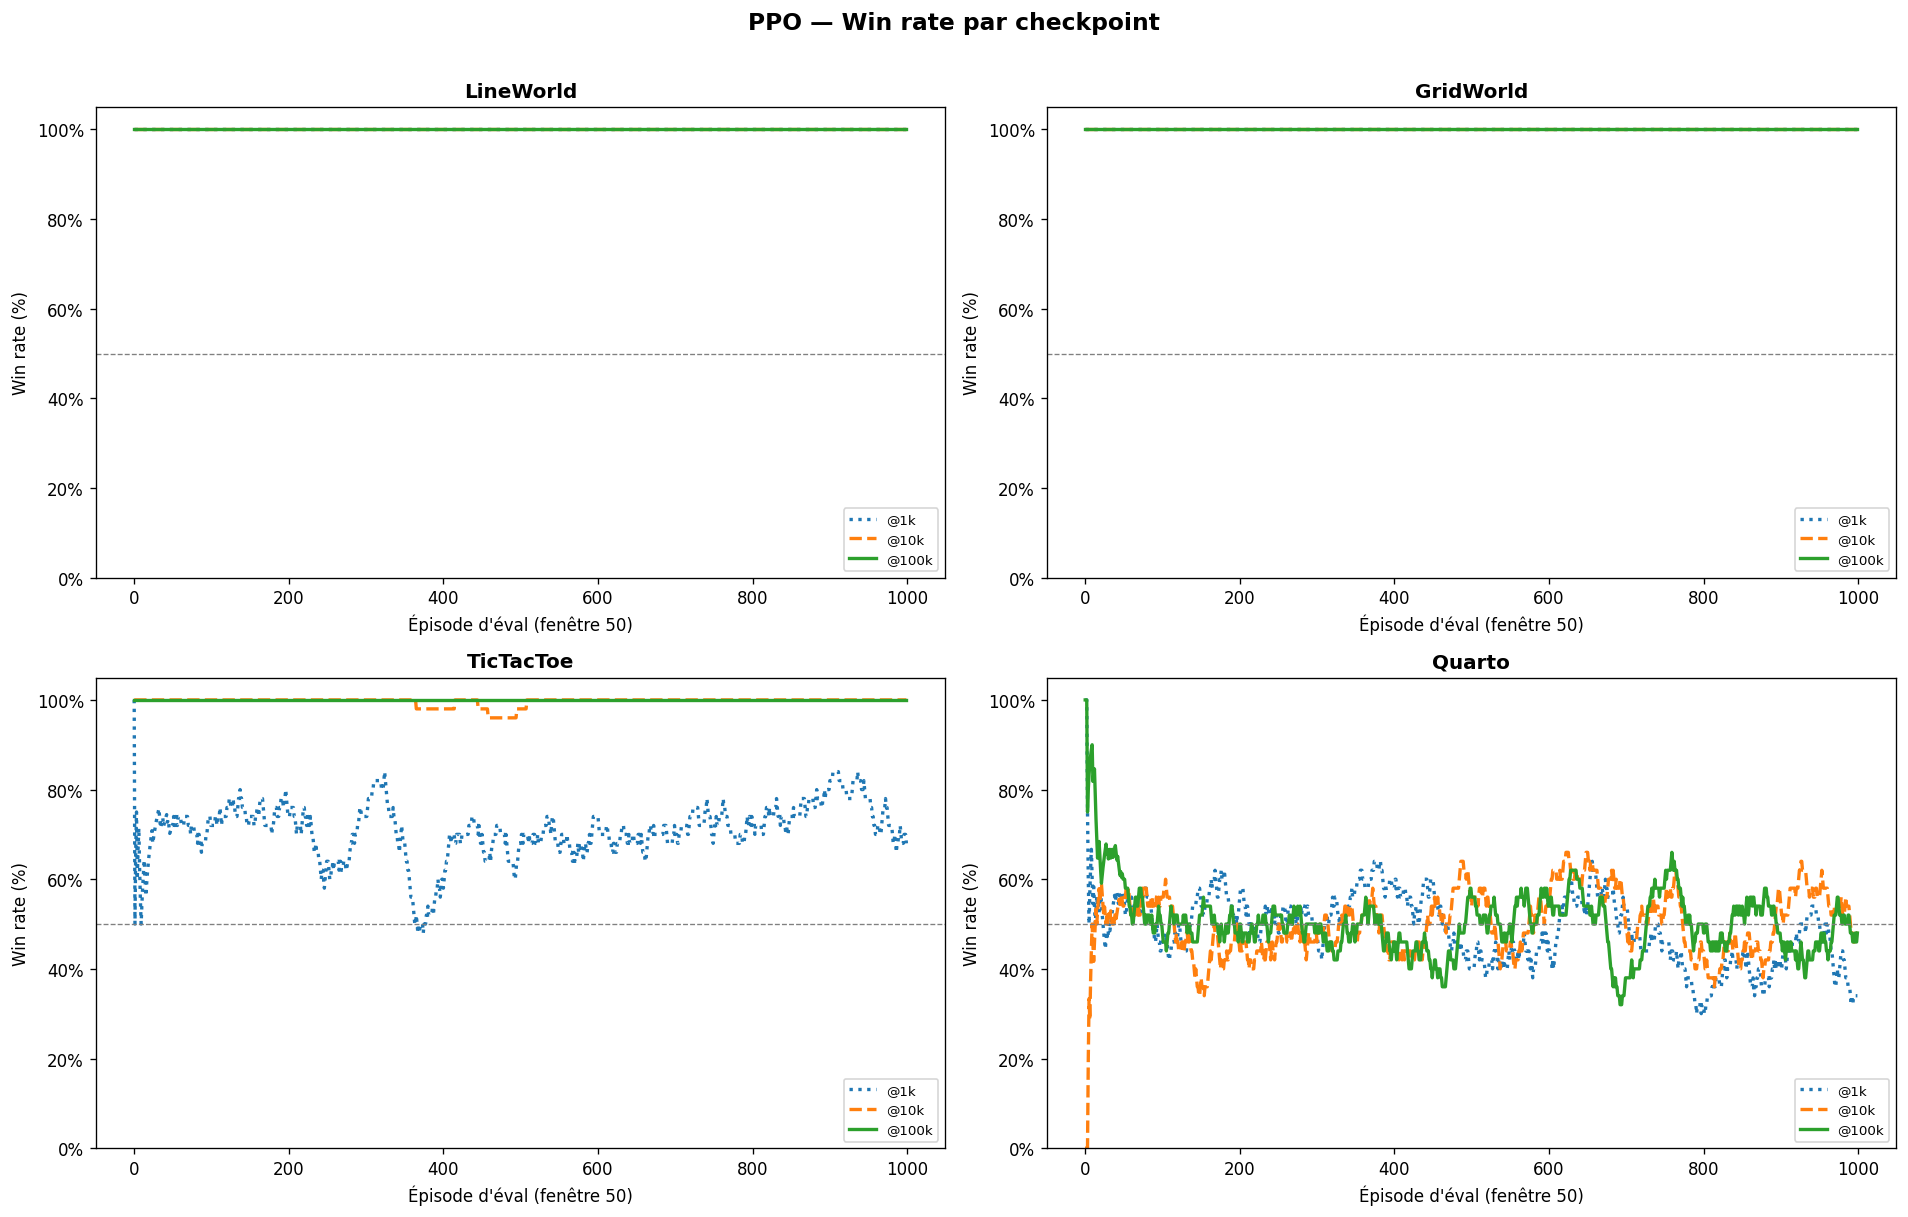

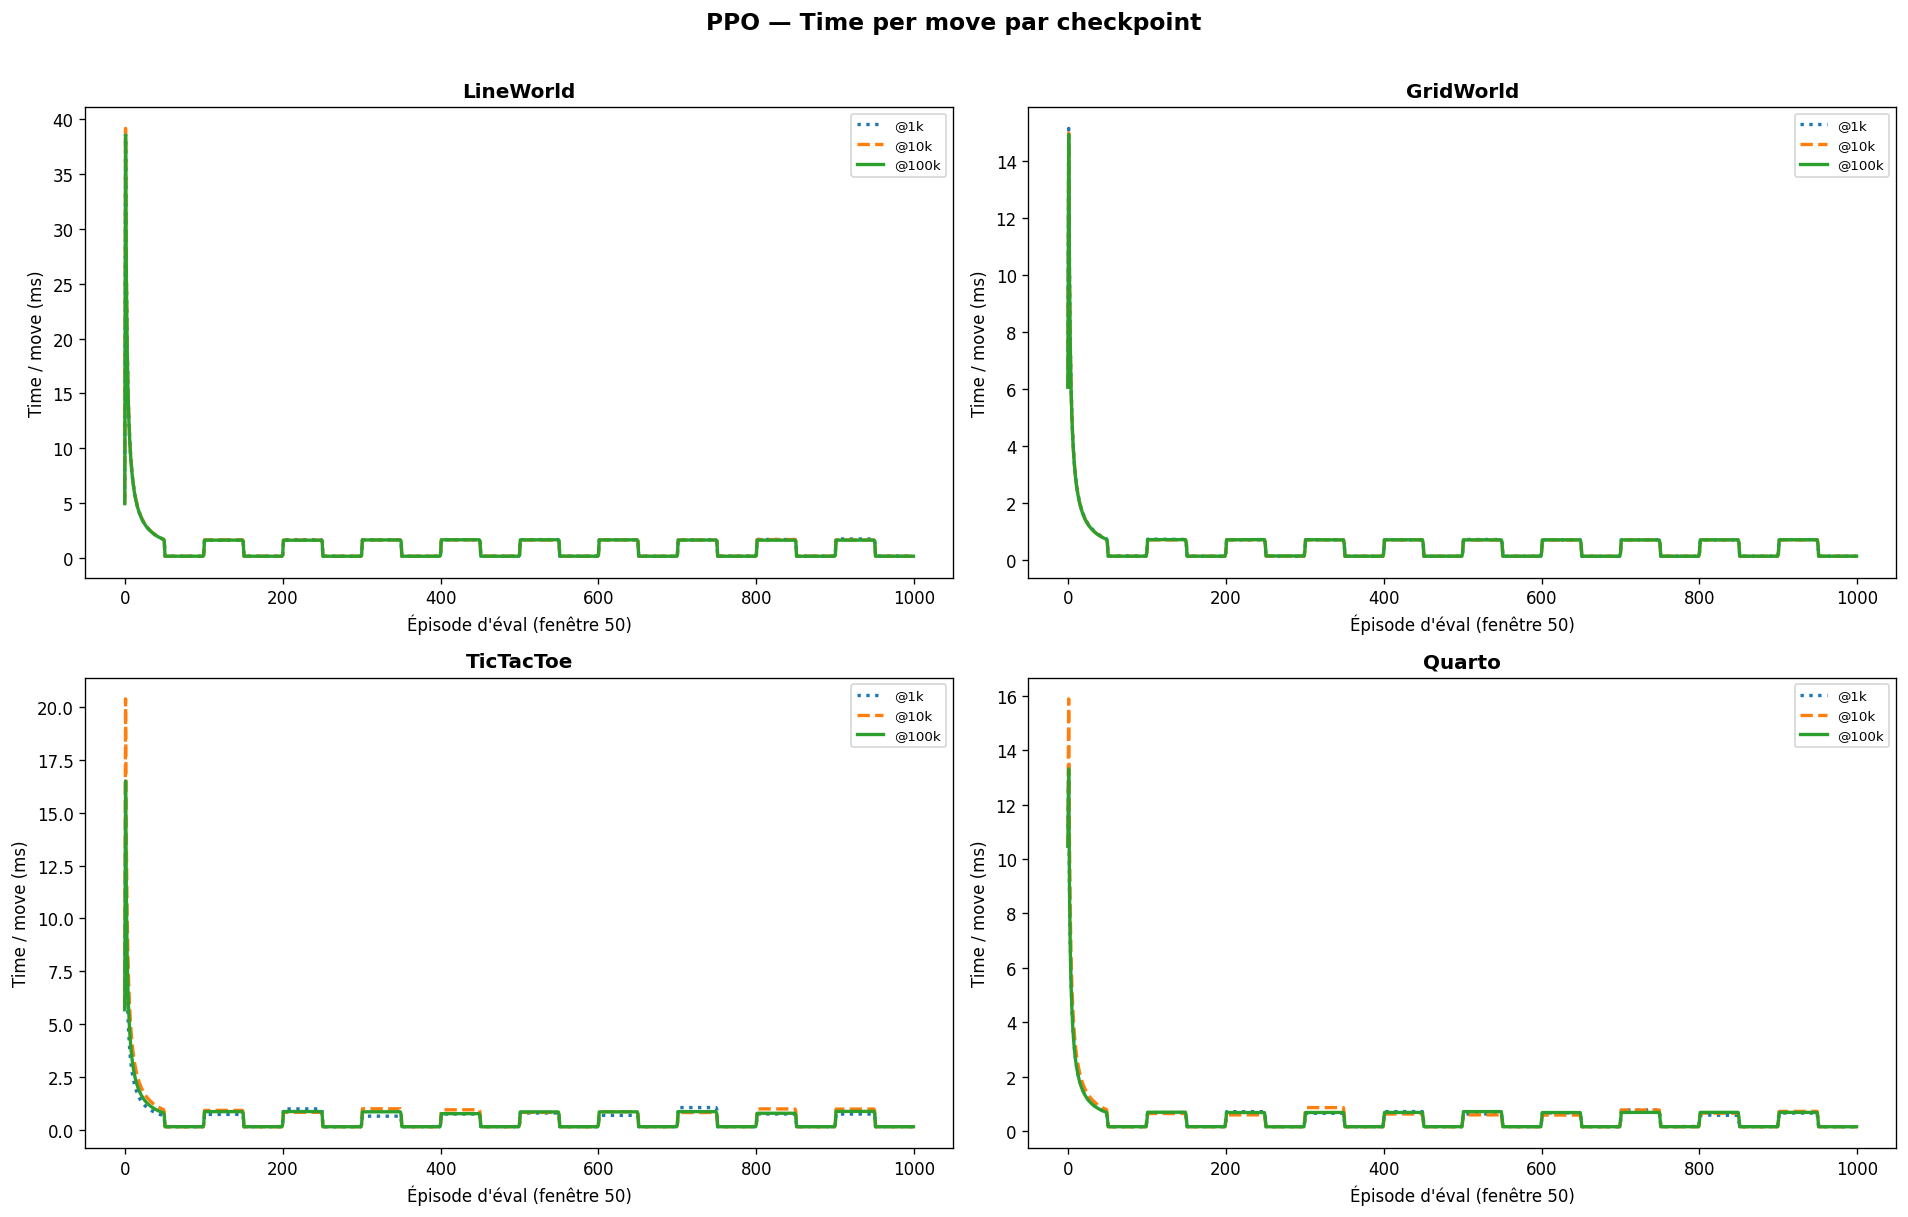

,LineWorld WR,LineWorld ms,LineWorld steps,GridWorld WR,GridWorld ms,GridWorld steps,TicTacToe WR,TicTacToe ms,TicTacToe steps,Quarto WR,Quarto ms,Quarto steps
Checkpoint,,,,,,,,,,,,
1k,100.0%,0.90,2.0,100.0%,0.43,8.0,70.8%,0.48,7.5,48.3%,0.42,25.0
10k,100.0%,0.89,2.0,100.0%,0.42,8.0,99.7%,0.54,5.6,50.2%,0.42,24.2
100k,100.0%,0.89,2.0,100.0%,0.43,8.0,100.0%,0.51,6.5,49.8%,0.42,20.3


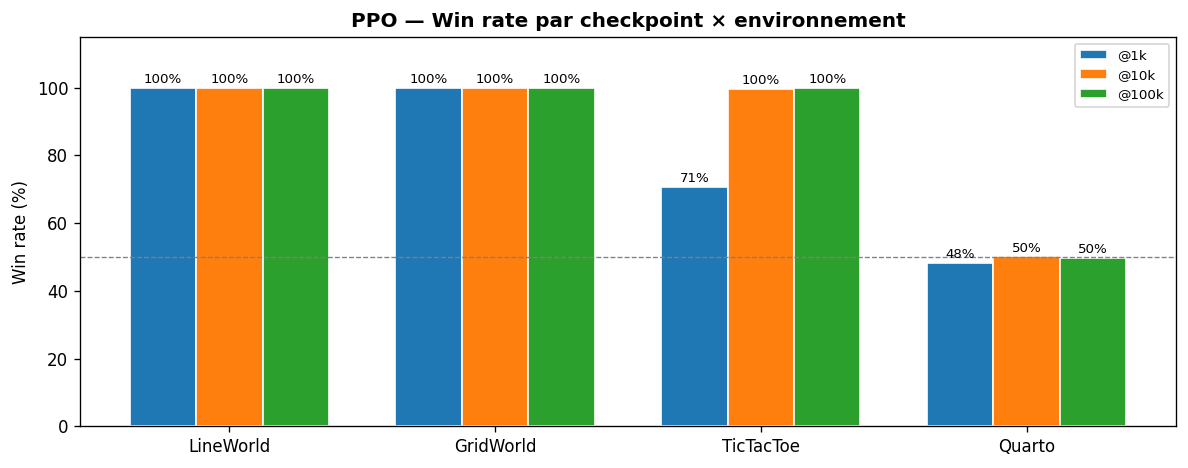

In [51]:
# ── CONFIG PPO ───────────────────────────────────────────────────────────────

PPO_TAG        = "ppo_clip=0.2_epochs=4_rollout=16"
CHECKPOINTS    = [1_000, 10_000, 100_000]
CKPT_LABELS    = {1_000: "1k", 10_000: "10k", 100_000: "100k"}
WINDOW         = 50

ENVS_LABEL = {
    "LineWorldEnv": "LineWorld",
    "GridWorldEnv": "GridWorld",
    "TicTacToeEnv": "TicTacToe",
    "QuartoEnv":    "Quarto",
}

COLORS_PPO = {
    1_000:   "#1f77b4",
    10_000:  "#ff7f0e",
    100_000: "#2ca02c",
}
LINESTYLES_PPO = {1_000: ":", 10_000: "--", 100_000: "-"}


def path_ppo(env_name, checkpoint, seed=42):
    return os.path.join(
        settings.training_logs_dir,
        "ppo", env_name, f"seed_{seed}", "eval",
        f"{PPO_TAG}_{checkpoint}.json",
    )


def load_ppo(env_name, checkpoint, seed=42):
    data = load_json(path_ppo(env_name, checkpoint, seed))
    if data is None:
        return None
    eps     = data["episodes"]
    rewards = np.array([ep["reward"]           for ep in eps])
    times   = np.array([ep["time_per_move_ms"]  for ep in eps])
    steps   = np.array([ep["n_steps"]           for ep in eps])
    return rewards, times, steps, data["summary"]


# ── 1. Win rate — grille 2×2, 1 courbe par checkpoint ────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("PPO — Win rate par checkpoint", fontweight="bold", fontsize=14, y=1.01)

for ax, (env_name, env_label) in zip(axes.flatten(), ENVS_LABEL.items()):
    for ckpt in CHECKPOINTS:
        result = load_ppo(env_name, ckpt)
        if result is None:
            continue
        rewards = result[0]
        curve   = roll(rewards, "winrate", WINDOW)
        ax.plot(curve,
                label=f"@{CKPT_LABELS[ckpt]}",
                color=COLORS_PPO[ckpt],
                linestyle=LINESTYLES_PPO[ckpt],
                linewidth=2)

    ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
    ax.set_ylim(0, 105)
    ax.set_title(env_label, fontweight="bold")
    ax.set_xlabel(f"Épisode d'éval (fenêtre {WINDOW})")
    ax.set_ylabel("Win rate (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()


# ── 2. Time/move — grille 2×2 ────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("PPO — Time per move par checkpoint", fontweight="bold", fontsize=14, y=1.01)

for ax, (env_name, env_label) in zip(axes.flatten(), ENVS_LABEL.items()):
    for ckpt in CHECKPOINTS:
        result = load_ppo(env_name, ckpt)
        if result is None:
            continue
        times = result[1]
        curve = roll(times, "time", WINDOW)
        ax.plot(curve,
                label=f"@{CKPT_LABELS[ckpt]}",
                color=COLORS_PPO[ckpt],
                linestyle=LINESTYLES_PPO[ckpt],
                linewidth=2)

    ax.set_title(env_label, fontweight="bold")
    ax.set_xlabel(f"Épisode d'éval (fenêtre {WINDOW})")
    ax.set_ylabel("Time / move (ms)")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()


# ── 3. Tableau synthèse ───────────────────────────────────────────────────────

rows = []
for ckpt in CHECKPOINTS:
    row = {"Checkpoint": CKPT_LABELS[ckpt]}
    for env_name, env_label in ENVS_LABEL.items():
        result = load_ppo(env_name, ckpt)
        if result:
            s = result[3]
            row[f"{env_label} WR"]    = f"{s['win_rate']*100:.1f}%"
            row[f"{env_label} ms"]    = f"{s['mean_time_per_move_ms']:.2f}"
            row[f"{env_label} steps"] = f"{s['mean_steps']:.1f}"
        else:
            row[f"{env_label} WR"]    = "—"
            row[f"{env_label} ms"]    = "—"
            row[f"{env_label} steps"] = "—"
    rows.append(row)

df_ppo = pd.DataFrame(rows).set_index("Checkpoint")
display(df_ppo.style.set_caption(f"PPO ({PPO_TAG}) — Win rate / Time (ms) / Steps"))


# ── 4. Bar chart win rate final (100k) ───────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))
x      = np.arange(len(ENVS_LABEL))
width  = 0.25
offsets = [-width, 0, width]

for offset, ckpt in zip(offsets, CHECKPOINTS):
    win_rates = []
    for env_name in ENVS_LABEL:
        result = load_ppo(env_name, ckpt)
        wr = result[3]["win_rate"] * 100 if result else 0
        win_rates.append(wr)
    bars = ax.bar(x + offset, win_rates, width,
                  label=f"@{CKPT_LABELS[ckpt]}",
                  color=COLORS_PPO[ckpt],
                  edgecolor="white")
    for bar, val in zip(bars, win_rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=8)

ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(list(ENVS_LABEL.values()))
ax.set_ylim(0, 115)
ax.set_ylabel("Win rate (%)")
ax.set_title("PPO — Win rate par checkpoint × environnement", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

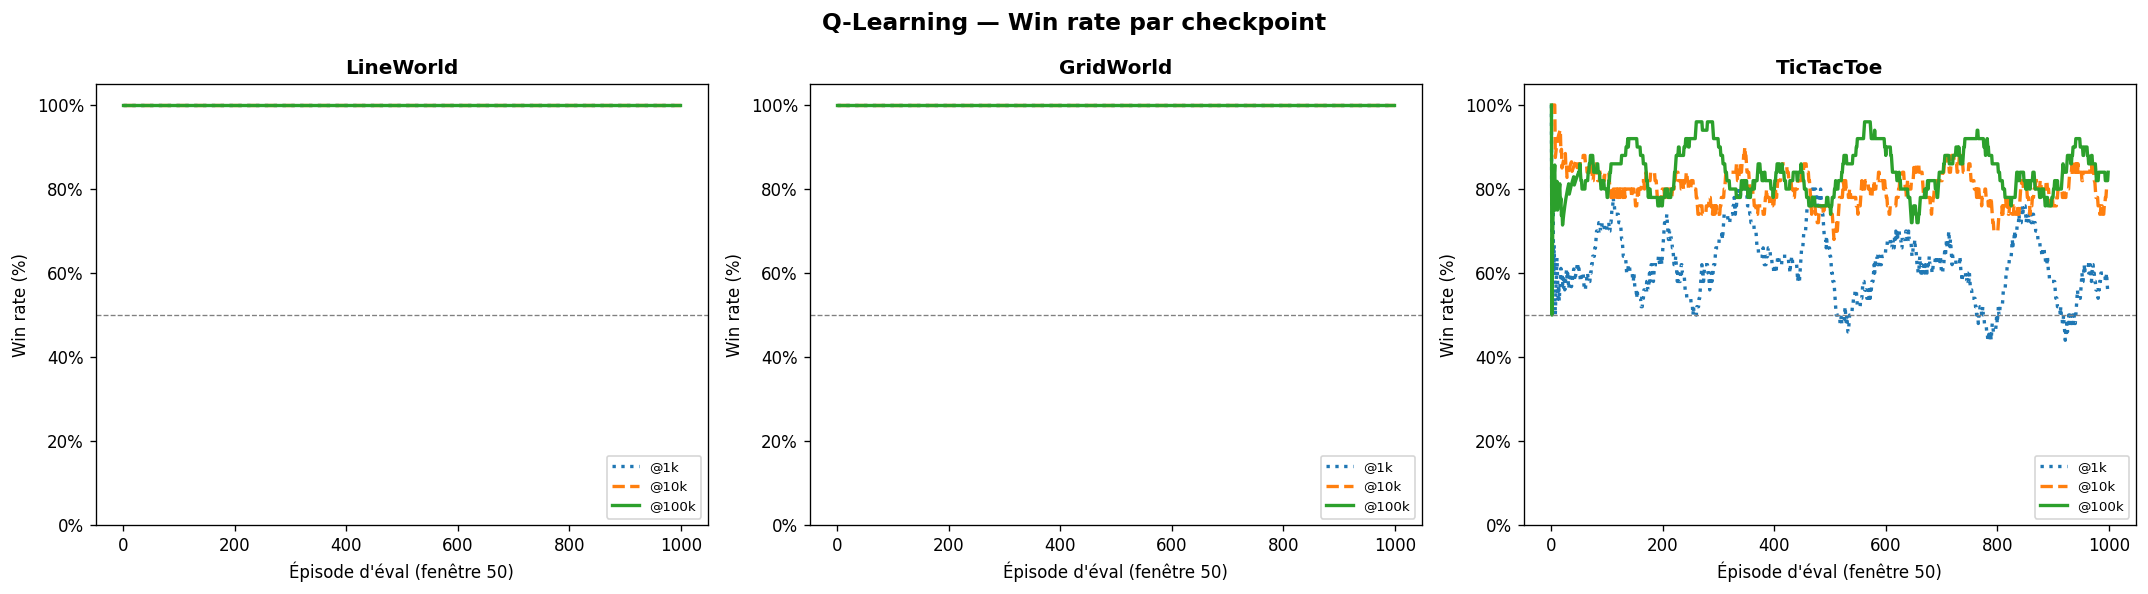

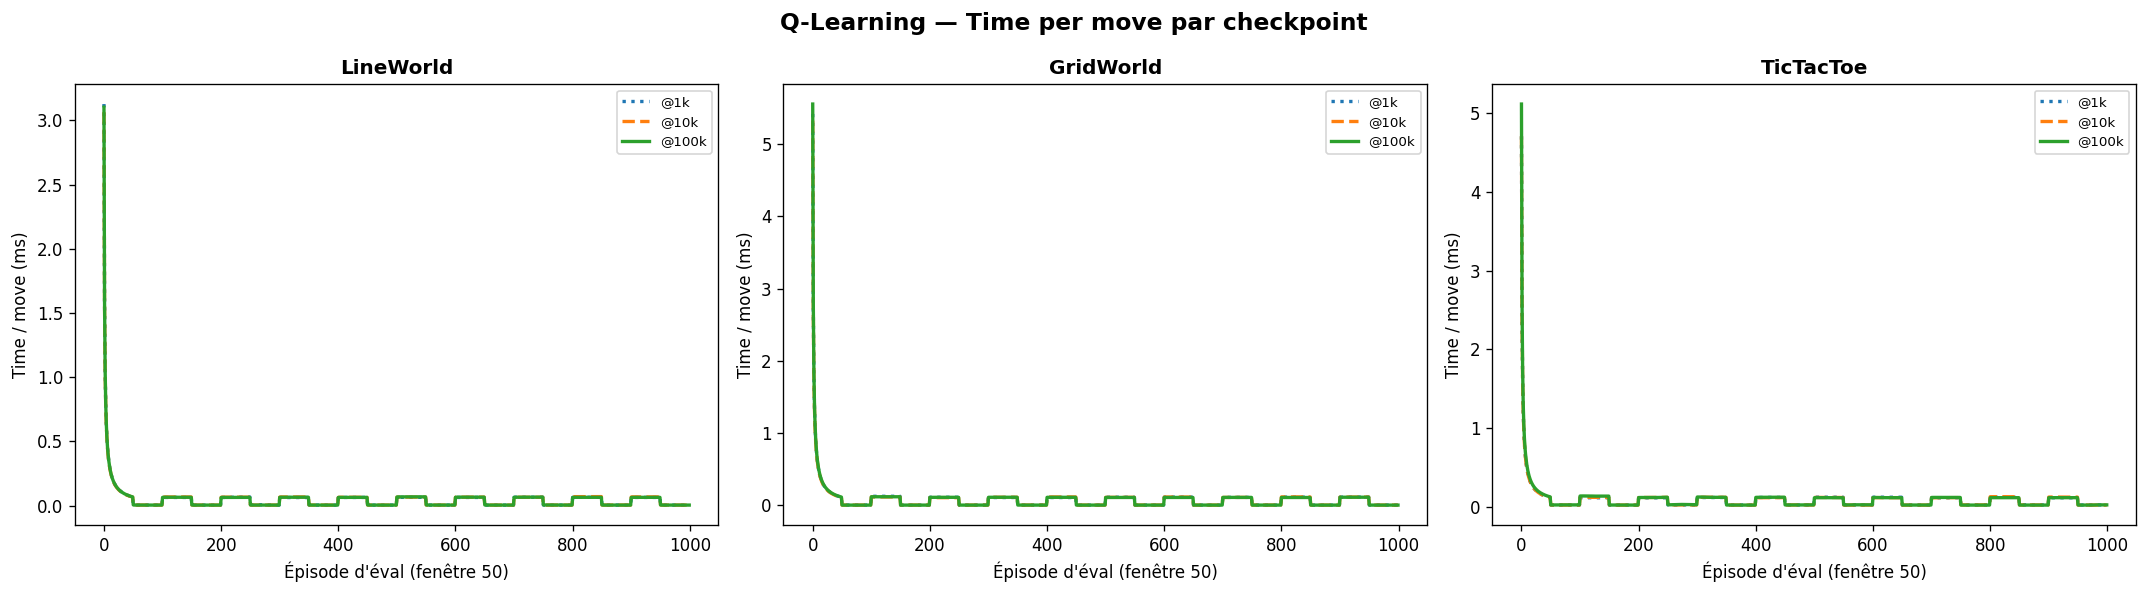

,LineWorld WR,LineWorld ms,LineWorld steps,GridWorld WR,GridWorld ms,GridWorld steps,TicTacToe WR,TicTacToe ms,TicTacToe steps
Checkpoint,,,,,,,,,
1k,100.0%,0.04,2.0,100.0%,0.06,8.0,62.1%,0.07,6.7
10k,100.0%,0.04,2.0,100.0%,0.06,8.0,80.2%,0.07,6.2
100k,100.0%,0.04,2.0,100.0%,0.06,8.0,84.4%,0.07,6.1


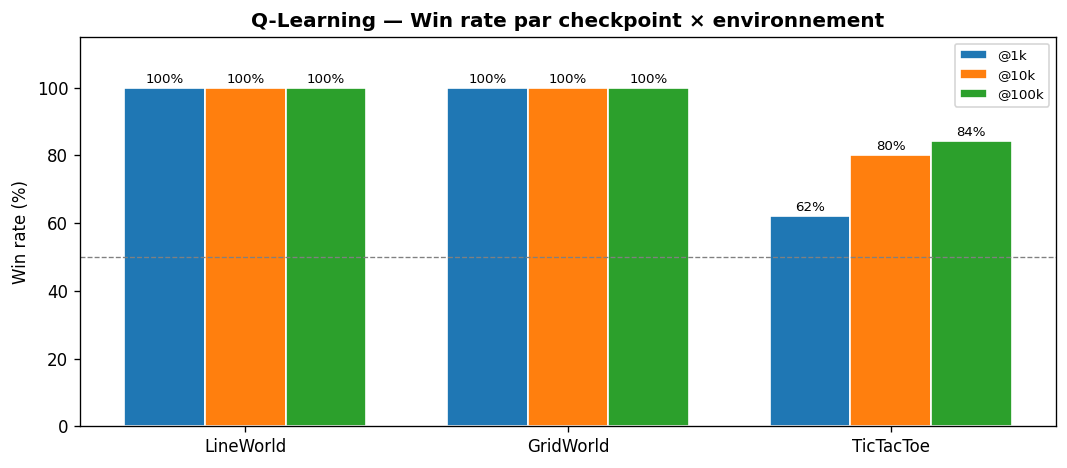

In [52]:
# ── CONFIG Q-LEARNING ────────────────────────────────────────────────────────

CHECKPOINTS_QL = [1_000, 10_000, 100_000]
CKPT_LABELS_QL = {1_000: "1k", 10_000: "10k", 100_000: "100k"}
WINDOW         = 50

# Q-Learning ne supporte pas QuartoEnv
ENVS_LABEL_QL = {
    "LineWorldEnv": "LineWorld",
    "GridWorldEnv": "GridWorld",
    "TicTacToeEnv": "TicTacToe",
}

COLORS_QL = {
    1_000:   "#1f77b4",
    10_000:  "#ff7f0e",
    100_000: "#2ca02c",
}
LINESTYLES_QL = {1_000: ":", 10_000: "--", 100_000: "-"}


def path_ql(env_name, checkpoint, seed=42):
    return os.path.join(
        settings.training_logs_dir,
        "q_learning", env_name, f"seed_{seed}", "eval",
        f"q_learning_{checkpoint}.json",
    )


def load_ql(env_name, checkpoint, seed=42):
    data = load_json(path_ql(env_name, checkpoint, seed))
    if data is None:
        return None
    eps      = data["episodes"]
    rewards  = np.array([ep["reward"]           for ep in eps])
    times    = np.array([ep["time_per_move_ms"]  for ep in eps])
    steps    = np.array([ep["n_steps"]           for ep in eps])
    return rewards, times, steps, data["summary"]


# ── 1. Win rate — grille 1×3 (3 envs seulement) ──────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Q-Learning — Win rate par checkpoint", fontweight="bold", fontsize=14)

for ax, (env_name, env_label) in zip(axes, ENVS_LABEL_QL.items()):
    for ckpt in CHECKPOINTS_QL:
        result = load_ql(env_name, ckpt)
        if result is None:
            continue
        curve = roll(result[0], "winrate", WINDOW)
        ax.plot(curve,
                label=f"@{CKPT_LABELS_QL[ckpt]}",
                color=COLORS_QL[ckpt],
                linestyle=LINESTYLES_QL[ckpt],
                linewidth=2)

    ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
    ax.set_ylim(0, 105)
    ax.set_title(env_label, fontweight="bold")
    ax.set_xlabel(f"Épisode d'éval (fenêtre {WINDOW})")
    ax.set_ylabel("Win rate (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()


# ── 2. Time/move — grille 1×3 ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Q-Learning — Time per move par checkpoint", fontweight="bold", fontsize=14)

for ax, (env_name, env_label) in zip(axes, ENVS_LABEL_QL.items()):
    for ckpt in CHECKPOINTS_QL:
        result = load_ql(env_name, ckpt)
        if result is None:
            continue
        curve = roll(result[1], "time", WINDOW)
        ax.plot(curve,
                label=f"@{CKPT_LABELS_QL[ckpt]}",
                color=COLORS_QL[ckpt],
                linestyle=LINESTYLES_QL[ckpt],
                linewidth=2)

    ax.set_title(env_label, fontweight="bold")
    ax.set_xlabel(f"Épisode d'éval (fenêtre {WINDOW})")
    ax.set_ylabel("Time / move (ms)")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()


# ── 3. Tableau synthèse ───────────────────────────────────────────────────────

rows = []
for ckpt in CHECKPOINTS_QL:
    row = {"Checkpoint": CKPT_LABELS_QL[ckpt]}
    for env_name, env_label in ENVS_LABEL_QL.items():
        result = load_ql(env_name, ckpt)
        if result:
            s = result[3]
            row[f"{env_label} WR"]    = f"{s['win_rate']*100:.1f}%"
            row[f"{env_label} ms"]    = f"{s['mean_time_per_move_ms']:.2f}"
            row[f"{env_label} steps"] = f"{s['mean_steps']:.1f}"
        else:
            row[f"{env_label} WR"]    = "—"
            row[f"{env_label} ms"]    = "—"
            row[f"{env_label} steps"] = "—"
    rows.append(row)

df_ql = pd.DataFrame(rows).set_index("Checkpoint")
display(df_ql.style.set_caption("Q-Learning — Win rate / Time (ms) / Steps"))


# ── 4. Bar chart win rate ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4))
x       = np.arange(len(ENVS_LABEL_QL))
width   = 0.25
offsets = [-width, 0, width]

for offset, ckpt in zip(offsets, CHECKPOINTS_QL):
    win_rates = []
    for env_name in ENVS_LABEL_QL:
        result = load_ql(env_name, ckpt)
        wr = result[3]["win_rate"] * 100 if result else 0
        win_rates.append(wr)
    bars = ax.bar(x + offset, win_rates, width,
                  label=f"@{CKPT_LABELS_QL[ckpt]}",
                  color=COLORS_QL[ckpt],
                  edgecolor="white")
    for bar, val in zip(bars, win_rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=8)

ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(list(ENVS_LABEL_QL.values()))
ax.set_ylim(0, 115)
ax.set_ylabel("Win rate (%)")
ax.set_title("Q-Learning — Win rate par checkpoint × environnement", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [53]:
# ── redéfinition locale de _p pour cette cellule ─────────────────────────────
def _p(algo, name, env):
    return os.path.join(
        settings.training_logs_dir,
        algo, env, f"seed_42", "eval",
        f"{name}.json"
    )

def path_ea(env_name, epoch, seed=42):
    tag = "expert_apprenti_ep10000_sim100"
    return os.path.join(
        settings.training_logs_dir,
        "expert_apprenti", env_name, f"seed_{seed}", "eval",
        f"{tag}_epoch{epoch}.json"
    )

def best_ea_epoch(env_name, seed=42):
    best_epoch, best_wr = None, -1
    for epoch in [100, 500, 1_000]:
        data = load_json(path_ea(env_name, epoch, seed))
        if data is None:
            continue
        wr = data["summary"]["win_rate"]
        if wr > best_wr:
            best_wr, best_epoch = wr, epoch
    return best_epoch, best_wr

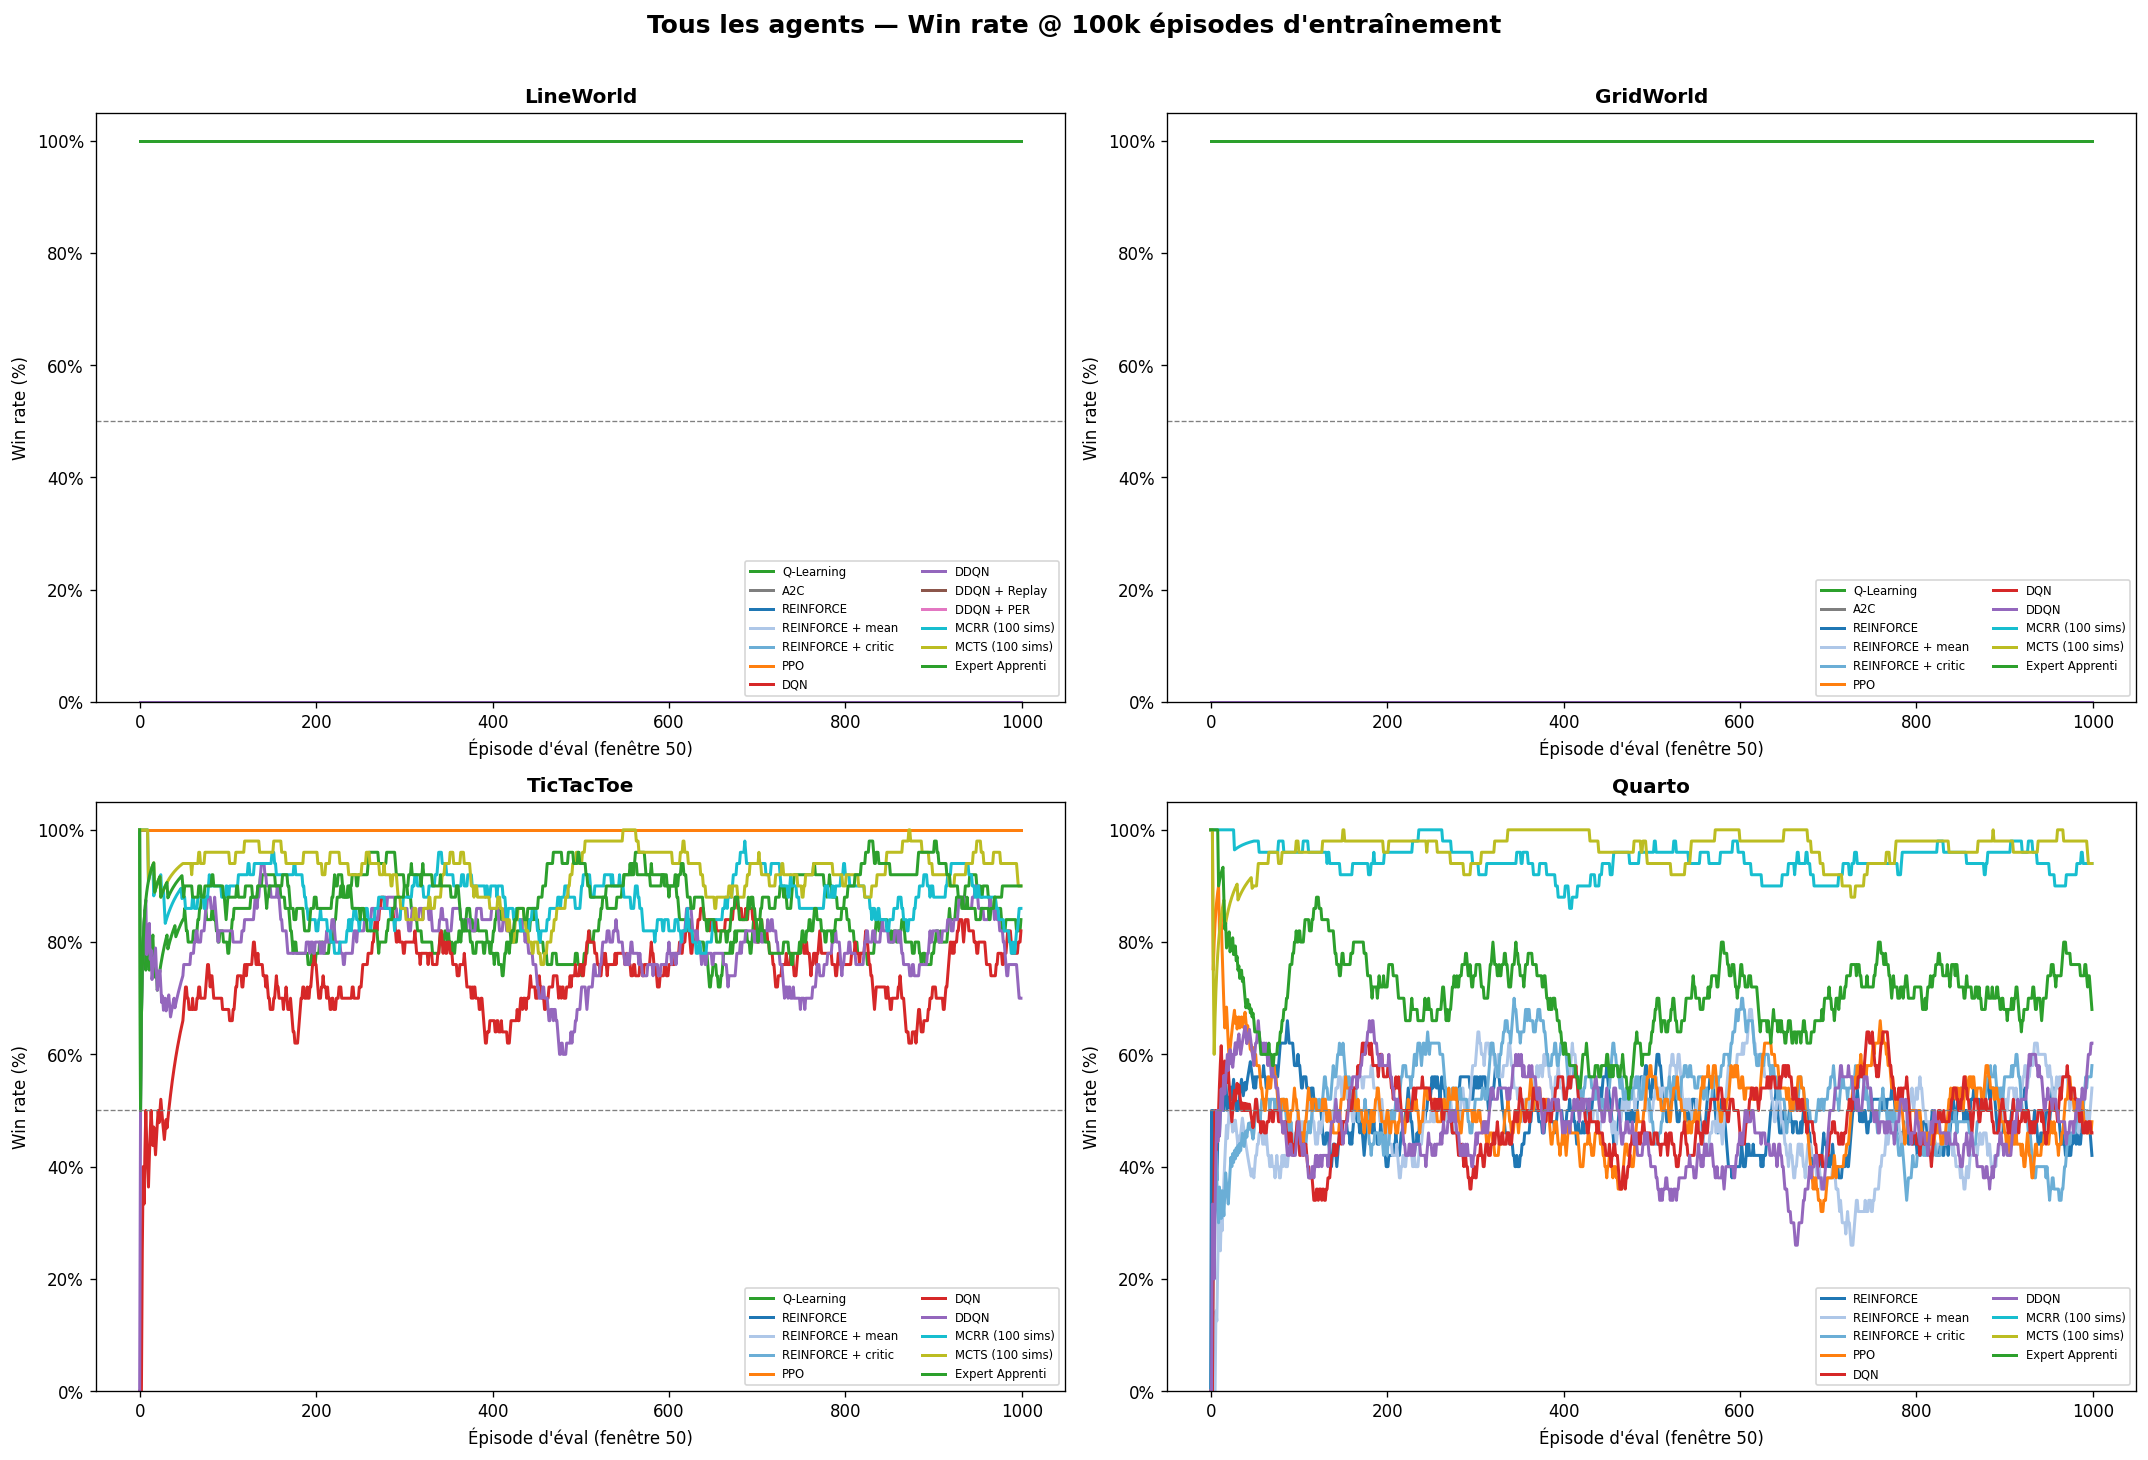

,LineWorld,GridWorld,TicTacToe,Quarto
Agent,,,,
Q-Learning,100.0%,100.0%,84.4%,⏳
A2C,100.0%,100.0%,⏳,⏳
REINFORCE,100.0%,100.0%,100.0%,48.8%
REINFORCE + mean,100.0%,100.0%,100.0%,49.0%
REINFORCE + critic,100.0%,100.0%,100.0%,52.6%
PPO,100.0%,100.0%,100.0%,49.8%
DQN,100.0%,0.0%,74.7%,48.6%
DDQN,0.0%,0.0%,79.3%,48.1%
DDQN + Replay,100.0%,⏳,⏳,⏳


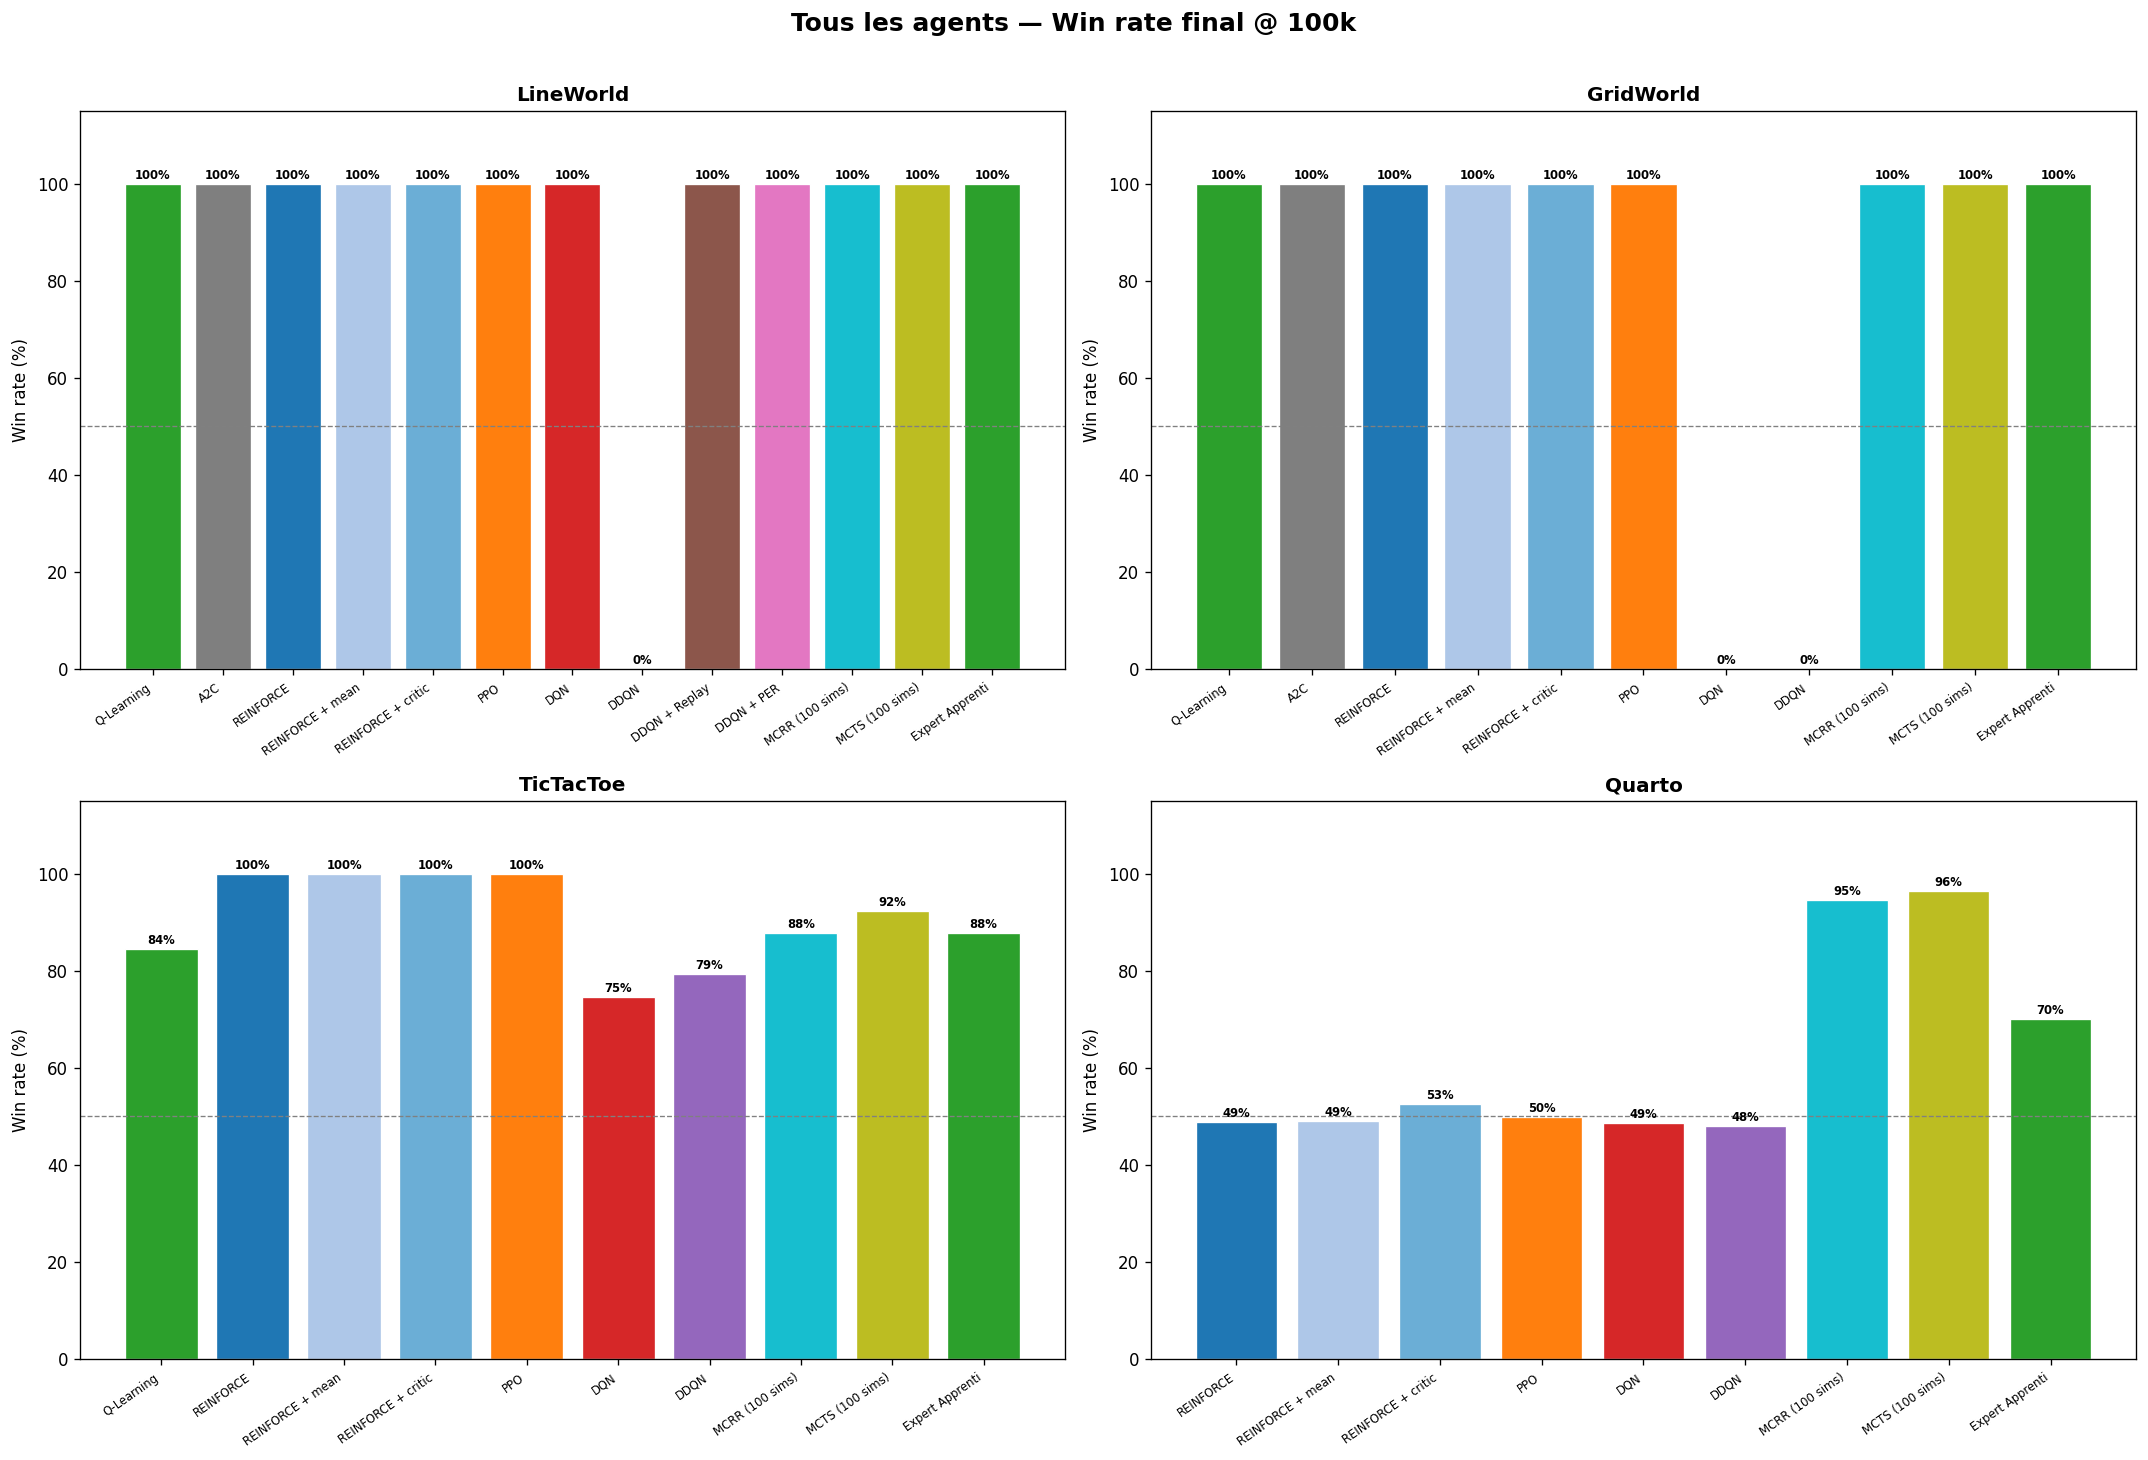

In [57]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown
from deeprl_5iabd.config import settings

SEED   = 42
WINDOW = 50

ENVS_LABEL = {
    "LineWorldEnv": "LineWorld",
    "GridWorldEnv": "GridWorld",
    "TicTacToeEnv": "TicTacToe",
    "QuartoEnv":    "Quarto",
}

# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

def load_json(path):
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

def roll(arr, metric_type, window):
    out = np.zeros(len(arr))
    for i in range(len(arr)):
        chunk = arr[max(0, i - window + 1):i + 1]
        out[i] = np.mean(chunk == 1) * 100 if metric_type == "winrate" else np.mean(chunk)
    return out

def _p(algo, name, env, seed=SEED):
    """Path standard : training_logs/<algo>/<env>/seed_<seed>/eval/<name>.json"""
    return os.path.join(
        settings.training_logs_dir,
        algo, env, f"seed_{seed}", "eval",
        f"{name}.json"
    )

def path_ea(env_name, epoch, seed=SEED):
    tag = "expert_apprenti_ep10000_sim100"
    return _p("expert_apprenti", f"{tag}_epoch{epoch}", env_name, seed)

def best_ea_epoch(env_name, seed=SEED):
    best_epoch, best_wr = None, -1
    for epoch in [100, 500, 1_000]:
        data = load_json(path_ea(env_name, epoch, seed))
        if data is None:
            continue
        wr = data["summary"]["win_rate"]
        if wr > best_wr:
            best_wr, best_epoch = wr, epoch
    return best_epoch, best_wr


# ─────────────────────────────────────────────
# DÉFINITION EXACTE DES AGENTS
# basée sur l'arborescence réelle
# ─────────────────────────────────────────────

ALL_AGENTS = [
    # label, color, path_fn, envs_disponibles (None = tous les 4)
    (
        "Q-Learning", "#2ca02c",
        lambda env: _p("q_learning", "q_learning_100000", env),
        {"LineWorldEnv", "GridWorldEnv", "TicTacToeEnv"},
    ),
    (
        "A2C", "#7f7f7f",
        lambda env: _p("a2c", "a2c_lam=0.95_ent=0.01_100000", env),
        {"LineWorldEnv", "GridWorldEnv"},
    ),
    (
        "REINFORCE", "#1f77b4",
        lambda env: _p("reinforce", "reinforce_no_baseline_100000", env),
        None,  # 4 envs
    ),
    (
        "REINFORCE + mean", "#aec7e8",
        lambda env: _p("reinforce", "reinforce_mean_baseline_100000", env),
        None,
    ),
    (
        "REINFORCE + critic", "#6baed6",
        lambda env: _p("reinforce", "reinforce_critic_baseline_100000", env),
        None,
    ),
    (
        "PPO", "#ff7f0e",
        lambda env: _p("ppo", "ppo_clip=0.2_epochs=4_rollout=16_100000", env),
        None,
    ),
    (
        "DQN", "#d62728",
        lambda env: _p("dqn", "dqn_100000", env),
        None,
    ),
    (
        "DDQN", "#9467bd",
        lambda env: _p("ddqn", "ddqn_100000", env),
        None,
    ),
    (
        "DDQN + Replay", "#8c564b",
        lambda env: _p("ddqn_replay", "ddqn_replay_100000", env),
        {"LineWorldEnv"},
    ),
    (
        "DDQN + PER", "#e377c2",
        lambda env: _p("ddqn_per", "ddqn_per_100000", env),
        {"LineWorldEnv"},
    ),
    (
        "MCRR (100 sims)", "#17becf",
        lambda env: _p("mcrr", "mcrr_sim100", env),
        None,
    ),
    (
        "MCTS (100 sims)", "#bcbd22",
        lambda env: _p("mcts", "mcts_sim100", env),
        None,
    ),
    (
        "Expert Apprenti", "#2ca02c",
        lambda env: path_ea(env, best_ea_epoch(env)[0]) if best_ea_epoch(env)[0] else None,
        None,
    ),
]

def is_available(label, env_name, envs_dispo):
    """True si l'agent a des données pour cet env."""
    if envs_dispo is None:
        return True
    return env_name in envs_dispo

def load_rewards(label, path_fn, env_name, envs_dispo):
    if not is_available(label, env_name, envs_dispo):
        return None
    path = path_fn(env_name)
    if path is None:
        return None
    data = load_json(path)
    if data is None:
        return None
    return np.array([ep["reward"] for ep in data["episodes"]])

def get_wr(label, path_fn, env_name, envs_dispo):
    if not is_available(label, env_name, envs_dispo):
        return None
    path = path_fn(env_name)
    if path is None:
        return None
    data = load_json(path)
    if data is None:
        return None
    return data["summary"]["win_rate"] * 100


# ─────────────────────────────────────────────
# 1. GRILLE 2×2 — courbes win rate @100k
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    "Tous les agents — Win rate @ 100k épisodes d'entraînement",
    fontweight="bold", fontsize=15, y=1.01
)

for ax, (env_name, env_label) in zip(axes.flatten(), ENVS_LABEL.items()):
    for label, color, path_fn, envs_dispo in ALL_AGENTS:
        rewards = load_rewards(label, path_fn, env_name, envs_dispo)
        if rewards is None:
            continue
        curve = roll(rewards, "winrate", WINDOW)
        ax.plot(curve, label=label, color=color, linewidth=1.8)

    ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
    ax.set_ylim(0, 105)
    ax.set_title(env_label, fontweight="bold", fontsize=12)
    ax.set_xlabel(f"Épisode d'éval (fenêtre {WINDOW})")
    ax.set_ylabel("Win rate (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
    ax.legend(loc="lower right", fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 2. TABLEAU récap win rate
# ─────────────────────────────────────────────

rows = []
for label, color, path_fn, envs_dispo in ALL_AGENTS:
    row = {"Agent": label}
    for env_name, env_label in ENVS_LABEL.items():
        wr = get_wr(label, path_fn, env_name, envs_dispo)
        if wr is None and not is_available(label, env_name, envs_dispo):
            row[env_label] = "⏳"   # pas encore entraîné
        elif wr is None:
            row[env_label] = "❌"   # fichier attendu mais absent
        else:
            row[env_label] = f"{wr:.1f}%"
    rows.append(row)

df = pd.DataFrame(rows).set_index("Agent")
display(df.style.set_caption(
    "Win rate @ 100k  |  ⏳ pas encore entraîné  |  ❌ fichier manquant"
))


# ─────────────────────────────────────────────
# 3. BAR CHART — un subplot par env
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    "Tous les agents — Win rate final @ 100k",
    fontweight="bold", fontsize=15, y=1.01
)

for ax, (env_name, env_label) in zip(axes.flatten(), ENVS_LABEL.items()):
    labels_env, colors_env, win_rates_env = [], [], []

    for label, color, path_fn, envs_dispo in ALL_AGENTS:
        if not is_available(label, env_name, envs_dispo):
            continue
        wr = get_wr(label, path_fn, env_name, envs_dispo)
        if wr is None:
            continue
        labels_env.append(label)
        colors_env.append(color)
        win_rates_env.append(wr)

    x    = np.arange(len(labels_env))
    bars = ax.bar(x, win_rates_env, color=colors_env,
                  edgecolor="white", linewidth=0.8)

    for bar, val in zip(bars, win_rates_env):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.0f}%",
            ha="center", va="bottom", fontsize=7, fontweight="bold"
        )

    ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_env, rotation=35, ha="right", fontsize=7)
    ax.set_ylim(0, 115)
    ax.set_ylabel("Win rate (%)")
    ax.set_title(env_label, fontweight="bold", fontsize=12)

plt.tight_layout()
plt.show()

In [54]:
import os
import json
import numpy as np
from IPython.display import display, Markdown
from deeprl_5iabd.config import settings

SEED = 42

ENVS = {
    "LineWorldEnv": "LineWorld",
    "GridWorldEnv": "GridWorld",
    "TicTacToeEnv": "TicTacToe",
    "QuartoEnv":    "Quarto",
}

# ─────────────────────────────────────────────
# LOADERS GÉNÉRIQUES
# ─────────────────────────────────────────────

def load_json(path):
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

def fmt_wr(v):
    return f"{v*100:.1f}%" if v is not None else "—"

def fmt_ms(v):
    return f"{v:.2f} ms" if v is not None else "—"

def fmt_steps(v):
    return f"{v:.1f}" if v is not None else "—"

def get_summary(path):
    data = load_json(path)
    if data is None:
        return None
    return data.get("summary", None)


# ─────────────────────────────────────────────
# DÉFINITION DE TOUS LES AGENTS
# ─────────────────────────────────────────────

def eval_path(algo, agent_name, env, ckpt, seed=SEED):
    return os.path.join(
        settings.training_logs_dir,
        algo, env, f"seed_{seed}", "eval",
        f"{agent_name}_{ckpt}.json"
    )

def train_path(algo, agent_name, env, ckpt, seed=SEED):
    return os.path.join(
        settings.training_logs_dir,
        algo, env, f"seed_{seed}", "train",
        f"{agent_name}_{ckpt}.json"
    )

def mcts_path(algo, agent_name, env, seed=SEED):
    return os.path.join(
        settings.training_logs_dir,
        algo, env, f"seed_{seed}", "eval",
        f"{agent_name}.json"
    )

def ea_eval_path(env, epoch, seed=SEED):
    tag = f"expert_apprenti_ep10000_sim100"
    return os.path.join(
        settings.training_logs_dir,
        "expert_apprenti", env, f"seed_{seed}", "eval",
        f"{tag}_epoch{epoch}.json"
    )

def ea_train_path(env, seed=SEED):
    tag = f"expert_apprenti_ep10000_sim100"
    return os.path.join(
        settings.training_logs_dir,
        "expert_apprenti", env, f"seed_{seed}", "train",
        f"{tag}_epoch1000.json"
    )


# Agents apprenants : (label, algo_folder, agent_name, checkpoints, path_fn)
LEARNED_AGENTS = [
    ("Q-Learning",               "q_learning",   "q_learning",                              [1_000, 10_000, 100_000], eval_path),
    ("DQN",                      "dqn",           "dqn_no_replay",                           [1_000, 10_000, 100_000], eval_path),
    ("DDQN",                     "ddqn",          "ddqn",                                    [1_000, 10_000, 100_000], eval_path),
    ("DDQN + Replay",            "ddqn_replay",   "ddqn_replay",                             [1_000, 10_000, 100_000], eval_path),
    ("DDQN + PER",               "ddqn_per",      "ddqn_per",                                [1_000, 10_000, 100_000], eval_path),
    ("REINFORCE",                "reinforce",     "reinforce_no_baseline",                   [1_000, 10_000, 100_000], eval_path),
    ("REINFORCE + mean baseline","reinforce",     "reinforce_mean_baseline",                 [1_000, 10_000, 100_000], eval_path),
    ("REINFORCE + critic",       "reinforce",     "reinforce_critic_baseline",               [1_000, 10_000, 100_000], eval_path),
    ("PPO",                      "ppo",           "ppo_clip=0.2_epochs=4_rollout=16",        [1_000, 10_000, 100_000], eval_path),
]

PLANNING_AGENTS = [
    ("MCRR (100 sims)", "mcrr", "mcrr_sim100"),
    ("MCTS (100 sims)", "mcts", "mcts_sim100"),
]

EA_EPOCHS = [100, 500, 1_000]


# ─────────────────────────────────────────────
# HELPER : récupère win_rate / ms / steps
# ─────────────────────────────────────────────

def get_eval_metrics(path):
    s = get_summary(path)
    if s is None:
        return None, None, None
    wr    = s.get("win_rate")
    ms    = s.get("mean_time_per_move_ms")
    steps = s.get("mean_steps")
    return wr, ms, steps

def get_train_metrics(path):
    s = get_summary(path)
    if s is None:
        return None, None
    loss = s.get("mean_policy_loss") or s.get("mean_td_error") or s.get("mean_loss")
    ms   = s.get("mean_time_per_move_ms")
    return loss, ms


# ─────────────────────────────────────────────
# TABLEAU 1 — WIN RATE @ 100k — tous agents × envs
# ─────────────────────────────────────────────

def table_winrate_100k():
    env_keys  = list(ENVS.keys())
    env_labels = list(ENVS.values())
    header = "| Agent | " + " | ".join(env_labels) + " |"
    sep    = "|---|" + "---|" * len(env_labels)
    rows   = [header, sep]

    # Agents apprenants @ 100k
    for label, algo, agent_name, ckpts, pfn in LEARNED_AGENTS:
        cells = []
        for env in env_keys:
            if env == "QuartoEnv" and algo == "q_learning":
                cells.append("N/A")
                continue
            path = pfn(algo, agent_name, env, 100_000)
            wr, _, _ = get_eval_metrics(path)
            cells.append(fmt_wr(wr))
        rows.append(f"| **{label}** | " + " | ".join(cells) + " |")

    # Planning
    for label, algo, agent_name in PLANNING_AGENTS:
        cells = []
        for env in env_keys:
            path = mcts_path(algo, agent_name, env)
            wr, _, _ = get_eval_metrics(path)
            cells.append(fmt_wr(wr))
        rows.append(f"| **{label}** | " + " | ".join(cells) + " |")

    # Expert Apprenti meilleur epoch
    cells = []
    for env in env_keys:
        best_wr, best_ep = None, None
        for ep in EA_EPOCHS:
            path = ea_eval_path(env, ep)
            wr, _, _ = get_eval_metrics(path)
            if wr is not None and (best_wr is None or wr > best_wr):
                best_wr, best_ep = wr, ep
        cells.append(fmt_wr(best_wr) + (f" (ep{best_ep})" if best_ep else ""))
    rows.append(f"| **Expert Apprenti (best)** | " + " | ".join(cells) + " |")

    return "\n".join(rows)


# ─────────────────────────────────────────────
# TABLEAU 2 — WIN RATE PAR CHECKPOINT (1k / 10k / 100k)
# un tableau par env
# ─────────────────────────────────────────────

def table_winrate_by_checkpoint(env_name):
    env_label = ENVS[env_name]
    header = "| Agent | @1k | @10k | @100k |"
    sep    = "|---|---|---|---|"
    rows   = [f"**{env_label}**", header, sep]

    for label, algo, agent_name, ckpts, pfn in LEARNED_AGENTS:
        if env_name == "QuartoEnv" and algo == "q_learning":
            rows.append(f"| **{label}** | N/A | N/A | N/A |")
            continue
        cells = []
        for ckpt in [1_000, 10_000, 100_000]:
            path = pfn(algo, agent_name, env_name, ckpt)
            wr, _, _ = get_eval_metrics(path)
            cells.append(fmt_wr(wr))
        rows.append(f"| **{label}** | " + " | ".join(cells) + " |")

    for label, algo, agent_name in PLANNING_AGENTS:
        path = mcts_path(algo, agent_name, env_name)
        wr, _, _ = get_eval_metrics(path)
        rows.append(f"| **{label}** | — | — | {fmt_wr(wr)} |")

    # EA par epoch
    cells = []
    for ep in EA_EPOCHS:
        path = ea_eval_path(env_name, ep)
        wr, _, _ = get_eval_metrics(path)
        cells.append(fmt_wr(wr))
    # on les affiche sur 3 lignes
    rows.append(f"| **Expert Apprenti ep100** | — | — | {cells[0]} |")
    rows.append(f"| **Expert Apprenti ep500** | — | — | {cells[1]} |")
    rows.append(f"| **Expert Apprenti ep1000** | — | — | {cells[2]} |")

    return "\n".join(rows)


# ─────────────────────────────────────────────
# TABLEAU 3 — TIME / MOVE @ 100k
# ─────────────────────────────────────────────

def table_time_100k():
    env_keys   = list(ENVS.keys())
    env_labels = list(ENVS.values())
    header = "| Agent | " + " | ".join(env_labels) + " |"
    sep    = "|---|" + "---|" * len(env_labels)
    rows   = [header, sep]

    for label, algo, agent_name, ckpts, pfn in LEARNED_AGENTS:
        cells = []
        for env in env_keys:
            if env == "QuartoEnv" and algo == "q_learning":
                cells.append("N/A")
                continue
            path = pfn(algo, agent_name, env, 100_000)
            _, ms, _ = get_eval_metrics(path)
            cells.append(fmt_ms(ms))
        rows.append(f"| **{label}** | " + " | ".join(cells) + " |")

    for label, algo, agent_name in PLANNING_AGENTS:
        cells = []
        for env in env_keys:
            path = mcts_path(algo, agent_name, env)
            _, ms, _ = get_eval_metrics(path)
            cells.append(fmt_ms(ms))
        rows.append(f"| **{label}** | " + " | ".join(cells) + " |")

    # EA meilleur epoch
    cells = []
    for env in env_keys:
        best_ms, best_wr = None, -1
        for ep in EA_EPOCHS:
            path = ea_eval_path(env, ep)
            wr, ms, _ = get_eval_metrics(path)
            if wr is not None and wr > best_wr:
                best_wr, best_ms = wr, ms
        cells.append(fmt_ms(best_ms))
    rows.append(f"| **Expert Apprenti (best)** | " + " | ".join(cells) + " |")

    return "\n".join(rows)


# ─────────────────────────────────────────────
# TABLEAU 4 — MEAN STEPS @ 100k
# ─────────────────────────────────────────────

def table_steps_100k():
    env_keys   = list(ENVS.keys())
    env_labels = list(ENVS.values())
    header = "| Agent | " + " | ".join(env_labels) + " |"
    sep    = "|---|" + "---|" * len(env_labels)
    rows   = [header, sep]

    for label, algo, agent_name, ckpts, pfn in LEARNED_AGENTS:
        cells = []
        for env in env_keys:
            if env == "QuartoEnv" and algo == "q_learning":
                cells.append("N/A")
                continue
            path = pfn(algo, agent_name, env, 100_000)
            _, _, steps = get_eval_metrics(path)
            cells.append(fmt_steps(steps))
        rows.append(f"| **{label}** | " + " | ".join(cells) + " |")

    for label, algo, agent_name in PLANNING_AGENTS:
        cells = []
        for env in env_keys:
            path = mcts_path(algo, agent_name, env)
            _, _, steps = get_eval_metrics(path)
            cells.append(fmt_steps(steps))
        rows.append(f"| **{label}** | " + " | ".join(cells) + " |")

    cells = []
    for env in env_keys:
        best_steps, best_wr = None, -1
        for ep in EA_EPOCHS:
            path = ea_eval_path(env, ep)
            wr, _, steps = get_eval_metrics(path)
            if wr is not None and wr > best_wr:
                best_wr, best_steps = wr, steps
        cells.append(fmt_steps(best_steps))
    rows.append(f"| **Expert Apprenti (best)** | " + " | ".join(cells) + " |")

    return "\n".join(rows)


# ─────────────────────────────────────────────
# TABLEAU 5 — TRAINING : loss finale @ 100k
# ─────────────────────────────────────────────

def table_train_loss():
    env_keys   = list(ENVS.keys())
    env_labels = list(ENVS.values())
    header = "| Agent | " + " | ".join(env_labels) + " |"
    sep    = "|---|" + "---|" * len(env_labels)
    rows   = ["*(agents apprenants uniquement — MCTS/MCRR sans entraînement)*",
              header, sep]

    train_agents = [
        ("Q-Learning",               "q_learning",  "q_learning",                       "q_learning_100000"),
        ("DQN",                      "dqn",          "dqn_no_replay",                    "dqn_no_replay_100000"),
        ("DDQN",                     "ddqn",         "ddqn",                             "ddqn_100000"),
        ("DDQN + Replay",            "ddqn_replay",  "ddqn_replay",                      "ddqn_replay_100000"),
        ("DDQN + PER",               "ddqn_per",     "ddqn_per",                         "ddqn_per_100000"),
        ("REINFORCE",                "reinforce",    "reinforce_no_baseline",            "reinforce_no_baseline_100000"),
        ("REINFORCE + mean baseline","reinforce",    "reinforce_mean_baseline",          "reinforce_mean_baseline_100000"),
        ("REINFORCE + critic",       "reinforce",    "reinforce_critic_baseline",        "reinforce_critic_baseline_100000"),
        ("PPO",                      "ppo",          "ppo_clip=0.2_epochs=4_rollout=16", "ppo_clip=0.2_epochs=4_rollout=16_100000"),
    ]

    for label, algo, _, train_name in train_agents:
        cells = []
        for env in env_keys:
            if env == "QuartoEnv" and algo == "q_learning":
                cells.append("N/A")
                continue
            path = os.path.join(
                settings.training_logs_dir,
                algo, env, f"seed_{SEED}", "train",
                f"{train_name}.json"
            )
            loss, _ = get_train_metrics(path)
            cells.append(f"{loss:.4f}" if loss is not None else "—")
        rows.append(f"| **{label}** | " + " | ".join(cells) + " |")

    # Expert Apprenti loss finale
    cells = []
    for env in env_keys:
        path = ea_train_path(env)
        data = load_json(path)
        if data:
            s = data.get("summary", {})
            loss = s.get("final_loss")
            cells.append(f"{loss:.4f}" if loss else "—")
        else:
            cells.append("—")
    rows.append(f"| **Expert Apprenti** | " + " | ".join(cells) + " |")

    return "\n".join(rows)


# ─────────────────────────────────────────────
# AFFICHAGE + EXPORT MARKDOWN
# ─────────────────────────────────────────────

sections = []

# ── Tableau 1 : Win rate global @ 100k
sections.append("## Tableau 1 — Win rate @ 100k (tous agents × tous environnements)\n")
t1 = table_winrate_100k()
sections.append(t1)
display(Markdown(sections[-2] + "\n" + t1))

# ── Tableau 2 : Win rate par checkpoint, par env
sections.append("\n## Tableau 2 — Win rate par checkpoint\n")
for env in ENVS:
    t2 = table_winrate_by_checkpoint(env)
    sections.append(t2 + "\n")
    display(Markdown(t2))

# ── Tableau 3 : Time/move @ 100k
sections.append("\n## Tableau 3 — Time per move @ 100k (ms)\n")
t3 = table_time_100k()
sections.append(t3)
display(Markdown("## Tableau 3 — Time per move @ 100k\n" + t3))

# ── Tableau 4 : Steps @ 100k
sections.append("\n## Tableau 4 — Nombre de pas moyen @ 100k\n")
t4 = table_steps_100k()
sections.append(t4)
display(Markdown("## Tableau 4 — Steps @ 100k\n" + t4))

# ── Tableau 5 : Loss d'entraînement finale
sections.append("\n## Tableau 5 — Loss finale d'entraînement\n")
t5 = table_train_loss()
sections.append(t5)
display(Markdown("## Tableau 5 — Loss finale entraînement\n" + t5))

# ── Export Markdown complet
output_md = "\n".join(sections)
out_path = "tableaux_synthese_rapport.md"
with open(out_path, "w") as f:
    f.write("# Tableaux de synthèse — Comparaison agents RL\n\n")
    f.write(output_md)

print(f"\nExporté : {out_path}")
print("Tu peux copier-coller ces tableaux directement dans ton rapport Markdown.")

## Tableau 1 — Win rate @ 100k (tous agents × tous environnements)

| Agent | LineWorld | GridWorld | TicTacToe | Quarto |
|---|---|---|---|---|
| **Q-Learning** | 100.0% | 100.0% | 84.4% | N/A |
| **DQN** | — | — | — | — |
| **DDQN** | 0.0% | 0.0% | 79.3% | 48.1% |
| **DDQN + Replay** | 100.0% | — | — | — |
| **DDQN + PER** | 100.0% | — | — | — |
| **REINFORCE** | 100.0% | 100.0% | 100.0% | 48.8% |
| **REINFORCE + mean baseline** | 100.0% | 100.0% | 100.0% | 49.0% |
| **REINFORCE + critic** | 100.0% | 100.0% | 100.0% | 52.6% |
| **PPO** | 100.0% | 100.0% | 100.0% | 49.8% |
| **MCRR (100 sims)** | 100.0% | 100.0% | 87.7% | 94.6% |
| **MCTS (100 sims)** | 100.0% | 100.0% | 92.4% | 96.5% |
| **Expert Apprenti (best)** | 100.0% (ep100) | 100.0% (ep100) | 87.8% (ep1000) | 70.1% (ep1000) |

**LineWorld**
| Agent | @1k | @10k | @100k |
|---|---|---|---|
| **Q-Learning** | 100.0% | 100.0% | 100.0% |
| **DQN** | — | — | — |
| **DDQN** | 0.0% | 0.0% | 0.0% |
| **DDQN + Replay** | 100.0% | 100.0% | 100.0% |
| **DDQN + PER** | 100.0% | 100.0% | 100.0% |
| **REINFORCE** | 100.0% | 100.0% | 100.0% |
| **REINFORCE + mean baseline** | 100.0% | 100.0% | 100.0% |
| **REINFORCE + critic** | 100.0% | 100.0% | 100.0% |
| **PPO** | 100.0% | 100.0% | 100.0% |
| **MCRR (100 sims)** | — | — | 100.0% |
| **MCTS (100 sims)** | — | — | 100.0% |
| **Expert Apprenti ep100** | — | — | 100.0% |
| **Expert Apprenti ep500** | — | — | 100.0% |
| **Expert Apprenti ep1000** | — | — | 100.0% |

**GridWorld**
| Agent | @1k | @10k | @100k |
|---|---|---|---|
| **Q-Learning** | 100.0% | 100.0% | 100.0% |
| **DQN** | — | — | — |
| **DDQN** | 0.0% | 0.0% | 0.0% |
| **DDQN + Replay** | — | — | — |
| **DDQN + PER** | — | — | — |
| **REINFORCE** | 99.9% | 100.0% | 100.0% |
| **REINFORCE + mean baseline** | 59.4% | 99.8% | 100.0% |
| **REINFORCE + critic** | 99.9% | 100.0% | 100.0% |
| **PPO** | 100.0% | 100.0% | 100.0% |
| **MCRR (100 sims)** | — | — | 100.0% |
| **MCTS (100 sims)** | — | — | 100.0% |
| **Expert Apprenti ep100** | — | — | 100.0% |
| **Expert Apprenti ep500** | — | — | 100.0% |
| **Expert Apprenti ep1000** | — | — | 100.0% |

**TicTacToe**
| Agent | @1k | @10k | @100k |
|---|---|---|---|
| **Q-Learning** | 62.1% | 80.2% | 84.4% |
| **DQN** | — | — | — |
| **DDQN** | 52.3% | 59.5% | 79.3% |
| **DDQN + Replay** | — | — | — |
| **DDQN + PER** | — | — | — |
| **REINFORCE** | 61.3% | 100.0% | 100.0% |
| **REINFORCE + mean baseline** | 53.1% | 100.0% | 100.0% |
| **REINFORCE + critic** | 69.8% | 100.0% | 100.0% |
| **PPO** | 70.8% | 99.7% | 100.0% |
| **MCRR (100 sims)** | — | — | 87.7% |
| **MCTS (100 sims)** | — | — | 92.4% |
| **Expert Apprenti ep100** | — | — | 81.7% |
| **Expert Apprenti ep500** | — | — | 86.8% |
| **Expert Apprenti ep1000** | — | — | 87.8% |

**Quarto**
| Agent | @1k | @10k | @100k |
|---|---|---|---|
| **Q-Learning** | N/A | N/A | N/A |
| **DQN** | — | — | — |
| **DDQN** | 49.9% | 47.8% | 48.1% |
| **DDQN + Replay** | — | — | — |
| **DDQN + PER** | — | — | — |
| **REINFORCE** | 49.2% | 51.4% | 48.8% |
| **REINFORCE + mean baseline** | 51.6% | 48.3% | 49.0% |
| **REINFORCE + critic** | 48.9% | 47.3% | 52.6% |
| **PPO** | 48.3% | 50.2% | 49.8% |
| **MCRR (100 sims)** | — | — | 94.6% |
| **MCTS (100 sims)** | — | — | 96.5% |
| **Expert Apprenti ep100** | — | — | 58.1% |
| **Expert Apprenti ep500** | — | — | 63.5% |
| **Expert Apprenti ep1000** | — | — | 70.1% |

## Tableau 3 — Time per move @ 100k
| Agent | LineWorld | GridWorld | TicTacToe | Quarto |
|---|---|---|---|---|
| **Q-Learning** | 0.04 ms | 0.06 ms | 0.07 ms | N/A |
| **DQN** | — | — | — | — |
| **DDQN** | — | — | — | — |
| **DDQN + Replay** | — | — | — | — |
| **DDQN + PER** | — | — | — | — |
| **REINFORCE** | 0.94 ms | 0.45 ms | 0.61 ms | 0.48 ms |
| **REINFORCE + mean baseline** | 0.92 ms | 0.45 ms | 0.51 ms | 0.46 ms |
| **REINFORCE + critic** | 0.93 ms | 0.45 ms | 0.57 ms | 0.49 ms |
| **PPO** | 0.89 ms | 0.43 ms | 0.51 ms | 0.42 ms |
| **MCRR (100 sims)** | 14.43 ms | 117.11 ms | 13.58 ms | 30.30 ms |
| **MCTS (100 sims)** | 2.85 ms | 118.14 ms | 13.13 ms | 35.14 ms |
| **Expert Apprenti (best)** | 0.17 ms | 0.16 ms | 0.10 ms | 0.09 ms |

## Tableau 4 — Steps @ 100k
| Agent | LineWorld | GridWorld | TicTacToe | Quarto |
|---|---|---|---|---|
| **Q-Learning** | 2.0 | 8.0 | 6.1 | N/A |
| **DQN** | — | — | — | — |
| **DDQN** | 2.0 | 4.0 | 5.9 | 23.5 |
| **DDQN + Replay** | 2.0 | — | — | — |
| **DDQN + PER** | 2.0 | — | — | — |
| **REINFORCE** | 2.0 | 8.0 | 5.5 | 16.0 |
| **REINFORCE + mean baseline** | 2.0 | 8.0 | 6.5 | 20.0 |
| **REINFORCE + critic** | 2.0 | 8.0 | 6.5 | 14.0 |
| **PPO** | 2.0 | 8.0 | 6.5 | 20.3 |
| **MCRR (100 sims)** | 2.0 | 20.8 | 6.4 | 17.8 |
| **MCTS (100 sims)** | 2.0 | 14.4 | 6.1 | 18.0 |
| **Expert Apprenti (best)** | 2.0 | 8.0 | 6.4 | 21.6 |

## Tableau 5 — Loss finale entraînement
*(agents apprenants uniquement — MCTS/MCRR sans entraînement)*
| Agent | LineWorld | GridWorld | TicTacToe | Quarto |
|---|---|---|---|---|
| **Q-Learning** | 0.0001 | 0.0001 | 0.0912 | N/A |
| **DQN** | — | — | — | — |
| **DDQN** | — | — | — | — |
| **DDQN + Replay** | — | — | — | — |
| **DDQN + PER** | — | — | — | — |
| **REINFORCE** | 0.0032 | 0.6599 | 0.0241 | -0.0038 |
| **REINFORCE + mean baseline** | -0.0000 | -0.0004 | -0.0002 | -0.0001 |
| **REINFORCE + critic** | 0.0001 | 0.0102 | -0.0043 | 0.0006 |
| **PPO** | -0.0001 | -0.0002 | -0.0012 | 1.5292 |
| **Expert Apprenti** | 0.0139 | 0.0388 | 0.0377 | 0.1067 |


Exporté : tableaux_synthese_rapport.md
Tu peux copier-coller ces tableaux directement dans ton rapport Markdown.
